### Imports

In [1]:
import pandas as pd
#import seaborn as sns
from scipy.stats import wasserstein_distance
import matplotlib.pyplot as plt


/home/pkaczyns/miniconda3/envs/ale_conda/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [5]:
df = pd.read_csv("/home/pkaczyns/Code/ALE-and-GNNs/data/ALE_comparisonGCN_n_layers4_hidden_size256.csv", names=['feat','i', 'k', 'max_bin_size', "explanation_exact",
                        "time_exact", "explanation_approximate",
                        "time_approximate",
                        "groundtruth",
                        ], index_col=False)
df.head(10)

,feat,i,k,max_bin_size,explanation_exact,time_exact,explanation_approximate,time_approximate,groundtruth
0,0,0,16,16,0.000118,5.654205,0.007312,0.324687,NaN
1,1,0,16,16,0.000865,5.654205,0.007248,0.324687,NaN
2,2,0,16,16,0.003200,5.654205,0.007248,0.324687,NaN
3,3,0,16,16,0.003200,5.654205,0.007248,0.324687,NaN
4,4,0,16,16,0.005547,5.654205,0.014133,0.324687,NaN
5,0,0,16,16,0.000118,5.654205,0.007312,0.324687,NaN
6,1,0,16,16,0.000865,5.654205,0.007248,0.324687,NaN
7,2,0,16,16,0.003200,5.654205,0.007248,0.324687,NaN
8,3,0,16,16,0.003200,5.654205,0.007248,0.324687,NaN
9,4,0,16,16,0.005547,5.654205,0.014133,0.324687,NaN


In [4]:
df.tail()

,feat,i,k,max_bin_size,explanation_approximate,time_approximate,explanation_exact,time_exact,groundtruth
150670,0,4,1024,1024,-0.000385,168.167857,-0.000051,0.343599,NaN
150671,1,4,1024,1024,0.000095,168.167857,-0.000051,0.343599,NaN
150672,2,4,1024,1024,0.001896,168.167857,-0.001336,0.343599,NaN
150673,3,4,1024,1024,0.001896,168.167857,-0.001336,0.343599,NaN
150674,4,4,1024,1024,0.004526,168.167857,-0.000888,0.343599,NaN


In [60]:
dfgcn = pd.read_csv(
    f"/home/pkaczyns/Code/ALE-and-GNNs/data/synthetic2/ALE_GCN_n_layers2_hidden_size64_lin5.csv",#SAGEConv
    names=[
        "index",
        "trial",
        "feature",
        "k",
        "max_bin_size",
        "explanation_approximate",
        "time_approximate",
        "explanation_exact",
        "time_exact",
        "groundtruth",
        "AUC",
        "sparsity",
        "seed"
    ],
    header=None,
    index_col=None,
)
dfgcn['model'] = 'GCN'
dfgat = pd.read_csv(
    f"/home/pkaczyns/Code/ALE-and-GNNs/data/synthetic2/ALE_GAT_n_layers2_hidden_size64_lin5.csv",#SAGEConv
    names=[
        "index",
        "trial",
        "feature",
        "k",
        "max_bin_size",
        "explanation_approximate",
        "time_approximate",
        "explanation_exact",
        "time_exact",
        "groundtruth",
        "AUC",
        "sparsity",
        "seed"
    ],
    header=None,
    index_col=None,
)
dfgat['model'] = 'GAT'
df = pd.concat([dfgcn, dfgat])


In [25]:
dfold = pd.read_csv(
    f"/home/pkaczyns/Code/ALE-and-GNNs/data/synthetic2/ALE_GAT_n_layers2_hidden_size64_lin_mod_old.csv",#SAGEConv
    names=[
        "index",
        "trial",
        "feature",
        "k",
        "max_bin_size",
        "explanation_approximate",
        "time_approximate",
        "explanation_exact",
        "time_exact",
        "groundtruth",
        "AUC",
        "sparsity",
        "seed"
    ],
    header=None,
    index_col=None,
).drop_duplicates()

In [27]:
dfold.drop('trial', inplace=True, axis=1)

In [28]:
dfold.drop_duplicates(inplace=True)

In [104]:
df['sparsity'] = 0.03

In [34]:
df['groundtruth'] = df['feature']/4+0.25

In [38]:
df

,index,trial,feature,k,max_bin_size,explanation_approximate,time_approximate,explanation_exact,time_exact,groundtruth,AUC,sparsity,seed
0,0,0,-0.985113,16,16,0.023152,0.029526,0.022890,0.339612,0.003722,0.726887,0.001,0
1,1,0,-0.886430,16,16,0.043922,0.029526,0.045711,0.339612,0.028392,0.726887,0.001,0
2,2,0,-0.787747,16,16,0.068726,0.029526,0.069516,0.339612,0.053063,0.726887,0.001,0
3,3,0,-0.689065,16,16,0.093837,0.029526,0.091632,0.339612,0.077734,0.726887,0.001,0
4,4,0,-0.590382,16,16,0.120116,0.029526,0.117852,0.339612,0.102404,0.726887,0.001,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18517,16,2,0.590108,1024,1024,0.397041,0.071098,0.396599,3.065827,0.397527,0.726350,0.100,1
18518,17,2,0.687193,1024,1024,0.415882,0.071098,0.415486,3.065827,0.421798,0.726350,0.100,1
18519,18,2,0.784279,1024,1024,0.433566,0.071098,0.433128,3.065827,0.446070,0.726350,0.100,1
18520,19,2,0.881364,1024,1024,0.451422,0.071098,0.451098,3.065827,0.470341,0.726350,0.100,1


In [32]:
df = dfold

/tmp/ipykernel_2857877/1170508130.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])


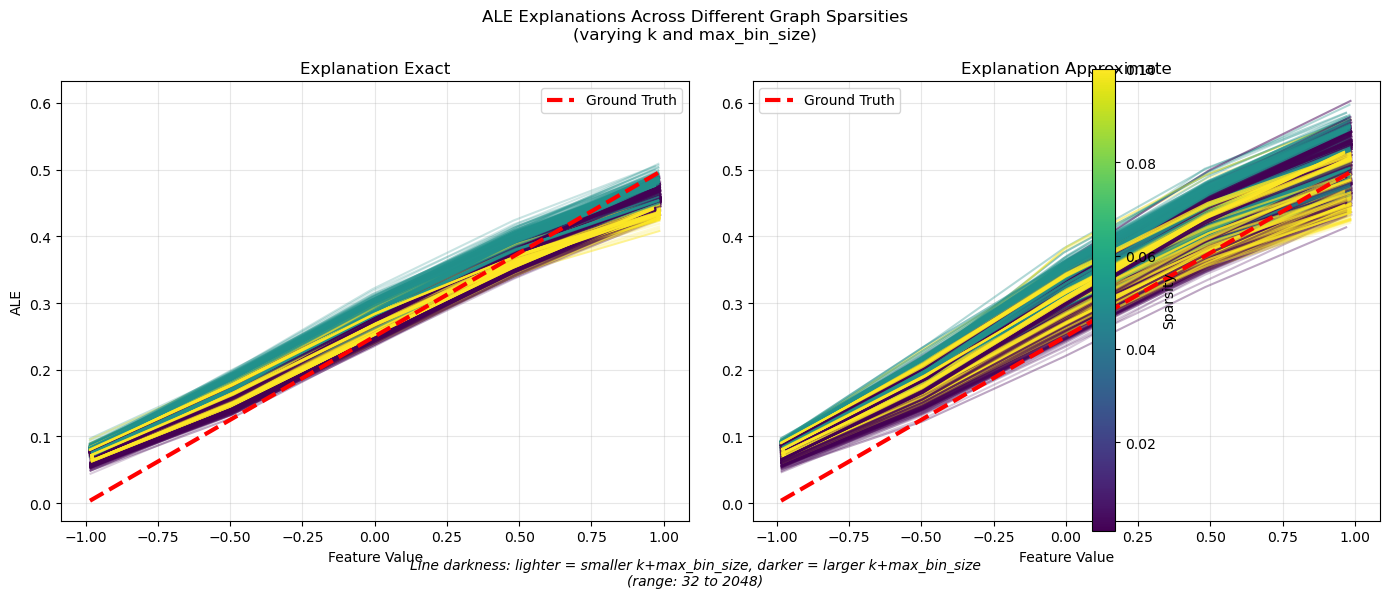

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
import pandas as pd

# First, let's ensure data is sorted by feature value within each group
df_sorted = df.sort_values(['sparsity', 'seed', 'feature'])

# Replot with sorted data
groundtruth_df = df_sorted.groupby(['index']).agg({'feature': 'first', 'groundtruth': 'first'}).reset_index()

# Calculate weighted averages with sorted data (no weighting needed if all have same k and max_bin_size)
gt_exact = df_sorted.groupby(['index'])['explanation_exact'].mean()
gt_approximate = df_sorted.groupby(['index'])['explanation_approximate'].mean()

# Create subplots with sorted data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Get unique sparsity values and create color map
sparsity_values = sorted(df_sorted['sparsity'].unique())

# Calculate k+max_bin_size for color intensity
df_sorted['intensity'] = df_sorted['k'] + df_sorted['max_bin_size']
min_intensity = df_sorted['intensity'].min()
max_intensity = df_sorted['intensity'].max()

# Create colormap for sparsity (hue) and intensity mapping for alpha/darkness
sparsity_colors = plt.cm.viridis(np.linspace(0, 1, len(sparsity_values)))
sparsity_to_color = dict(zip(sparsity_values, sparsity_colors))

for (k, m, sparsity, seed, trial), group in df_sorted.groupby(['k', 'max_bin_size', "sparsity", "seed", 'trial']):
    # Sort by feature value within group
    group = group.sort_values('feature')
    
    # Get base color from sparsity
    base_color = sparsity_to_color[sparsity]
    
    # Calculate intensity (darkness) based on k + max_bin_size
    intensity_value = k + m
    # Normalize to [0, 1] where smaller values are lighter (higher alpha means more transparent)
    # We want: small k+m → light (low opacity), large k+m → dark (high opacity)
    normalized_intensity = (intensity_value - min_intensity) / (max_intensity - min_intensity)
    
    # Use alpha for transparency: smaller k+m → more transparent (lighter)
    alpha = 0.2 + 0.6 * normalized_intensity  # Range from 0.2 to 0.8
    
    ax1.plot(
        group['feature'],
        group['explanation_exact'],
        color=base_color,
        alpha=alpha,
        linewidth=1.5,
    )
    
    ax2.plot(
        group['feature'],
        group['explanation_approximate'],
        color=base_color,
        alpha=alpha,
        linewidth=1.5,
    )

ax2.sharey(ax1)

# Plot ground truth
ax1.plot(groundtruth_df['feature'], groundtruth_df['groundtruth'], 
         color='red', linewidth=3, label='Ground Truth', zorder=10, linestyle='--')
ax2.plot(groundtruth_df['feature'], groundtruth_df['groundtruth'], 
         color='red', linewidth=3, label='Ground Truth', zorder=10, linestyle='--')

# Add colorbar legend for sparsity
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, 
                           norm=plt.Normalize(vmin=min(sparsity_values), 
                                             vmax=max(sparsity_values)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=[ax1, ax2], label='Sparsity', pad=0.02)

ax1.set_title('Explanation Exact')
ax2.set_title('Explanation Approximate')
ax1.set_xlabel('Feature Value')
ax2.set_xlabel('Feature Value')
ax1.set_ylabel('ALE')
ax1.legend()
ax2.legend()
ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)

# Add text annotation about line intensity
fig.text(0.5, 0.02, f'Line darkness: lighter = smaller k+max_bin_size, darker = larger k+max_bin_size\n(range: {min_intensity} to {max_intensity})', 
         ha='center', fontsize=10, style='italic')

plt.suptitle(f'ALE Explanations Across Different Graph Sparsities\n(varying k and max_bin_size)')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

# [Rest of the analysis code remains the same...]

SUMMARY STATISTICS
        k  max_bin_size  sparsity  rmse_exact_mean  rmse_exact_std  \
0      16            16     0.001         0.041974        0.005789   
1      16            16     0.010         0.046627        0.002314   
2      16            16     0.100         0.046145        0.006397   
3      16            32     0.001         0.038707        0.005934   
4      16            32     0.010         0.047954        0.005734   
..    ...           ...       ...              ...             ...   
142  1024           512     0.010         0.046532        0.003695   
143  1024           512     0.100         0.045494        0.005247   
144  1024          1024     0.001         0.039824        0.003597   
145  1024          1024     0.010         0.046385        0.003472   
146  1024          1024     0.100         0.045470        0.005044   

     rmse_exact_min  rmse_exact_max  rmse_approximate_mean  \
0          0.035638        0.051250               0.040683   
1          0.043

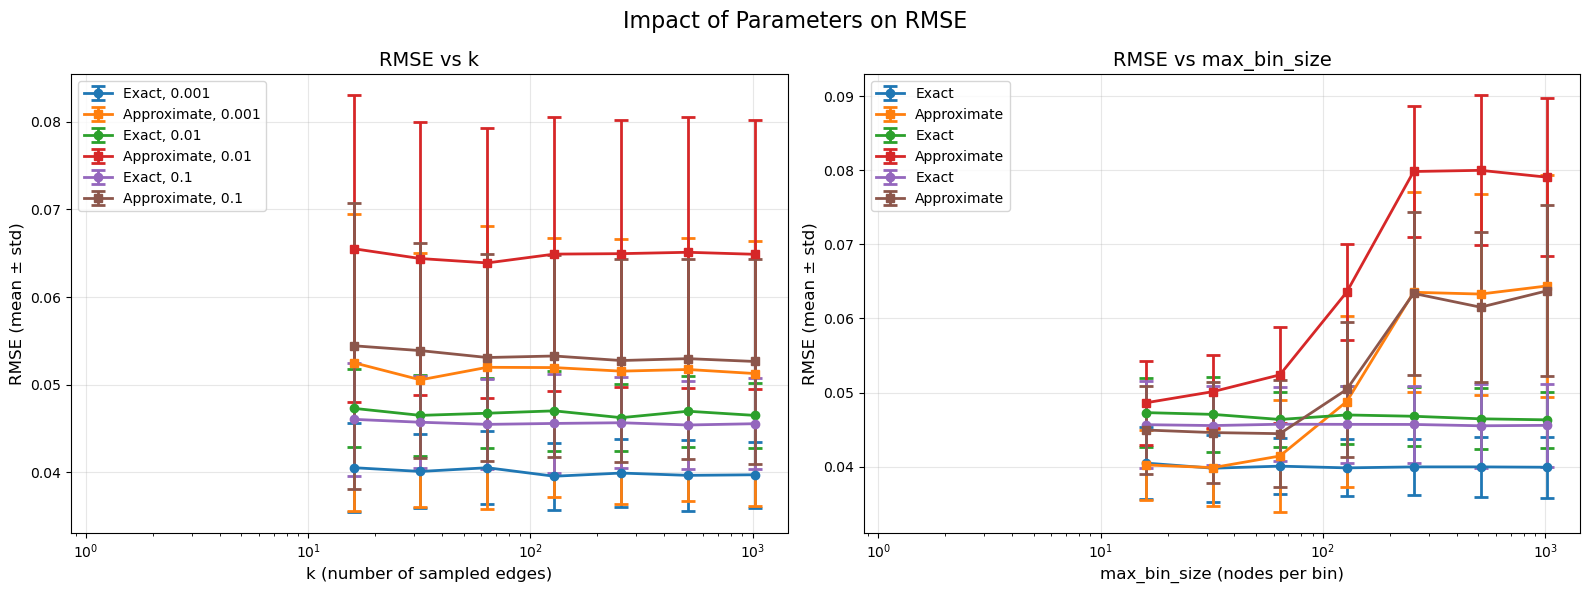

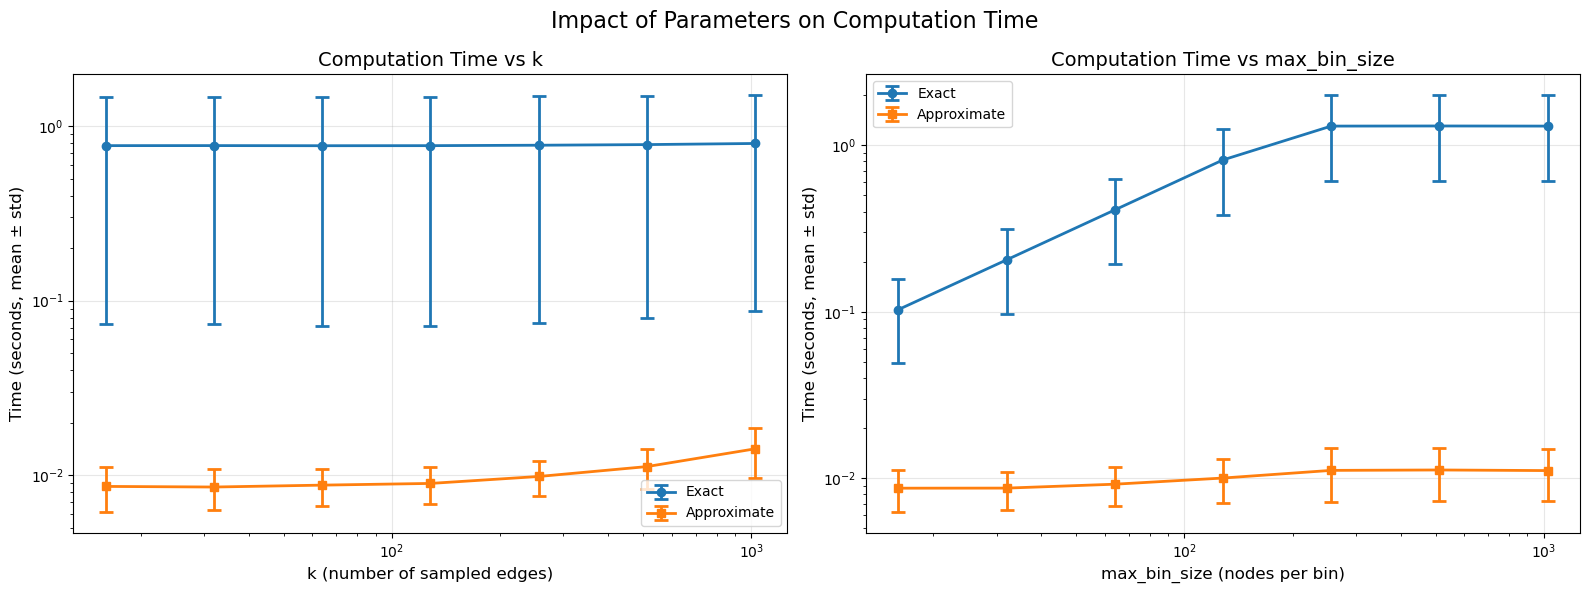

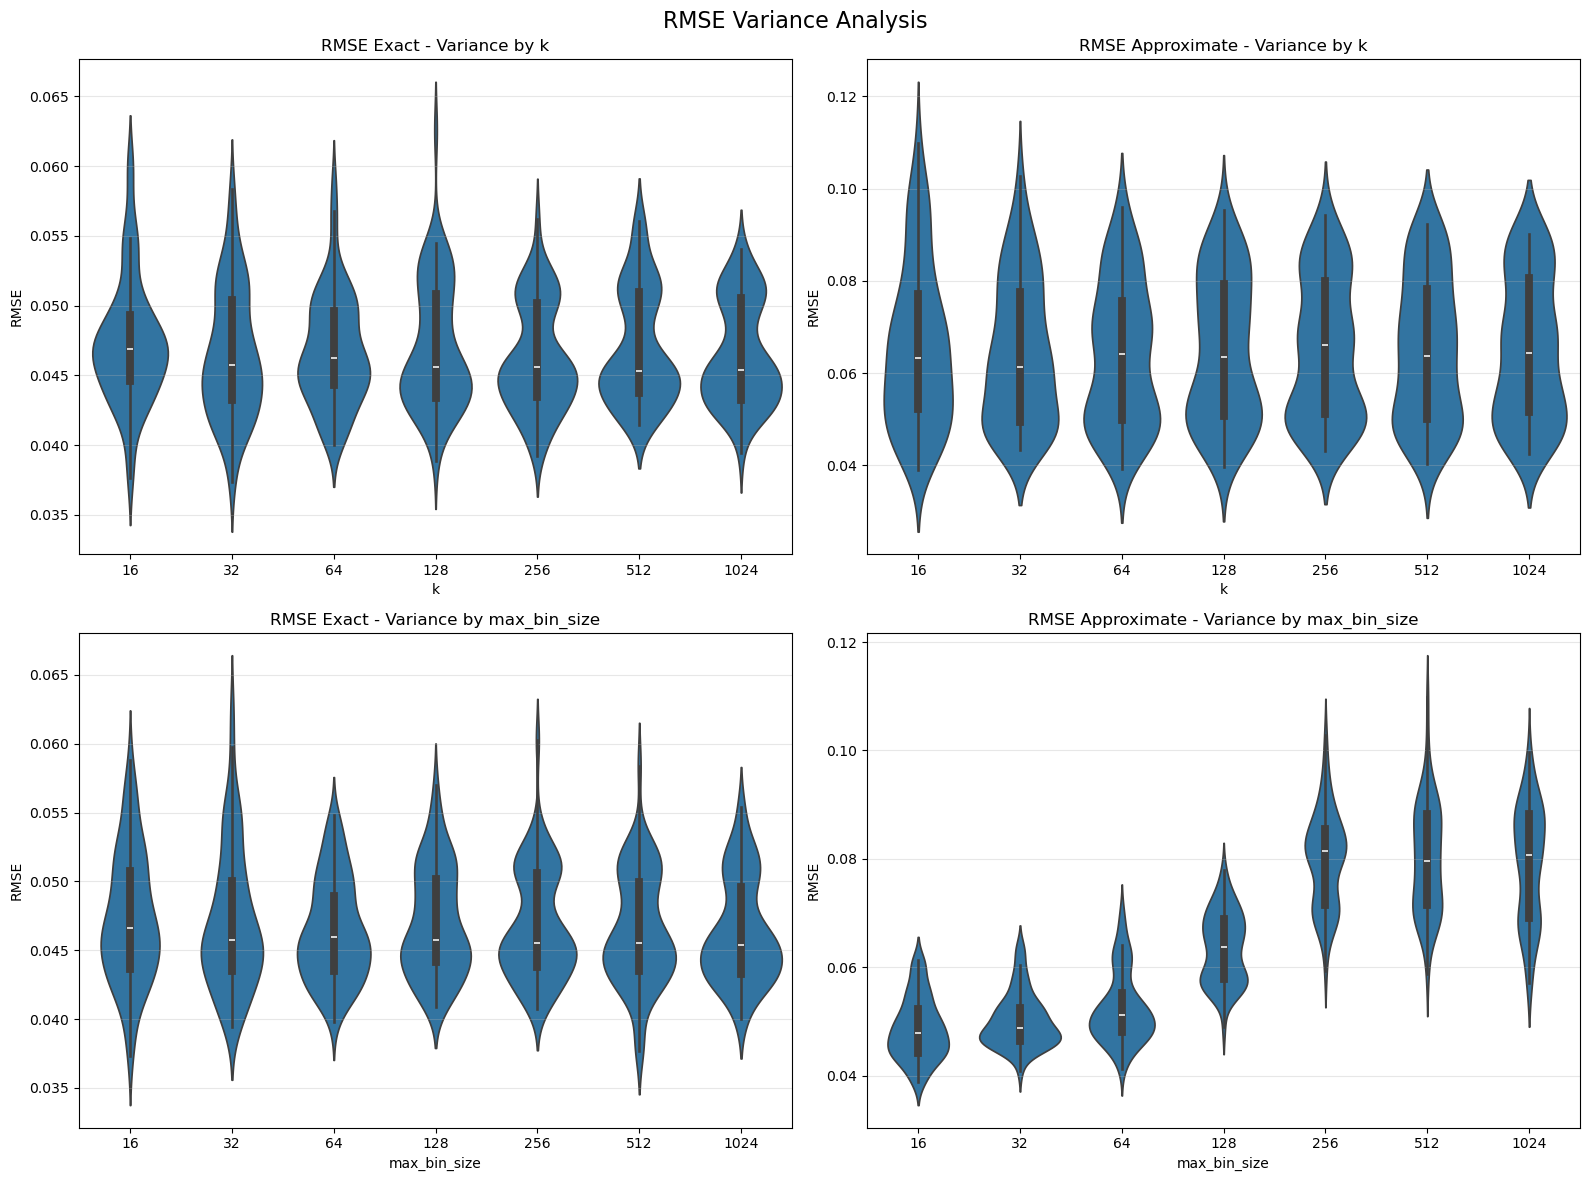

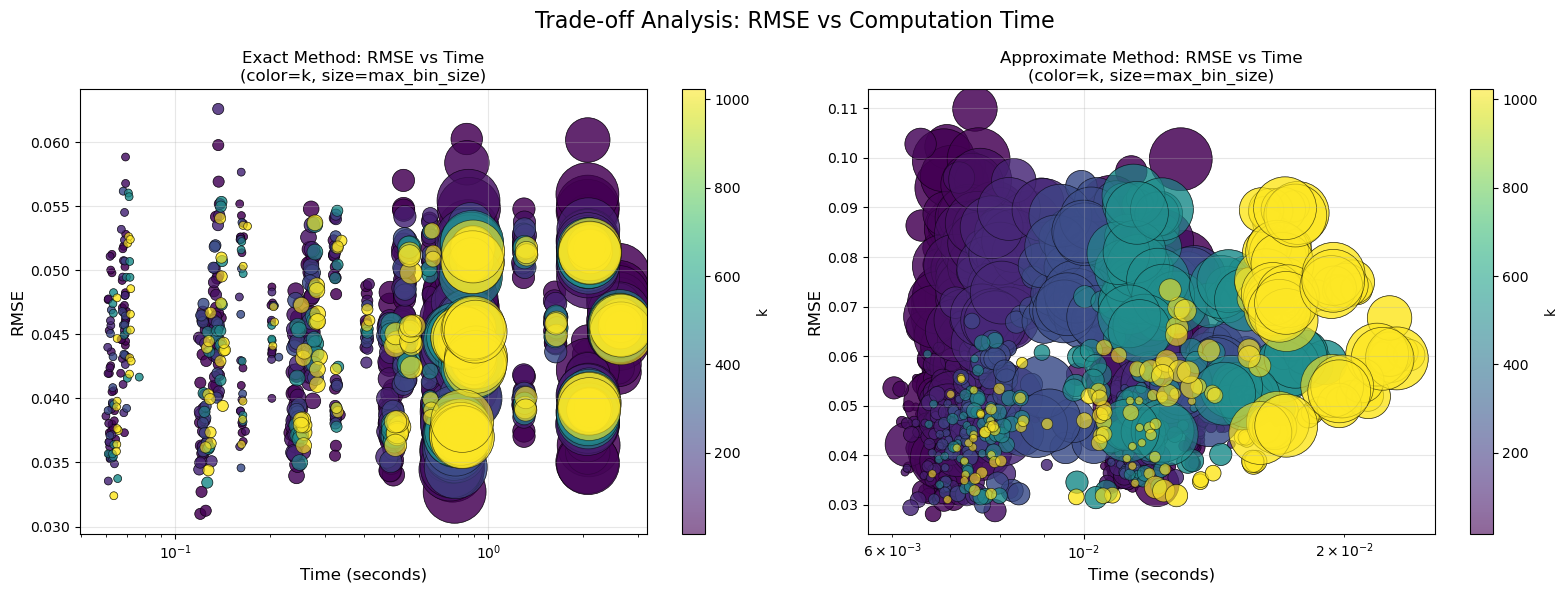

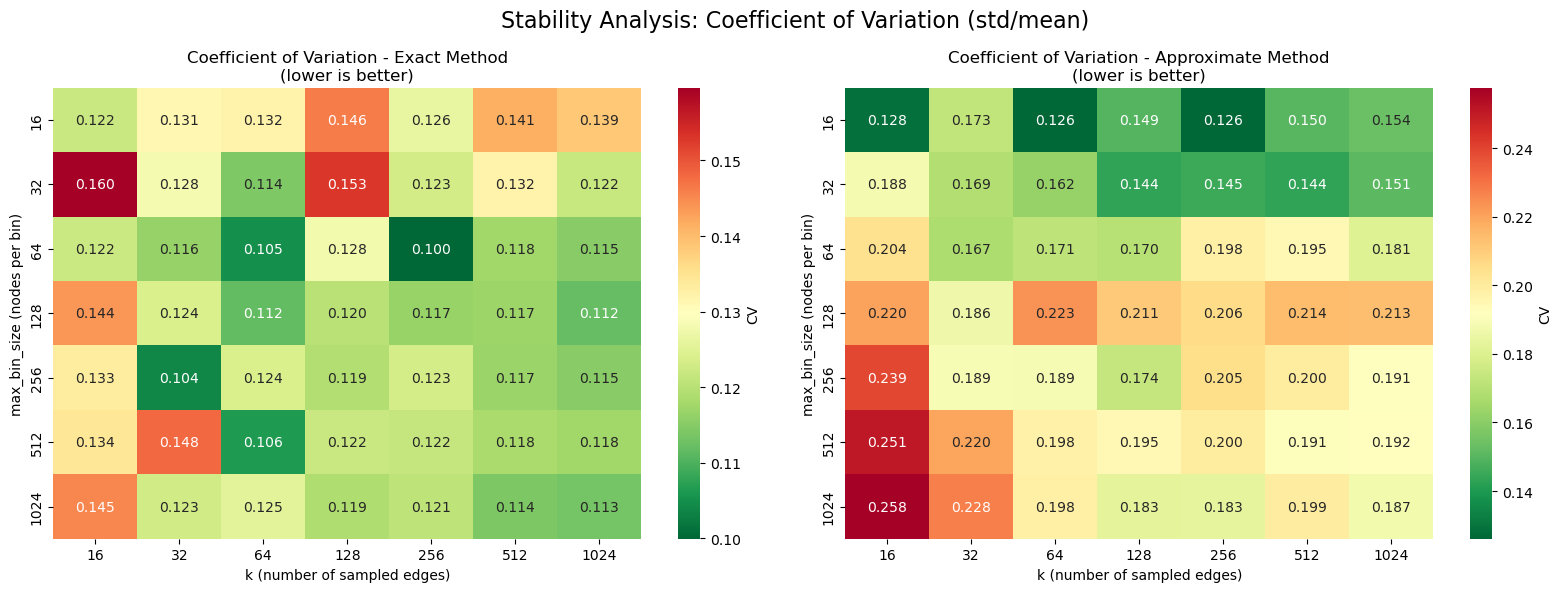


RECOMMENDATIONS

Best parameters for EXACT method (lowest mean RMSE):
  k=32, max_bin_size=128
  Mean RMSE: 0.043528

Best parameters for APPROXIMATE method (lowest mean RMSE):
  k=64, max_bin_size=16
  Mean RMSE: 0.043467

Most stable parameters for EXACT method (lowest CV):
  k=256, max_bin_size=64
  CV: 0.099960

Most stable parameters for APPROXIMATE method (lowest CV):
  k=64, max_bin_size=16
  CV: 0.126102


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Get groundtruth for each index
groundtruth_df = df.groupby(['index']).agg({'feature': 'first', 'groundtruth': 'first'}).reset_index()
groundtruth_values = groundtruth_df['groundtruth'].values

# Calculate metrics for each (k, max_bin_size, seed) combination
metrics_data = []

for (model, k, max_bin_size, seed, sparsity, trial), group in df.groupby(['model', 'k', 'max_bin_size', 'seed', 'sparsity', 'trial']):
    # Sort by index to ensure alignment with groundtruth
    group_sorted = group.sort_values('index')

    # Calculate RMSE
    rmse_exact = np.sqrt(mean_squared_error(groundtruth_values, group_sorted['explanation_exact'].values))
    rmse_approximate = np.sqrt(mean_squared_error(groundtruth_values, group_sorted['explanation_approximate'].values))
    #rmse_exact = mean_absolute_error(groundtruth_values, group_sorted['explanation_exact'].values))
    #rmse_approximate = mean_absolute_error(groundtruth_values, group_sorted['explanation_approximate'].values))
    
    # Get average time
    time_exact = group_sorted['time_exact'].mean()
    time_approximate = group_sorted['time_approximate'].mean()
    
    # Get AUC (should be same for all rows in group)
    auc = group_sorted['AUC'].iloc[0]
    
    metrics_data.append({
        'k': k,
        'trial': trial,
        'max_bin_size': max_bin_size,
        'sparsity': sparsity,
        'seed': seed,
        'rmse_exact': rmse_exact,
        'rmse_approximate': rmse_approximate,
        'time_exact': time_exact,
        'time_approximate': time_approximate,
        'auc': auc})

metrics_df = pd.DataFrame(metrics_data)

# Calculate summary statistics grouped by k and max_bin_size
summary_stats = metrics_df.groupby(['k', 'max_bin_size', 'sparsity']).agg({
    'rmse_exact': ['mean', 'std', 'min', 'max'],
    'rmse_approximate': ['mean', 'std', 'min', 'max'],
    'time_exact': ['mean', 'std'],
    'time_approximate': ['mean', 'std'],
    'auc': 'mean'
}).reset_index()

summary_stats.columns = ['_'.join(col).strip('_') for col in summary_stats.columns.values]

print("="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(summary_stats)

# ============================================================================
# VISUALIZATION 1: RMSE vs Parameters (with variance shown as error bars)
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for sparsity, subdf in metrics_df.groupby('sparsity'):
    # Group by k, calculate mean and std across max_bin_size and seeds
    rmse_by_k = subdf.groupby('k').agg({
        'rmse_exact': ['mean', 'std'],
        'rmse_approximate': ['mean', 'std']
    })

    k_values = rmse_by_k.index.values

    # Plot RMSE vs k
    ax1.errorbar(k_values, rmse_by_k['rmse_exact']['mean'], 
                yerr=rmse_by_k['rmse_exact']['std'], 
                marker='o', capsize=5, capthick=2, label='Exact, '+str(sparsity), linewidth=2)
    ax1.errorbar(k_values, rmse_by_k['rmse_approximate']['mean'], 
                yerr=rmse_by_k['rmse_approximate']['std'], 
                marker='s', capsize=5, capthick=2, label='Approximate, '+str(sparsity), linewidth=2)
    ax1.set_xlabel('k (number of sampled edges)', fontsize=12)
    ax1.set_ylabel('RMSE (mean ± std)', fontsize=12)
    ax1.set_title('RMSE vs k', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xscale('log')

    # Group by max_bin_size
    rmse_by_binsize = subdf.groupby('max_bin_size').agg({
        'rmse_exact': ['mean', 'std'],
        'rmse_approximate': ['mean', 'std']
    })

    binsize_values = rmse_by_binsize.index.values

    # Plot RMSE vs max_bin_size
    ax2.errorbar(binsize_values, rmse_by_binsize['rmse_exact']['mean'], 
                yerr=rmse_by_binsize['rmse_exact']['std'], 
                marker='o', capsize=5, capthick=2, label='Exact', linewidth=2)
    ax2.errorbar(binsize_values, rmse_by_binsize['rmse_approximate']['mean'], 
                yerr=rmse_by_binsize['rmse_approximate']['std'], 
                marker='s', capsize=5, capthick=2, label='Approximate', linewidth=2)
    ax2.set_xlabel('max_bin_size (nodes per bin)', fontsize=12)
    ax2.set_ylabel('RMSE (mean ± std)', fontsize=12)
    ax2.set_title('RMSE vs max_bin_size', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xscale('log')

plt.suptitle('Impact of Parameters on RMSE', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 2: Computation Time vs Parameters
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Group by k
time_by_k = metrics_df.groupby('k').agg({
    'time_exact': ['mean', 'std'],
    'time_approximate': ['mean', 'std']
})

# Plot time vs k
ax1.errorbar(k_values, time_by_k['time_exact']['mean'], 
             yerr=time_by_k['time_exact']['std'], 
             marker='o', capsize=5, capthick=2, label='Exact', linewidth=2)
ax1.errorbar(k_values, time_by_k['time_approximate']['mean'], 
             yerr=time_by_k['time_approximate']['std'], 
             marker='s', capsize=5, capthick=2, label='Approximate', linewidth=2)
ax1.set_xlabel('k (number of sampled edges)', fontsize=12)
ax1.set_ylabel('Time (seconds, mean ± std)', fontsize=12)
ax1.set_title('Computation Time vs k', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')

# Group by max_bin_size
time_by_binsize = metrics_df.groupby('max_bin_size').agg({
    'time_exact': ['mean', 'std'],
    'time_approximate': ['mean', 'std']
})

# Plot time vs max_bin_size
ax2.errorbar(binsize_values, time_by_binsize['time_exact']['mean'], 
             yerr=time_by_binsize['time_exact']['std'], 
             marker='o', capsize=5, capthick=2, label='Exact', linewidth=2)
ax2.errorbar(binsize_values, time_by_binsize['time_approximate']['mean'], 
             yerr=time_by_binsize['time_approximate']['std'], 
             marker='s', capsize=5, capthick=2, label='Approximate', linewidth=2)
ax2.set_xlabel('max_bin_size (nodes per bin)', fontsize=12)
ax2.set_ylabel('Time (seconds, mean ± std)', fontsize=12)
ax2.set_title('Computation Time vs max_bin_size', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')
ax2.set_yscale('log')

plt.suptitle('Impact of Parameters on Computation Time', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 3: Variance Analysis (Box plots)
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# RMSE variance by k
sns.violinplot(data=metrics_df[metrics_df['sparsity']==0.01], x='k', y='rmse_exact', ax=axes[0, 0])
axes[0, 0].set_title('RMSE Exact - Variance by k', fontsize=12)
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].grid(True, alpha=0.3, axis='y')

sns.violinplot(data=metrics_df[metrics_df['sparsity']==0.01], x='k', y='rmse_approximate', ax=axes[0, 1])
axes[0, 1].set_title('RMSE Approximate - Variance by k', fontsize=12)
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# RMSE variance by max_bin_size
sns.violinplot(data=metrics_df[metrics_df['sparsity']==0.01], x='max_bin_size', y='rmse_exact', ax=axes[1, 0])
axes[1, 0].set_title('RMSE Exact - Variance by max_bin_size', fontsize=12)
axes[1, 0].set_xlabel('max_bin_size')
axes[1, 0].set_ylabel('RMSE')
axes[1, 0].grid(True, alpha=0.3, axis='y')

sns.violinplot(data=metrics_df[metrics_df['sparsity']==0.01], x='max_bin_size', y='rmse_approximate', ax=axes[1, 1])
axes[1, 1].set_title('RMSE Approximate - Variance by max_bin_size', fontsize=12)
axes[1, 1].set_xlabel('max_bin_size')
axes[1, 1].set_ylabel('RMSE')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('RMSE Variance Analysis', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 4: Scatter plots - RMSE vs Time (trade-off analysis)
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Exact method
scatter1 = ax1.scatter(metrics_df['time_exact'], metrics_df['rmse_exact'], 
                       c=metrics_df['k'], s=metrics_df['max_bin_size']*2, 
                       alpha=0.6, cmap='viridis', edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Time (seconds)', fontsize=12)
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_title('Exact Method: RMSE vs Time\n(color=k, size=max_bin_size)', fontsize=12)
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('k', fontsize=10)

# Approximate method
scatter2 = ax2.scatter(metrics_df['time_approximate'], metrics_df['rmse_approximate'], 
                       c=metrics_df['k'], s=metrics_df['max_bin_size']*2, 
                       alpha=0.6, cmap='viridis', edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('RMSE', fontsize=12)
ax2.set_title('Approximate Method: RMSE vs Time\n(color=k, size=max_bin_size)', fontsize=12)
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('k', fontsize=10)

plt.suptitle('Trade-off Analysis: RMSE vs Computation Time', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 5: Heatmap of coefficient of variation (CV = std/mean)
# ============================================================================
cv_exact = metrics_df.groupby(['k', 'max_bin_size'])['rmse_exact'].agg(['mean', 'std'])
cv_exact['cv'] = cv_exact['std'] / cv_exact['mean']
cv_approx = metrics_df.groupby(['k', 'max_bin_size'])['rmse_approximate'].agg(['mean', 'std'])
cv_approx['cv'] = cv_approx['std'] / cv_approx['mean']

pivot_cv_exact = cv_exact['cv'].reset_index().pivot(index='max_bin_size', columns='k', values='cv')
pivot_cv_approx = cv_approx['cv'].reset_index().pivot(index='max_bin_size', columns='k', values='cv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pivot_cv_exact, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax1, cbar_kws={'label': 'CV'})
ax1.set_xlabel('k (number of sampled edges)')
ax1.set_ylabel('max_bin_size (nodes per bin)')
ax1.set_title('Coefficient of Variation - Exact Method\n(lower is better)')

sns.heatmap(pivot_cv_approx, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax2, cbar_kws={'label': 'CV'})
ax2.set_xlabel('k (number of sampled edges)')
ax2.set_ylabel('max_bin_size (nodes per bin)')
ax2.set_title('Coefficient of Variation - Approximate Method\n(lower is better)')

plt.suptitle('Stability Analysis: Coefficient of Variation (std/mean)', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================================================
# Print recommendations
# ============================================================================
print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)

# Find best parameters for exact method
best_exact = metrics_df.groupby(['k', 'max_bin_size'])['rmse_exact'].mean().idxmin()
print(f"\nBest parameters for EXACT method (lowest mean RMSE):")
print(f"  k={best_exact[0]}, max_bin_size={best_exact[1]}")
print(f"  Mean RMSE: {metrics_df.groupby(['k', 'max_bin_size'])['rmse_exact'].mean().min():.6f}")

# Find best parameters for approximate method
best_approx = metrics_df.groupby(['k', 'max_bin_size'])['rmse_approximate'].mean().idxmin()
print(f"\nBest parameters for APPROXIMATE method (lowest mean RMSE):")
print(f"  k={best_approx[0]}, max_bin_size={best_approx[1]}")
print(f"  Mean RMSE: {metrics_df.groupby(['k', 'max_bin_size'])['rmse_approximate'].mean().min():.6f}")

# Find most stable parameters (lowest CV)
best_stable_exact = cv_exact['cv'].idxmin()
print(f"\nMost stable parameters for EXACT method (lowest CV):")
print(f"  k={best_stable_exact[0]}, max_bin_size={best_stable_exact[1]}")
print(f"  CV: {cv_exact.loc[best_stable_exact, 'cv']:.6f}")

best_stable_approx = cv_approx['cv'].idxmin()
print(f"\nMost stable parameters for APPROXIMATE method (lowest CV):")
print(f"  k={best_stable_approx[0]}, max_bin_size={best_stable_approx[1]}")
print(f"  CV: {cv_approx.loc[best_stable_approx, 'cv']:.6f}")


RMSE DIFFERENCE SUMMARY
Mean difference: 0.012443
Max difference (worst degradation): 0.029049
Min difference (best case): -0.001713

Worst configuration (highest positive difference):
  m=1024, k=16, difference=0.029049

Best configuration (lowest difference):
  m=16, k=64, difference=-0.001713


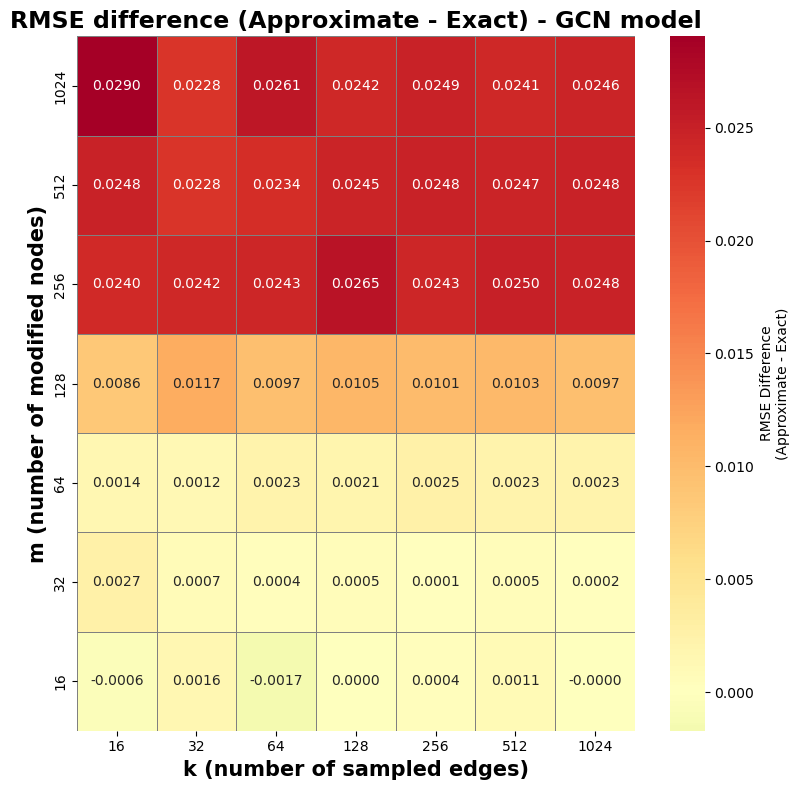

In [53]:
model = 'GCN'

# Calculate mean RMSE for each configuration
rmse_stats = metrics_df.groupby(['k', 'max_bin_size']).agg({
    'rmse_exact': 'mean',
    'rmse_approximate': 'mean'
}).reset_index()

# Calculate difference (Approximate - Exact)
rmse_stats['rmse_difference'] = rmse_stats['rmse_approximate'] - rmse_stats['rmse_exact']

# Create pivot table for difference
pivot_diff = rmse_stats.pivot(index='max_bin_size', columns='k', values='rmse_difference')

# Sort index in descending order (largest m at top, smallest at bottom)
pivot_diff = pivot_diff.sort_index(ascending=False)

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Create difference heatmap with diverging colormap
# Center colormap at 0, use RdYlGn_r so red=worse (positive), green=better (negative)
sns.heatmap(pivot_diff, 
            annot=True, 
            fmt='.4f', 
            cmap='RdYlGn_r',
            center=0,
            ax=ax, 
            cbar_kws={'label': 'RMSE Difference\n(Approximate - Exact)'},
            linewidths=0.5,
            linecolor='gray')

ax.set_xlabel('k (number of sampled edges)', fontsize=15, fontweight='bold')
ax.set_ylabel('m (number of modified nodes)', fontsize=15, fontweight='bold')
ax.set_title(f"RMSE difference (Approximate - Exact) - {model} model", 
             fontsize=17, fontweight='bold')

# Add text annotation explaining the color scheme
#textstr = 'Positive values (red): Approximate has higher error\nNegative values (green): Approximate has lower error'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
#ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
#        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig(f"heatmap_{model}.eps", format='eps')

# Print summary statistics
print("\n" + "="*60)
print("RMSE DIFFERENCE SUMMARY")
print("="*60)
print(f"Mean difference: {pivot_diff.values.mean():.6f}")
print(f"Max difference (worst degradation): {pivot_diff.values.max():.6f}")
print(f"Min difference (best case): {pivot_diff.values.min():.6f}")
print(f"\nWorst configuration (highest positive difference):")
worst_idx = np.unravel_index(pivot_diff.values.argmax(), pivot_diff.shape)
worst_m = pivot_diff.index[worst_idx[0]]
worst_k = pivot_diff.columns[worst_idx[1]]
print(f"  m={worst_m}, k={worst_k}, difference={pivot_diff.iloc[worst_idx]:.6f}")
print(f"\nBest configuration (lowest difference):")
best_idx = np.unravel_index(pivot_diff.values.argmin(), pivot_diff.shape)
best_m = pivot_diff.index[best_idx[0]]
best_k = pivot_diff.columns[best_idx[1]]
print(f"  m={best_m}, k={best_k}, difference={pivot_diff.iloc[best_idx]:.6f}")

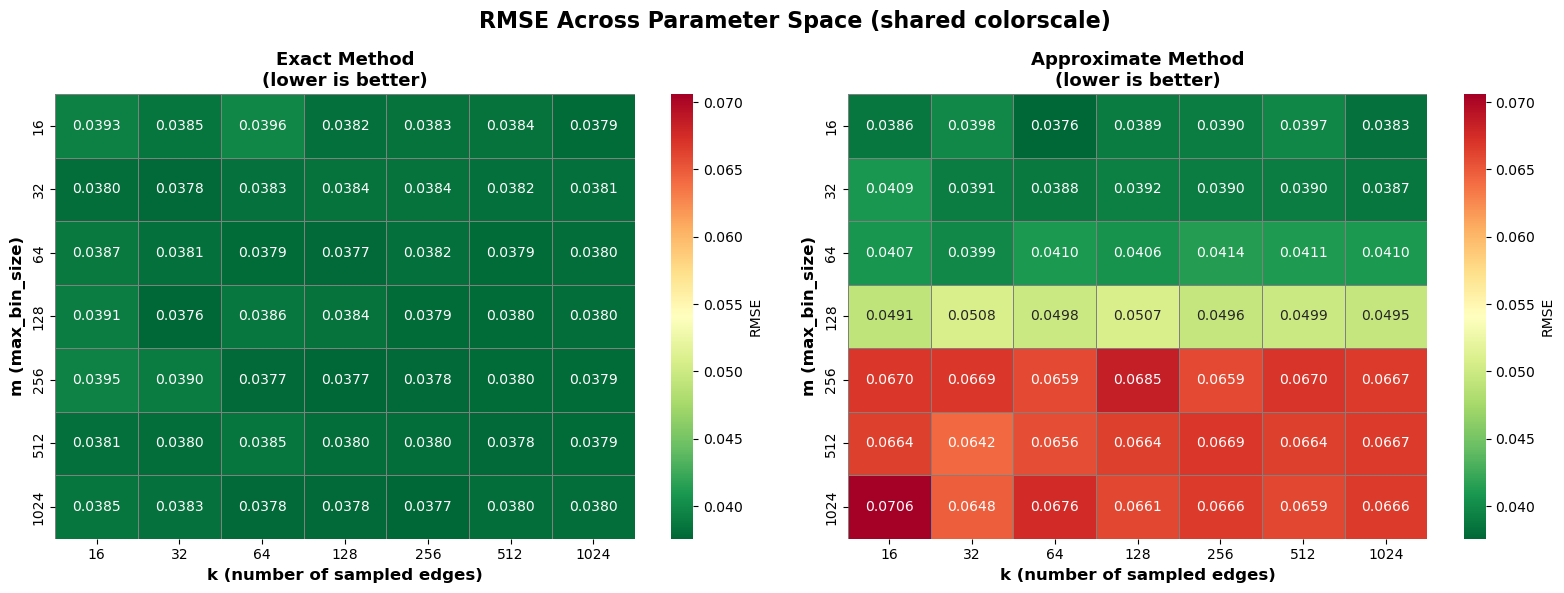


Colorscale range: [0.0376, 0.0706]
Exact RMSE range: [0.0376, 0.0396]
Approximate RMSE range: [0.0376, 0.0706]


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean and std RMSE for each configuration
rmse_exact = metrics_df.groupby(['k', 'max_bin_size'])['rmse_exact'].agg(['mean', 'std'])
rmse_approx = metrics_df.groupby(['k', 'max_bin_size'])['rmse_approximate'].agg(['mean', 'std'])

# Create pivot tables for mean RMSE
pivot_rmse_exact = rmse_exact['mean'].reset_index().pivot(index='max_bin_size', columns='k', values='mean')
pivot_rmse_approx = rmse_approx['mean'].reset_index().pivot(index='max_bin_size', columns='k', values='mean')

# Find global min and max for shared colorscale
vmin = min(pivot_rmse_exact.min().min(), pivot_rmse_approx.min().min())
vmax = max(pivot_rmse_exact.max().max(), pivot_rmse_approx.max().max())

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Exact method heatmap
sns.heatmap(pivot_rmse_exact, 
            annot=True, 
            fmt='.4f', 
            cmap='RdYlGn_r', 
            vmin=vmin, 
            vmax=vmax,
            ax=ax1, 
            cbar_kws={'label': 'RMSE'},
            linewidths=0.5,
            linecolor='gray')
ax1.set_xlabel('k (number of sampled edges)', fontsize=12, fontweight='bold')
ax1.set_ylabel('m (max_bin_size)', fontsize=12, fontweight='bold')
ax1.set_title('Exact Method\n(lower is better)', fontsize=13, fontweight='bold')

# Approximate method heatmap
sns.heatmap(pivot_rmse_approx, 
            annot=True, 
            fmt='.4f', 
            cmap='RdYlGn_r', 
            vmin=vmin, 
            vmax=vmax,
            ax=ax2, 
            cbar_kws={'label': 'RMSE'},
            linewidths=0.5,
            linecolor='gray')
ax2.set_xlabel('k (number of sampled edges)', fontsize=12, fontweight='bold')
ax2.set_ylabel('m (max_bin_size)', fontsize=12, fontweight='bold')
ax2.set_title('Approximate Method\n(lower is better)', fontsize=13, fontweight='bold')

plt.suptitle('RMSE Across Parameter Space (shared colorscale)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nColorscale range: [{vmin:.4f}, {vmax:.4f}]")
print(f"Exact RMSE range: [{pivot_rmse_exact.min().min():.4f}, {pivot_rmse_exact.max().max():.4f}]")
print(f"Approximate RMSE range: [{pivot_rmse_approx.min().min():.4f}, {pivot_rmse_approx.max().max():.4f}]")

In [71]:
df.groupby('model')['AUC'].agg(['mean', 'std'])

,mean,std
model,,
GAT,0.730476,0.007686
GCN,0.729678,0.007732


In [26]:
metrics_df['model'] = 'GAT'

Step 1: Calculating RMSE from feature-level data...


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Calculated RMSE for 2646 configurations
Models: ['GAT', 'GCN']
Sparsities: [0.001, 0.01, 0.1]
k values: [16, 32, 64, 128, 256, 512, 1024]
max_bin_size values: [16, 32, 64, 128, 256, 512, 1024]
Seeds: [0, 1, 2]

Step 2: Generating Figure 1 plots...

Generating plot for sparsity=0.001...
Saved: figure1_sparsity_0_001.eps


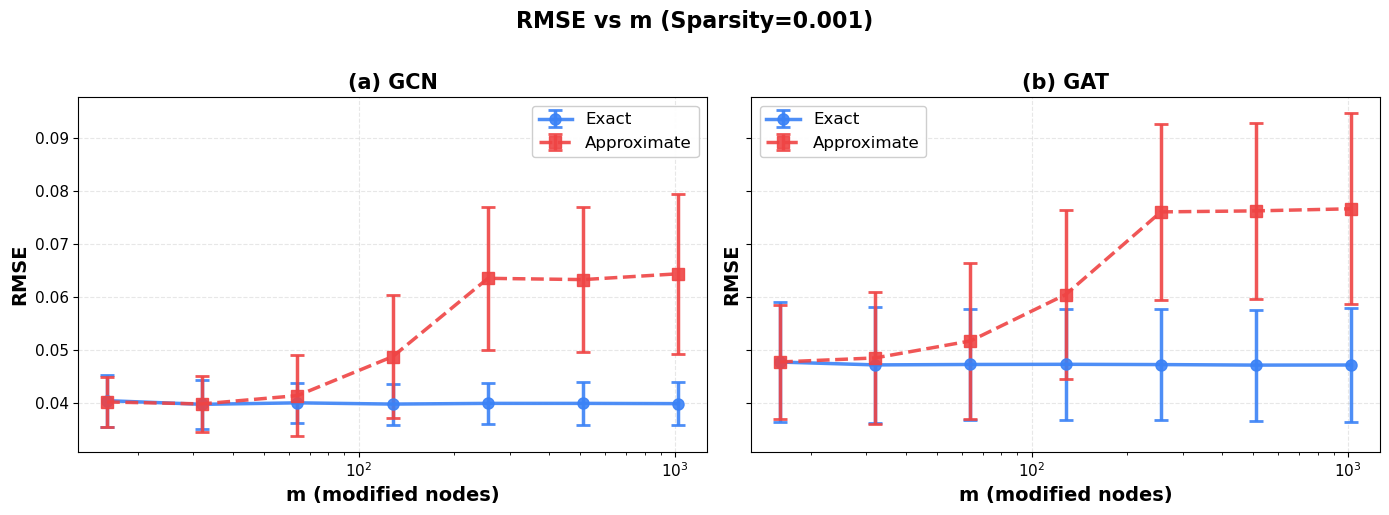


Generating plot for sparsity=0.01...


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figure1_sparsity_0_01.eps


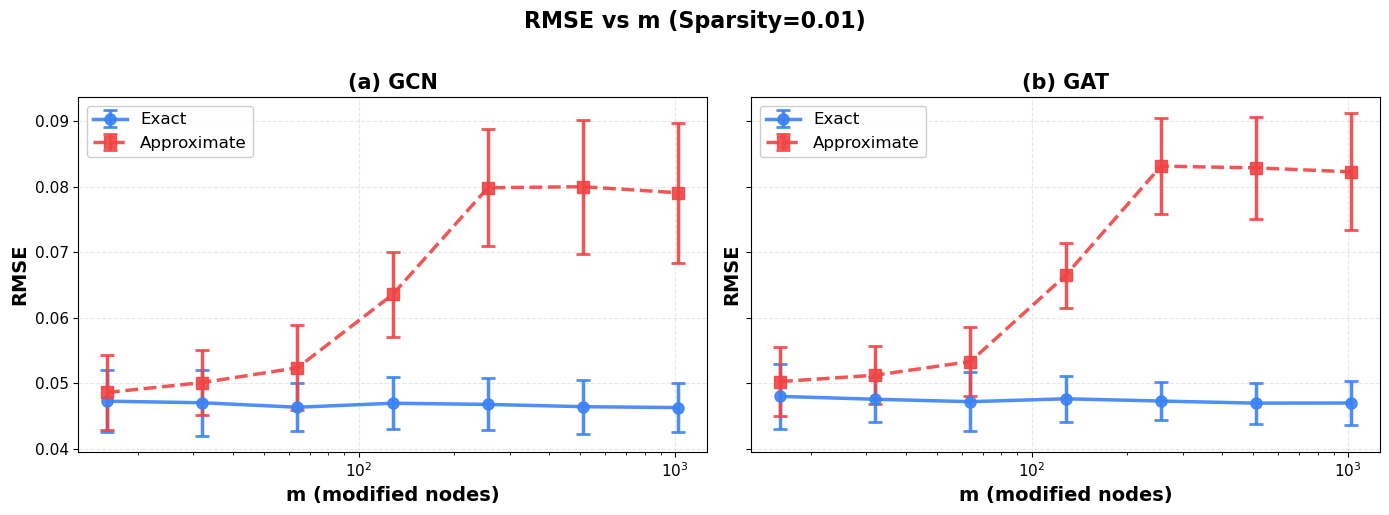


Generating plot for sparsity=0.1...


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figure1_sparsity_0_1.eps


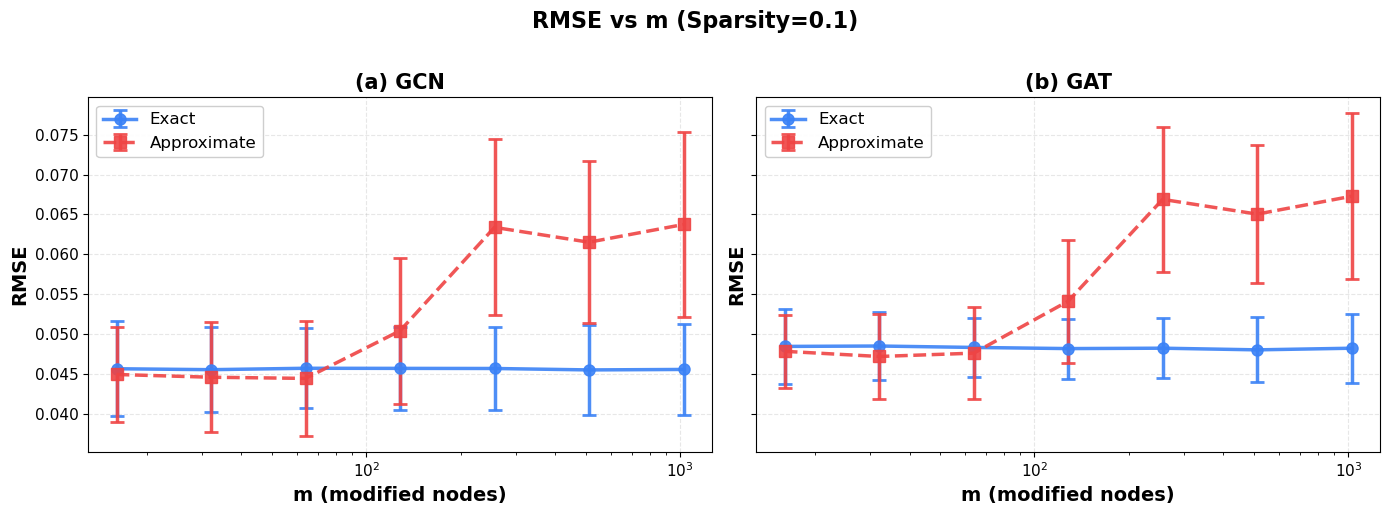


All Figure 1 plots generated successfully!


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

def calculate_rmse_from_feature_df(df):
    """
    Calculate RMSE from feature-level dataframe
    
    Parameters:
    -----------
    df : DataFrame with columns: index, trial, feature, k, max_bin_size, 
         explanation_approximate, explanation_exact, groundtruth, 
         AUC, sparsity, seed, model
    
    Returns:
    --------
    metrics_df : DataFrame with RMSE per (k, max_bin_size, seed, trial, sparsity, model)
    """
    # Get groundtruth for each index
    groundtruth_df = df.groupby(['index']).agg({'feature': 'first', 'groundtruth': 'first'}).reset_index()
    groundtruth_values = groundtruth_df['groundtruth'].values
    
    metrics_data = []
    
    # Group by all relevant variables
    for (k, max_bin_size, seed, sparsity, trial, model), group in df.groupby(['k', 'max_bin_size', 'seed', 'sparsity', 'trial', 'model']):
        # Sort by index to ensure alignment with groundtruth
        group_sorted = group.sort_values('index')
        
        # Calculate RMSE
        rmse_exact = np.sqrt(mean_squared_error(groundtruth_values, group_sorted['explanation_exact'].values))
        rmse_approximate = np.sqrt(mean_squared_error(groundtruth_values, group_sorted['explanation_approximate'].values))
        
        # Get average time
        time_exact = group_sorted['time_exact'].mean()
        time_approximate = group_sorted['time_approximate'].mean()
        
        # Get AUC (should be same for all rows in group)
        auc = group_sorted['AUC'].iloc[0]
        
        metrics_data.append({
            'k': k,
            'trial': trial,
            'max_bin_size': max_bin_size,
            'sparsity': sparsity,
            'seed': seed,
            'model': model,
            'rmse_exact': rmse_exact,
            'rmse_approximate': rmse_approximate,
            'time_exact': time_exact,
            'time_approximate': time_approximate,
            'auc': auc
        })
    
    return pd.DataFrame(metrics_data)

def plot_figure1_gcn_gat_side_by_side(metrics_df, sparsity_val, save_path=None):
    """
    Create Figure 1 for a specific sparsity value
    Left: GCN, Right: GAT
    Solid line = Exact, Dashed line = Approximate
    Error bars = std across seeds (between-model variance)
    
    Parameters:
    -----------
    metrics_df : DataFrame with RMSE metrics
    sparsity_val : float, the sparsity to plot
    save_path : str, path to save (should end with .eps)
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    
    # Define colors
    color_exact = '#3b82f6'  # Blue
    color_approx = '#ef4444'  # Red
    
    models = ['GCN', 'GAT']
    
    for idx, model in enumerate(models):
        ax = axes[idx]
        
        # Filter data for this model and sparsity
        plot_data = metrics_df[(metrics_df['model'] == model) & 
                               (metrics_df['sparsity'] == sparsity_val)]
        
        if len(plot_data) == 0:
            print(f"Warning: No data for model={model}, sparsity={sparsity_val}")
            continue
        
        # Calculate mean and std across seeds for each max_bin_size
        rmse_stats = plot_data.groupby('max_bin_size').agg({
            'rmse_exact': ['mean', 'std'],
            'rmse_approximate': ['mean', 'std']
        })
        
        max_bin_sizes = rmse_stats.index.values
        
        # Plot Exact (solid line)
        ax.errorbar(max_bin_sizes, 
                   rmse_stats['rmse_exact']['mean'],
                   yerr=rmse_stats['rmse_exact']['std'],
                   color=color_exact,
                   linestyle='-',
                   marker='o',
                   markersize=8,
                   capsize=5,
                   capthick=2,
                   linewidth=2.5,
                   label='Exact',
                   alpha=0.9)
        
        # Plot Approximate (dashed line)
        ax.errorbar(max_bin_sizes,
                   rmse_stats['rmse_approximate']['mean'],
                   yerr=rmse_stats['rmse_approximate']['std'],
                   color=color_approx,
                   linestyle='--',
                   marker='s',
                   markersize=8,
                   capsize=5,
                   capthick=2,
                   linewidth=2.5,
                   label='Approximate',
                   alpha=0.9)
        
        ax.set_xlabel('m (modified nodes)', fontsize=14, fontweight='bold')
        ax.set_ylabel('RMSE', fontsize=14, fontweight='bold')#(mean ± std across different models)
        ax.set_title(f'({chr(97+idx)}) {model}', fontsize=15, fontweight='bold')
        ax.legend(fontsize=12, framealpha=0.95, loc='best')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xscale('log')
        ax.tick_params(labelsize=11)
    
    plt.suptitle(f'RMSE vs m (Sparsity={sparsity_val})',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='eps', dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    return fig

def generate_all_figure1_plots(df, sparsities=[0.001, 0.01, 0.1]):
    """
    Complete pipeline: Calculate RMSE from feature-level df and generate all Figure 1 plots
    
    Parameters:
    -----------
    df : DataFrame with feature-level explanation data
    sparsities : list of float, sparsity values to generate plots for
    """
    print("Step 1: Calculating RMSE from feature-level data...")
    metrics_df = calculate_rmse_from_feature_df(df)
    
    print(f"\nCalculated RMSE for {len(metrics_df)} configurations")
    print(f"Models: {sorted(metrics_df['model'].unique())}")
    print(f"Sparsities: {sorted(metrics_df['sparsity'].unique())}")
    print(f"k values: {sorted(metrics_df['k'].unique())}")
    print(f"max_bin_size values: {sorted(metrics_df['max_bin_size'].unique())}")
    print(f"Seeds: {sorted(metrics_df['seed'].unique())}")
    
    print("\n" + "="*60)
    print("Step 2: Generating Figure 1 plots...")
    print("="*60)
    
    for sparsity in sparsities:
        # Check if this sparsity exists in data
        if sparsity not in metrics_df['sparsity'].values:
            print(f"Warning: Sparsity {sparsity} not found in data, skipping...")
            continue
        
        # Format sparsity for filename (replace . with _)
        sparsity_str = str(sparsity).replace('.', '_')
        save_path = f'figure1_sparsity_{sparsity_str}.eps'
        
        print(f"\nGenerating plot for sparsity={sparsity}...")
        plot_figure1_gcn_gat_side_by_side(metrics_df, 
                                         sparsity_val=sparsity,
                                         save_path=save_path)
    
    print("\n" + "="*60)
    print("All Figure 1 plots generated successfully!")
    print("="*60)
    
    return metrics_df


metrics_df = generate_all_figure1_plots(df, sparsities=[0.001, 0.01, 0.1])
    
    # The metrics_df is returned if you want to use it for other analyses
    # You can now use it for the difference heatmap or other plots

# Alternative usage - generate single plot:
# metrics_df = calculate_rmse_from_feature_df(df)
# plot_figure1_gcn_gat_side_by_side(metrics_df, 
#                                   sparsity_val=0.01,
#                                   save_path='figure1_sparsity_0_01.eps')

In [58]:
df

,index,trial,feature,k,max_bin_size,explanation_approximate,time_approximate,explanation_exact,time_exact,groundtruth,AUC,sparsity,seed,model
0,0,0,-0.985113,16,16,0.079099,0.007311,0.083794,0.060978,0.003722,0.727855,0.001,0,GCN
1,1,0,-0.491699,16,16,0.171781,0.007311,0.181453,0.060978,0.127075,0.727855,0.001,0,GCN
2,2,0,0.001714,16,16,0.270883,0.007311,0.282987,0.060978,0.250428,0.727855,0.001,0,GCN
3,3,0,0.495127,16,16,0.376733,0.007311,0.385819,0.060978,0.373782,0.727855,0.001,0,GCN
4,4,0,0.988541,16,16,0.456058,0.007311,0.468725,0.060978,0.497135,0.727855,0.001,0,GCN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6610,0,2,-0.984434,1024,1024,0.090116,0.019422,0.079830,2.106718,0.003891,0.722446,0.100,2,GAT
6611,1,2,-0.492335,1024,1024,0.208180,0.019422,0.176384,2.106718,0.126916,0.722446,0.100,2,GAT
6612,2,2,-0.000235,1024,1024,0.340613,0.019422,0.283310,2.106718,0.249941,0.722446,0.100,2,GAT
6613,3,2,0.491864,1024,1024,0.447717,0.019422,0.370470,2.106718,0.372966,0.722446,0.100,2,GAT


Calculating metrics...
Calculating variance components...

Generating Figure 1...


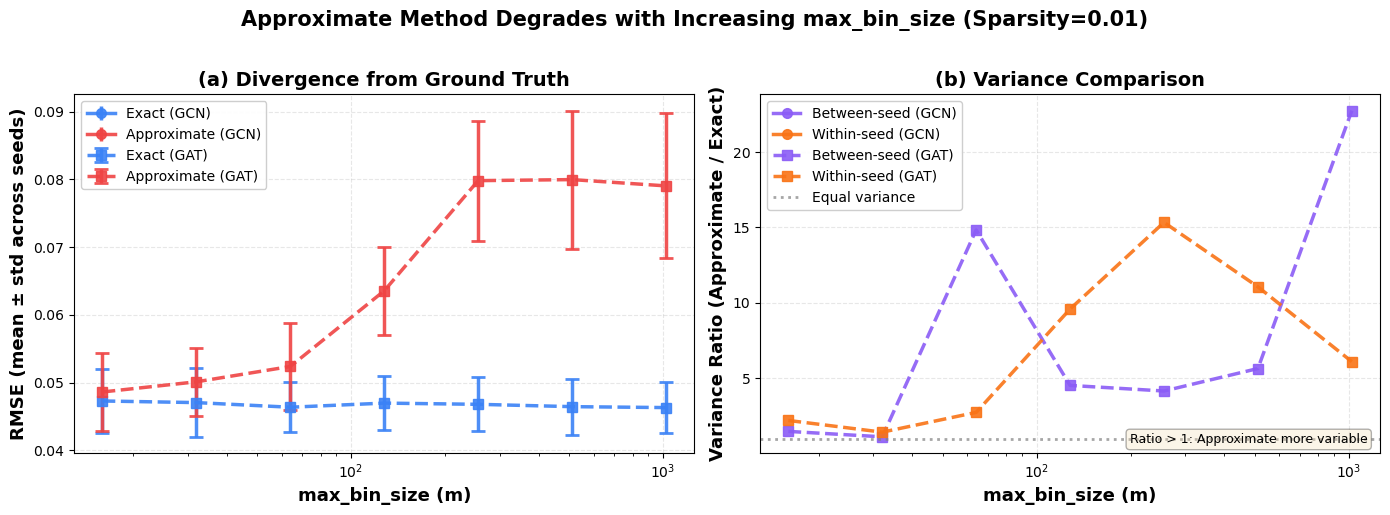


Generating Figure 2 (GCN)...


/home/pkaczyns/miniconda3/envs/ale_conda/lib/python3.10/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/home/pkaczyns/miniconda3/envs/ale_conda/lib/python3.10/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/home/pkaczyns/miniconda3/envs/ale_conda/lib/python3.10/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/home/pkaczyns/miniconda3/envs/ale_conda/lib/python3.10/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transfo

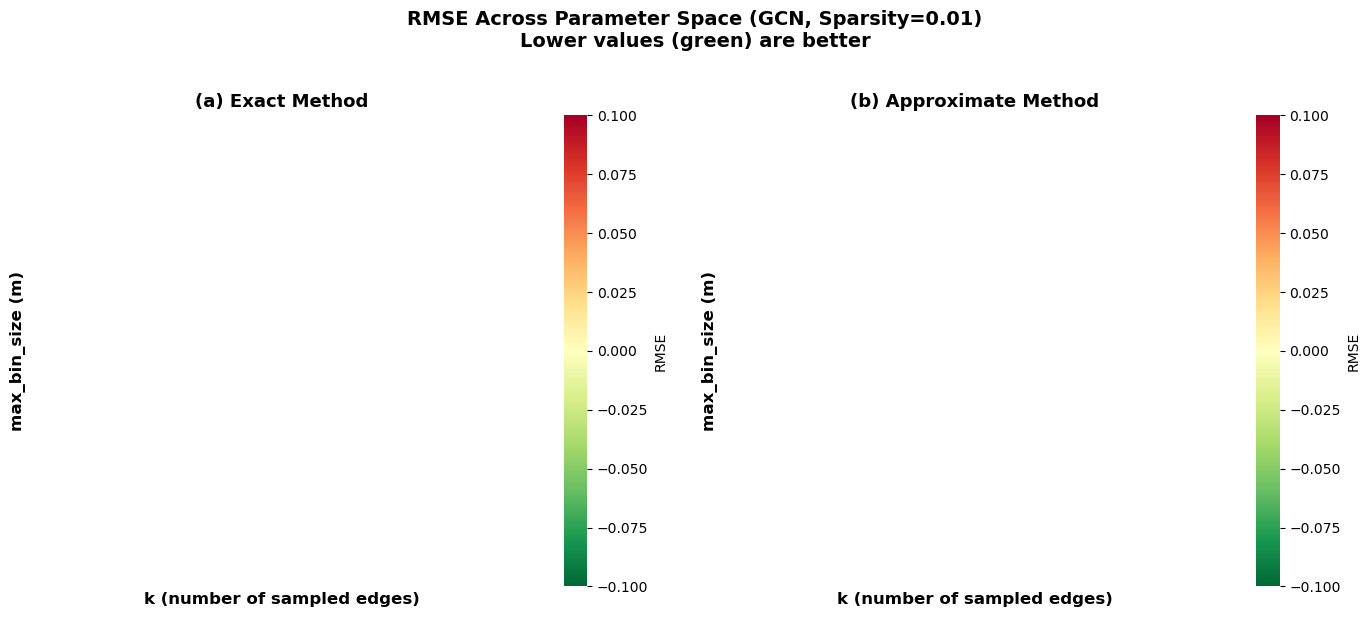


Generating Figure 2 (GAT)...


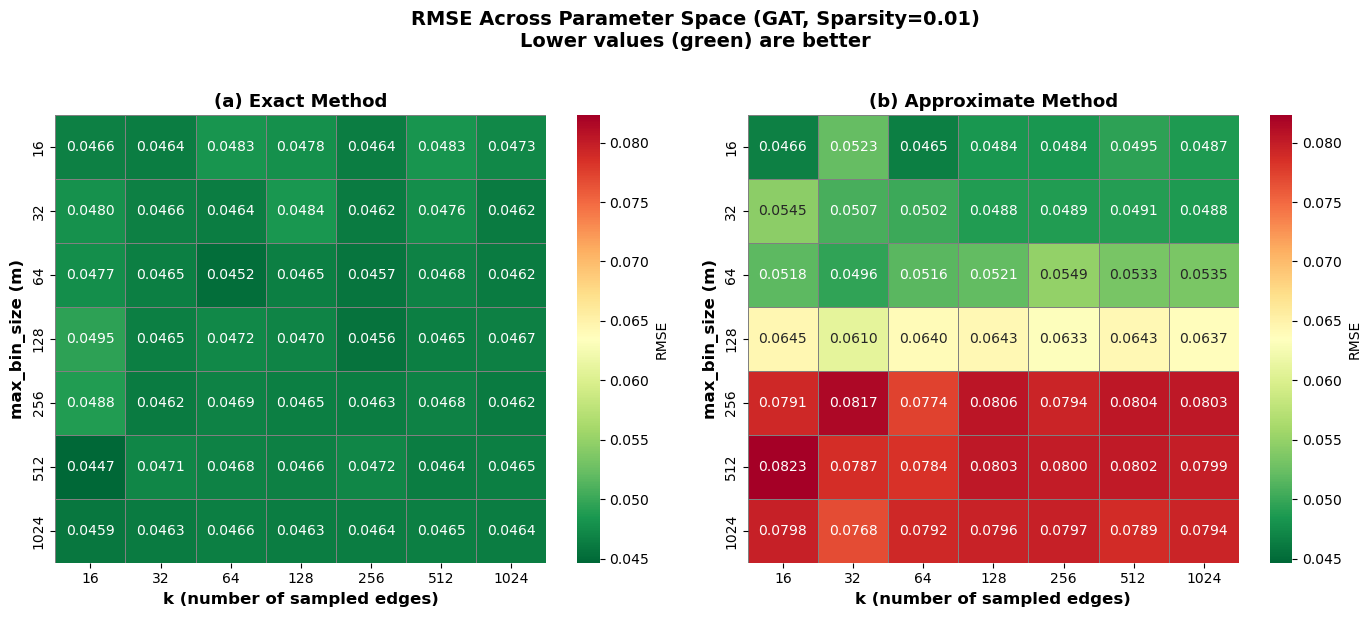


Generating enhanced heatmap with CV...


/tmp/ipykernel_2857877/2610064845.py:327: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_exact = pivot_exact_rmse.applymap(lambda x: f'{x:.4f}') + '\n(CV:' + pivot_exact_cv.applymap(lambda x: f'{x:.3f}') + ')'
/tmp/ipykernel_2857877/2610064845.py:328: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_approx = pivot_approx_rmse.applymap(lambda x: f'{x:.4f}') + '\n(CV:' + pivot_approx_cv.applymap(lambda x: f'{x:.3f}') + ')'
/home/pkaczyns/miniconda3/envs/ale_conda/lib/python3.10/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/home/pkaczyns/miniconda3/envs/ale_conda/lib/python3.10/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax

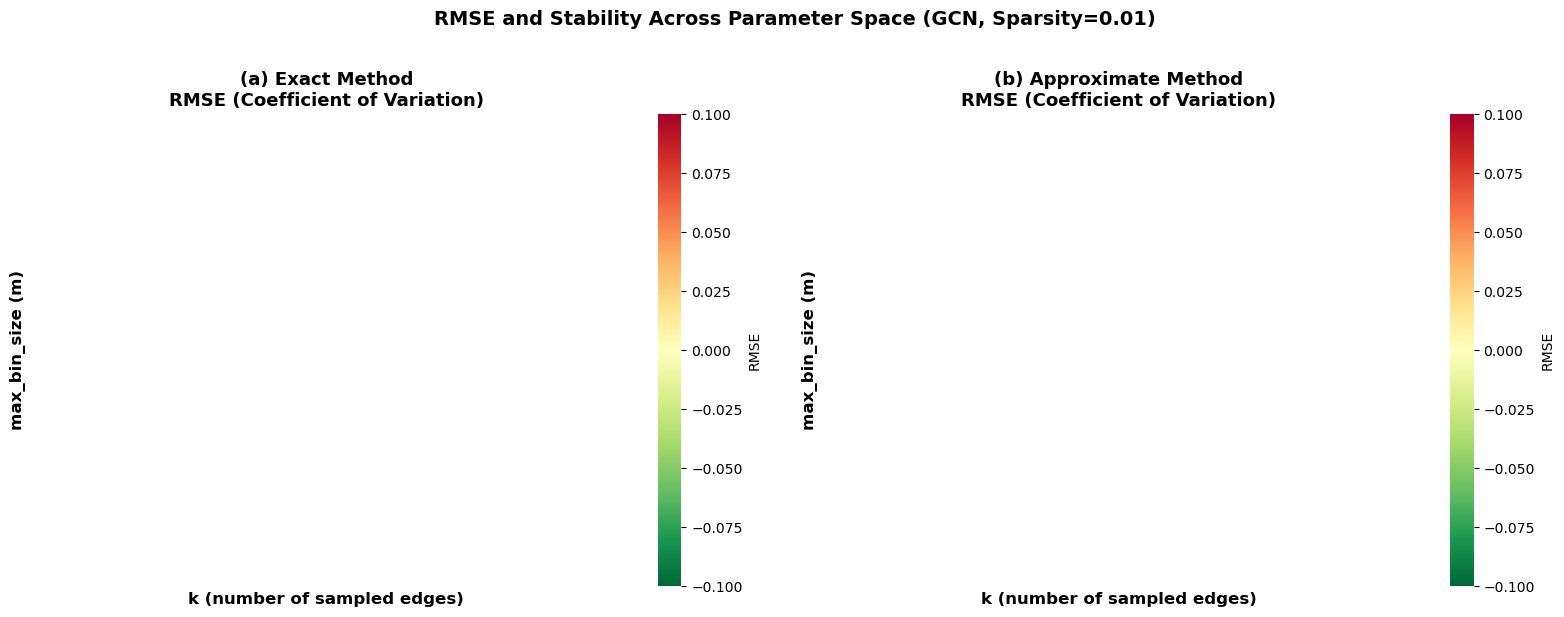


All figures generated successfully!


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

# Assuming your df has columns: index, feature, groundtruth, explanation_exact, explanation_approximate,
# time_exact, time_approximate, k, max_bin_size, seed, sparsity, trial, AUC
# AND a column called 'model' or 'architecture' with values 'GCN' or 'GAT'

# If you don't have a model column, you'll need to add it to your data
# For now, I'll assume it exists as 'model'

def calculate_metrics_with_model(df):
    """
    Calculate RMSE metrics including model/architecture type
    """
    # Get groundtruth for each index
    groundtruth_df = df.groupby(['index']).agg({'feature': 'first', 'groundtruth': 'first'}).reset_index()
    groundtruth_values = groundtruth_df['groundtruth'].values
    
    metrics_data = []
    
    # Group by model type as well
    for (k, max_bin_size, seed, sparsity, trial, model), group in df.groupby(['k', 'max_bin_size', 'seed', 'sparsity', 'trial', 'model']):
        group_sorted = group.sort_values('index')
        
        # Calculate RMSE
        rmse_exact = np.sqrt(mean_squared_error(groundtruth_values, group_sorted['explanation_exact'].values))
        rmse_approximate = np.sqrt(mean_squared_error(groundtruth_values, group_sorted['explanation_approximate'].values))
        
        # Get average time
        time_exact = group_sorted['time_exact'].mean()
        time_approximate = group_sorted['time_approximate'].mean()
        
        # Get AUC
        auc = group_sorted['AUC'].iloc[0]
        
        metrics_data.append({
            'k': k,
            'trial': trial,
            'max_bin_size': max_bin_size,
            'sparsity': sparsity,
            'seed': seed,
            'model': model,
            'rmse_exact': rmse_exact,
            'rmse_approximate': rmse_approximate,
            'time_exact': time_exact,
            'time_approximate': time_approximate,
            'auc': auc
        })
    
    return pd.DataFrame(metrics_data)

def calculate_variance_components(metrics_df):
    """
    Calculate between-seed and within-seed variance for RMSE
    """
    variance_data = []
    
    for (k, max_bin_size, sparsity, model), group in metrics_df.groupby(['k', 'max_bin_size', 'sparsity', 'model']):
        # Between-seed variance (variance of means across seeds)
        seed_means_exact = group.groupby('seed')['rmse_exact'].mean()
        seed_means_approx = group.groupby('seed')['rmse_approximate'].mean()
        
        between_seed_var_exact = seed_means_exact.var()
        between_seed_var_approx = seed_means_approx.var()
        
        # Within-seed variance (mean of variances within seeds)
        within_seed_var_exact = group.groupby('seed')['rmse_exact'].var().mean()
        within_seed_var_approx = group.groupby('seed')['rmse_approximate'].var().mean()
        
        # Total variance
        total_var_exact = between_seed_var_exact + within_seed_var_exact
        total_var_approx = between_seed_var_approx + within_seed_var_approx
        
        # Variance ratios
        between_ratio = between_seed_var_approx / between_seed_var_exact if between_seed_var_exact > 1e-10 else np.nan
        within_ratio = within_seed_var_approx / within_seed_var_exact if within_seed_var_exact > 1e-10 else np.nan
        total_ratio = total_var_approx / total_var_exact if total_var_exact > 1e-10 else np.nan
        
        variance_data.append({
            'k': k,
            'max_bin_size': max_bin_size,
            'sparsity': sparsity,
            'model': model,
            'between_seed_var_exact': between_seed_var_exact,
            'between_seed_var_approx': between_seed_var_approx,
            'within_seed_var_exact': within_seed_var_exact,
            'within_seed_var_approx': within_seed_var_approx,
            'total_var_exact': total_var_exact,
            'total_var_approx': total_var_approx,
            'between_var_ratio': between_ratio,
            'within_var_ratio': within_ratio,
            'total_var_ratio': total_ratio
        })
    
    return pd.DataFrame(variance_data)

# ============================================================================
# FIGURE 1: Main Result - RMSE and Variance Ratio vs max_bin_size
# ============================================================================
def plot_figure1_main_result(metrics_df, variance_df, sparsity_val=0.01, save_path=None):
    """
    Create Figure 1: RMSE with error bars + Variance Ratio
    Shows both GCN and GAT on same plot
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Filter to selected sparsity
    plot_data = metrics_df[metrics_df['sparsity'] == sparsity_val]
    var_plot_data = variance_df[variance_df['sparsity'] == sparsity_val]
    
    # Define colors and styles
    colors = {'Exact': '#3b82f6', 'Approximate': '#ef4444'}
    linestyles = {'GCN': '-', 'GAT': '--'}
    markers = {'GCN': 'o', 'GAT': 's'}
    
    # LEFT PLOT: RMSE vs max_bin_size with error bars (std across seeds)
    for model in ['GCN', 'GAT']:
        model_data = plot_data[plot_data['model'] == model]
        
        # Calculate mean and std across seeds for each max_bin_size
        rmse_stats = model_data.groupby('max_bin_size').agg({
            'rmse_exact': ['mean', 'std'],
            'rmse_approximate': ['mean', 'std']
        })
        
        max_bin_sizes = rmse_stats.index.values
        
        # Plot Exact
        ax1.errorbar(max_bin_sizes, 
                    rmse_stats['rmse_exact']['mean'],
                    yerr=rmse_stats['rmse_exact']['std'],
                    color=colors['Exact'],
                    linestyle=linestyles[model],
                    marker=markers[model],
                    markersize=7,
                    capsize=5,
                    capthick=2,
                    linewidth=2.5,
                    label=f'Exact ({model})',
                    alpha=0.9)
        
        # Plot Approximate
        ax1.errorbar(max_bin_sizes,
                    rmse_stats['rmse_approximate']['mean'],
                    yerr=rmse_stats['rmse_approximate']['std'],
                    color=colors['Approximate'],
                    linestyle=linestyles[model],
                    marker=markers[model],
                    markersize=7,
                    capsize=5,
                    capthick=2,
                    linewidth=2.5,
                    label=f'Approximate ({model})',
                    alpha=0.9)
    
    ax1.set_xlabel('max_bin_size (m)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('RMSE (mean ± std across seeds)', fontsize=13, fontweight='bold')
    ax1.set_title('(a) Divergence from Ground Truth', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10, framealpha=0.95, loc='best')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_xscale('log')
    
    # RIGHT PLOT: Variance Ratio vs max_bin_size
    for model in ['GCN', 'GAT']:
        model_var_data = var_plot_data[var_plot_data['model'] == model]
        
        # Average across k if needed
        var_by_binsize = model_var_data.groupby('max_bin_size').agg({
            'between_var_ratio': 'mean',
            'within_var_ratio': 'mean',
            'total_var_ratio': 'mean'
        })
        
        max_bin_sizes = var_by_binsize.index.values
        
        # Plot between-seed variance ratio
        ax2.plot(max_bin_sizes,
                var_by_binsize['between_var_ratio'],
                color='#8b5cf6',
                linestyle=linestyles[model],
                marker=markers[model],
                markersize=7,
                linewidth=2.5,
                label=f'Between-seed ({model})',
                alpha=0.9)
        
        # Plot within-seed variance ratio
        ax2.plot(max_bin_sizes,
                var_by_binsize['within_var_ratio'],
                color='#f97316',
                linestyle=linestyles[model],
                marker=markers[model],
                markersize=7,
                linewidth=2.5,
                label=f'Within-seed ({model})',
                alpha=0.9)
    
    # Add reference line at 1.0 (equal variance)
    ax2.axhline(y=1.0, color='gray', linestyle=':', linewidth=2, alpha=0.7, label='Equal variance')
    
    ax2.set_xlabel('max_bin_size (m)', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Variance Ratio (Approximate / Exact)', fontsize=13, fontweight='bold')
    ax2.set_title('(b) Variance Comparison', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10, framealpha=0.95, loc='best')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xscale('log')
    
    # Add annotation explaining >1
    ax2.text(0.98, 0.02, 'Ratio > 1: Approximate more variable', 
            transform=ax2.transAxes, fontsize=9, 
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.suptitle(f'Approximate Method Degrades with Increasing max_bin_size (Sparsity={sparsity_val})',
                fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig

# ============================================================================
# FIGURE 2: Heatmap of RMSE for full parameter space
# ============================================================================
def plot_figure2_heatmap(metrics_df, sparsity_val=0.01, model_val='GCN', save_path=None):
    """
    Create Figure 2: Heatmap showing RMSE across k × max_bin_size
    Two subplots side-by-side (Exact vs Approximate) with SAME colorscale
    """
    # Filter data
    plot_data = metrics_df[(metrics_df['sparsity'] == sparsity_val) & 
                          (metrics_df['model'] == model_val)]
    
    # Calculate mean RMSE across seeds and trials
    heatmap_data = plot_data.groupby(['k', 'max_bin_size']).agg({
        'rmse_exact': 'mean',
        'rmse_approximate': 'mean'
    }).reset_index()
    
    # Create pivot tables
    pivot_exact = heatmap_data.pivot(index='max_bin_size', columns='k', values='rmse_exact')
    pivot_approx = heatmap_data.pivot(index='max_bin_size', columns='k', values='rmse_approximate')
    
    # Find global min/max for consistent colorscale
    vmin = min(pivot_exact.min().min(), pivot_approx.min().min())
    vmax = max(pivot_exact.max().max(), pivot_approx.max().max())
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot Exact method heatmap
    sns.heatmap(pivot_exact, 
                annot=True, 
                fmt='.4f', 
                cmap='RdYlGn_r',
                vmin=vmin,
                vmax=vmax,
                ax=ax1,
                cbar_kws={'label': 'RMSE'},
                linewidths=0.5,
                linecolor='gray')
    ax1.set_xlabel('k (number of sampled edges)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('max_bin_size (m)', fontsize=12, fontweight='bold')
    ax1.set_title(f'(a) Exact Method', fontsize=13, fontweight='bold')
    
    # Plot Approximate method heatmap
    sns.heatmap(pivot_approx, 
                annot=True, 
                fmt='.4f', 
                cmap='RdYlGn_r',
                vmin=vmin,
                vmax=vmax,
                ax=ax2,
                cbar_kws={'label': 'RMSE'},
                linewidths=0.5,
                linecolor='gray')
    ax2.set_xlabel('k (number of sampled edges)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('max_bin_size (m)', fontsize=12, fontweight='bold')
    ax2.set_title(f'(b) Approximate Method', fontsize=13, fontweight='bold')
    
    plt.suptitle(f'RMSE Across Parameter Space ({model_val}, Sparsity={sparsity_val})\nLower values (green) are better',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig

# ============================================================================
# OPTIONAL: Heatmap with Coefficient of Variation annotations
# ============================================================================
def plot_figure2_heatmap_with_cv(metrics_df, sparsity_val=0.01, model_val='GCN', save_path=None):
    """
    Enhanced version: Heatmap with RMSE as colors and CV as text annotations
    """
    # Filter data
    plot_data = metrics_df[(metrics_df['sparsity'] == sparsity_val) & 
                          (metrics_df['model'] == model_val)]
    
    # Calculate mean RMSE and CV
    heatmap_data = plot_data.groupby(['k', 'max_bin_size']).agg({
        'rmse_exact': ['mean', 'std'],
        'rmse_approximate': ['mean', 'std']
    }).reset_index()
    
    # Calculate CV
    heatmap_data['cv_exact'] = heatmap_data[('rmse_exact', 'std')] / heatmap_data[('rmse_exact', 'mean')]
    heatmap_data['cv_approx'] = heatmap_data[('rmse_approximate', 'std')] / heatmap_data[('rmse_approximate', 'mean')]
    
    # Flatten column names
    heatmap_data.columns = ['k', 'max_bin_size', 'rmse_exact_mean', 'rmse_exact_std', 
                            'rmse_approx_mean', 'rmse_approx_std', 'cv_exact', 'cv_approx']
    
    # Create pivot tables for RMSE (colors)
    pivot_exact_rmse = heatmap_data.pivot(index='max_bin_size', columns='k', values='rmse_exact_mean')
    pivot_approx_rmse = heatmap_data.pivot(index='max_bin_size', columns='k', values='rmse_approx_mean')
    
    # Create pivot tables for CV (annotations)
    pivot_exact_cv = heatmap_data.pivot(index='max_bin_size', columns='k', values='cv_exact')
    pivot_approx_cv = heatmap_data.pivot(index='max_bin_size', columns='k', values='cv_approx')
    
    # Create annotation strings combining RMSE and CV
    annot_exact = pivot_exact_rmse.applymap(lambda x: f'{x:.4f}') + '\n(CV:' + pivot_exact_cv.applymap(lambda x: f'{x:.3f}') + ')'
    annot_approx = pivot_approx_rmse.applymap(lambda x: f'{x:.4f}') + '\n(CV:' + pivot_approx_cv.applymap(lambda x: f'{x:.3f}') + ')'
    
    # Find global min/max for consistent colorscale
    vmin = min(pivot_exact_rmse.min().min(), pivot_approx_rmse.min().min())
    vmax = max(pivot_exact_rmse.max().max(), pivot_approx_rmse.max().max())
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot Exact method heatmap
    sns.heatmap(pivot_exact_rmse, 
                annot=annot_exact,
                fmt='',
                cmap='RdYlGn_r',
                vmin=vmin,
                vmax=vmax,
                ax=ax1,
                cbar_kws={'label': 'RMSE'},
                linewidths=0.5,
                linecolor='gray')
    ax1.set_xlabel('k (number of sampled edges)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('max_bin_size (m)', fontsize=12, fontweight='bold')
    ax1.set_title(f'(a) Exact Method\nRMSE (Coefficient of Variation)', fontsize=13, fontweight='bold')
    
    # Plot Approximate method heatmap
    sns.heatmap(pivot_approx_rmse, 
                annot=annot_approx,
                fmt='',
                cmap='RdYlGn_r',
                vmin=vmin,
                vmax=vmax,
                ax=ax2,
                cbar_kws={'label': 'RMSE'},
                linewidths=0.5,
                linecolor='gray')
    ax2.set_xlabel('k (number of sampled edges)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('max_bin_size (m)', fontsize=12, fontweight='bold')
    ax2.set_title(f'(b) Approximate Method\nRMSE (Coefficient of Variation)', fontsize=13, fontweight='bold')
    
    plt.suptitle(f'RMSE and Stability Across Parameter Space ({model_val}, Sparsity={sparsity_val})',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig

# ============================================================================
# Main execution
# ============================================================================
if __name__ == "__main__":
    # Calculate metrics
    print("Calculating metrics...")
    metrics_df = calculate_metrics_with_model(df)  # Your df should have 'model' column
    
    print("Calculating variance components...")
    variance_df = calculate_variance_components(metrics_df)
    
    # Generate Figure 1: Main result
    print("\nGenerating Figure 1...")
    fig1 = plot_figure1_main_result(metrics_df, variance_df, 
                                    sparsity_val=0.01, 
                                    save_path='figure1_main_result.png')
    plt.show()
    
    # Generate Figure 2: Heatmap (for each model separately)
    print("\nGenerating Figure 2 (GCN)...")
    fig2_gcn = plot_figure2_heatmap(metrics_df, 
                                    sparsity_val=0.01, 
                                    model_val='GCN',
                                    save_path='figure2_heatmap_gcn.png')
    plt.show()
    
    print("\nGenerating Figure 2 (GAT)...")
    fig2_gat = plot_figure2_heatmap(metrics_df, 
                                    sparsity_val=0.01, 
                                    model_val='GAT',
                                    save_path='figure2_heatmap_gat.png')
    plt.show()
    
    # Optional: Generate enhanced heatmap with CV
    print("\nGenerating enhanced heatmap with CV...")
    fig2_enhanced = plot_figure2_heatmap_with_cv(metrics_df,
                                                 sparsity_val=0.01,
                                                 model_val='GCN',
                                                 save_path='figure2_heatmap_with_cv.png')
    plt.show()
    
    print("\nAll figures generated successfully!")

# Usage examples:
# 
# # If you want different sparsity:
# fig1 = plot_figure1_main_result(metrics_df, variance_df, sparsity_val=0.1)
#
# # If you want to show multiple sparsities, call the function multiple times
# for sparsity in [0.001, 0.01, 0.1]:
#     fig = plot_figure1_main_result(metrics_df, variance_df, 
#                                    sparsity_val=sparsity,
#                                    save_path=f'figure1_sparsity_{sparsity}.png')['model'] = 'GAT'

In [ ]:
metrics_df

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

# Assuming your df has columns: index, feature, groundtruth, explanation_exact, explanation_approximate,
# time_exact, time_approximate, k, max_bin_size, seed, sparsity, trial, AUC
# AND a column called 'model' or 'architecture' with values 'GCN' or 'GAT'

# If you don't have a model column, you'll need to add it to your data
# For now, I'll assume it exists as 'model'

def calculate_metrics_with_model(df):
    """
    Calculate RMSE metrics including model/architecture type
    """
    # Get groundtruth for each index
    groundtruth_df = df.groupby(['index']).agg({'feature': 'first', 'groundtruth': 'first'}).reset_index()
    groundtruth_values = groundtruth_df['groundtruth'].values
    
    metrics_data = []
    
    # Group by model type as well
    for (k, max_bin_size, seed, sparsity, trial, model), group in df.groupby(['k', 'max_bin_size', 'seed', 'sparsity', 'trial', 'model']):
        group_sorted = group.sort_values('index')
        
        # Calculate RMSE
        rmse_exact = np.sqrt(mean_squared_error(groundtruth_values, group_sorted['explanation_exact'].values))
        rmse_approximate = np.sqrt(mean_squared_error(groundtruth_values, group_sorted['explanation_approximate'].values))
        
        # Get average time
        time_exact = group_sorted['time_exact'].mean()
        time_approximate = group_sorted['time_approximate'].mean()
        
        # Get AUC
        auc = group_sorted['AUC'].iloc[0]
        
        metrics_data.append({
            'k': k,
            'trial': trial,
            'max_bin_size': max_bin_size,
            'sparsity': sparsity,
            'seed': seed,
            'model': model,
            'rmse_exact': rmse_exact,
            'rmse_approximate': rmse_approximate,
            'time_exact': time_exact,
            'time_approximate': time_approximate,
            'auc': auc
        })
    
    return pd.DataFrame(metrics_data)

def calculate_variance_components(metrics_df):
    """
    Calculate between-seed and within-seed variance for RMSE
    """
    variance_data = []
    
    for (k, max_bin_size, sparsity, model), group in metrics_df.groupby(['k', 'max_bin_size', 'sparsity', 'model']):
        # Between-seed variance (variance of means across seeds)
        seed_means_exact = group.groupby('seed')['rmse_exact'].mean()
        seed_means_approx = group.groupby('seed')['rmse_approximate'].mean()
        
        between_seed_var_exact = seed_means_exact.var()
        between_seed_var_approx = seed_means_approx.var()
        
        # Within-seed variance (mean of variances within seeds)
        within_seed_var_exact = group.groupby('seed')['rmse_exact'].var().mean()
        within_seed_var_approx = group.groupby('seed')['rmse_approximate'].var().mean()
        
        # Total variance
        total_var_exact = between_seed_var_exact + within_seed_var_exact
        total_var_approx = between_seed_var_approx + within_seed_var_approx
        
        # Variance ratios
        between_ratio = between_seed_var_approx / between_seed_var_exact if between_seed_var_exact > 1e-10 else np.nan
        within_ratio = within_seed_var_approx / within_seed_var_exact if within_seed_var_exact > 1e-10 else np.nan
        total_ratio = total_var_approx / total_var_exact if total_var_exact > 1e-10 else np.nan
        
        variance_data.append({
            'k': k,
            'max_bin_size': max_bin_size,
            'sparsity': sparsity,
            'model': model,
            'between_seed_var_exact': between_seed_var_exact,
            'between_seed_var_approx': between_seed_var_approx,
            'within_seed_var_exact': within_seed_var_exact,
            'within_seed_var_approx': within_seed_var_approx,
            'total_var_exact': total_var_exact,
            'total_var_approx': total_var_approx,
            'between_var_ratio': between_ratio,
            'within_var_ratio': within_ratio,
            'total_var_ratio': total_ratio
        })
    
    return pd.DataFrame(variance_data)

# ============================================================================
# FIGURE 1: Main Result - RMSE and Variance Ratio vs max_bin_size
# ============================================================================
def plot_figure1_main_result(metrics_df, variance_df, sparsity_val=0.01, save_path=None):
    """
    Create Figure 1: RMSE with error bars + Variance Ratio
    Shows both GCN and GAT on same plot
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Filter to selected sparsity
    plot_data = metrics_df[metrics_df['sparsity'] == sparsity_val]
    var_plot_data = variance_df[variance_df['sparsity'] == sparsity_val]
    
    # Define colors and styles
    colors = {'Exact': '#3b82f6', 'Approximate': '#ef4444'}
    linestyles = {'GCN': '-', 'GAT': '--'}
    markers = {'GCN': 'o', 'GAT': 's'}
    
    # LEFT PLOT: RMSE vs max_bin_size with error bars (std across seeds)
    for model in ['GCN', 'GAT']:
        model_data = plot_data[plot_data['model'] == model]
        
        # Calculate mean and std across seeds for each max_bin_size
        rmse_stats = model_data.groupby('max_bin_size').agg({
            'rmse_exact': ['mean', 'std'],
            'rmse_approximate': ['mean', 'std']
        })
        
        max_bin_sizes = rmse_stats.index.values
        
        # Plot Exact
        ax1.errorbar(max_bin_sizes, 
                    rmse_stats['rmse_exact']['mean'],
                    yerr=rmse_stats['rmse_exact']['std'],
                    color=colors['Exact'],
                    linestyle=linestyles[model],
                    marker=markers[model],
                    markersize=7,
                    capsize=5,
                    capthick=2,
                    linewidth=2.5,
                    label=f'Exact ({model})',
                    alpha=0.9)
        
        # Plot Approximate
        ax1.errorbar(max_bin_sizes,
                    rmse_stats['rmse_approximate']['mean'],
                    yerr=rmse_stats['rmse_approximate']['std'],
                    color=colors['Approximate'],
                    linestyle=linestyles[model],
                    marker=markers[model],
                    markersize=7,
                    capsize=5,
                    capthick=2,
                    linewidth=2.5,
                    label=f'Approximate ({model})',
                    alpha=0.9)
    
    ax1.set_xlabel('max_bin_size (m)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('RMSE (mean ± std across seeds)', fontsize=13, fontweight='bold')
    ax1.set_title('(a) Divergence from Ground Truth', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10, framealpha=0.95, loc='best')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_xscale('log')
    
    # RIGHT PLOT: Variance Ratio vs max_bin_size
    for model in ['GCN', 'GAT']:
        model_var_data = var_plot_data[var_plot_data['model'] == model]
        
        # Average across k if needed
        var_by_binsize = model_var_data.groupby('max_bin_size').agg({
            'between_var_ratio': 'mean',
            'within_var_ratio': 'mean',
            'total_var_ratio': 'mean'
        })
        
        max_bin_sizes = var_by_binsize.index.values
        
        # Plot between-seed variance ratio
        ax2.plot(max_bin_sizes,
                var_by_binsize['between_var_ratio'],
                color='#8b5cf6',
                linestyle=linestyles[model],
                marker=markers[model],
                markersize=7,
                linewidth=2.5,
                label=f'Between-seed ({model})',
                alpha=0.9)
        
        # Plot within-seed variance ratio
        ax2.plot(max_bin_sizes,
                var_by_binsize['within_var_ratio'],
                color='#f97316',
                linestyle=linestyles[model],
                marker=markers[model],
                markersize=7,
                linewidth=2.5,
                label=f'Within-seed ({model})',
                alpha=0.9)
    
    # Add reference line at 1.0 (equal variance)
    ax2.axhline(y=1.0, color='gray', linestyle=':', linewidth=2, alpha=0.7, label='Equal variance')
    
    ax2.set_xlabel('max_bin_size (m)', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Variance Ratio (Approximate / Exact)', fontsize=13, fontweight='bold')
    ax2.set_title('(b) Variance Comparison', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10, framealpha=0.95, loc='best')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xscale('log')
    
    # Add annotation explaining >1
    ax2.text(0.98, 0.02, 'Ratio > 1: Approximate more variable', 
            transform=ax2.transAxes, fontsize=9, 
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.suptitle(f'Approximate Method Degrades with Increasing max_bin_size (Sparsity={sparsity_val})',
                fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig

# ============================================================================
# FIGURE 2: Heatmap of RMSE for full parameter space
# ============================================================================
def plot_figure2_heatmap(metrics_df, sparsity_val=0.01, model_val='GCN', save_path=None):
    """
    Create Figure 2: Heatmap showing RMSE across k × max_bin_size
    Two subplots side-by-side (Exact vs Approximate) with SAME colorscale
    """
    # Filter data
    plot_data = metrics_df[(metrics_df['sparsity'] == sparsity_val) & 
                          (metrics_df['model'] == model_val)]
    
    # Calculate mean RMSE across seeds and trials
    heatmap_data = plot_data.groupby(['k', 'max_bin_size']).agg({
        'rmse_exact': 'mean',
        'rmse_approximate': 'mean'
    }).reset_index()
    
    # Create pivot tables
    pivot_exact = heatmap_data.pivot(index='max_bin_size', columns='k', values='rmse_exact')
    pivot_approx = heatmap_data.pivot(index='max_bin_size', columns='k', values='rmse_approximate')
    
    # Find global min/max for consistent colorscale
    vmin = min(pivot_exact.min().min(), pivot_approx.min().min())
    vmax = max(pivot_exact.max().max(), pivot_approx.max().max())
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot Exact method heatmap
    sns.heatmap(pivot_exact, 
                annot=True, 
                fmt='.4f', 
                cmap='RdYlGn_r',
                vmin=vmin,
                vmax=vmax,
                ax=ax1,
                cbar_kws={'label': 'RMSE'},
                linewidths=0.5,
                linecolor='gray')
    ax1.set_xlabel('k (number of sampled edges)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('max_bin_size (m)', fontsize=12, fontweight='bold')
    ax1.set_title(f'(a) Exact Method', fontsize=13, fontweight='bold')
    
    # Plot Approximate method heatmap
    sns.heatmap(pivot_approx, 
                annot=True, 
                fmt='.4f', 
                cmap='RdYlGn_r',
                vmin=vmin,
                vmax=vmax,
                ax=ax2,
                cbar_kws={'label': 'RMSE'},
                linewidths=0.5,
                linecolor='gray')
    ax2.set_xlabel('k (number of sampled edges)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('max_bin_size (m)', fontsize=12, fontweight='bold')
    ax2.set_title(f'(b) Approximate Method', fontsize=13, fontweight='bold')
    
    plt.suptitle(f'RMSE Across Parameter Space ({model_val}, Sparsity={sparsity_val})\nLower values (green) are better',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig

# ============================================================================
# OPTIONAL: Heatmap with Coefficient of Variation annotations
# ============================================================================
def plot_figure2_heatmap_with_cv(metrics_df, sparsity_val=0.01, model_val='GCN', save_path=None):
    """
    Enhanced version: Heatmap with RMSE as colors and CV as text annotations
    """
    # Filter data
    plot_data = metrics_df[(metrics_df['sparsity'] == sparsity_val) & 
                          (metrics_df['model'] == model_val)]
    
    # Calculate mean RMSE and CV
    heatmap_data = plot_data.groupby(['k', 'max_bin_size']).agg({
        'rmse_exact': ['mean', 'std'],
        'rmse_approximate': ['mean', 'std']
    }).reset_index()
    
    # Calculate CV
    heatmap_data['cv_exact'] = heatmap_data[('rmse_exact', 'std')] / heatmap_data[('rmse_exact', 'mean')]
    heatmap_data['cv_approx'] = heatmap_data[('rmse_approximate', 'std')] / heatmap_data[('rmse_approximate', 'mean')]
    
    # Flatten column names
    heatmap_data.columns = ['k', 'max_bin_size', 'rmse_exact_mean', 'rmse_exact_std', 
                            'rmse_approx_mean', 'rmse_approx_std', 'cv_exact', 'cv_approx']
    
    # Create pivot tables for RMSE (colors)
    pivot_exact_rmse = heatmap_data.pivot(index='max_bin_size', columns='k', values='rmse_exact_mean')
    pivot_approx_rmse = heatmap_data.pivot(index='max_bin_size', columns='k', values='rmse_approx_mean')
    
    # Create pivot tables for CV (annotations)
    pivot_exact_cv = heatmap_data.pivot(index='max_bin_size', columns='k', values='cv_exact')
    pivot_approx_cv = heatmap_data.pivot(index='max_bin_size', columns='k', values='cv_approx')
    
    # Create annotation strings combining RMSE and CV
    annot_exact = pivot_exact_rmse.applymap(lambda x: f'{x:.4f}') + '\n(CV:' + pivot_exact_cv.applymap(lambda x: f'{x:.3f}') + ')'
    annot_approx = pivot_approx_rmse.applymap(lambda x: f'{x:.4f}') + '\n(CV:' + pivot_approx_cv.applymap(lambda x: f'{x:.3f}') + ')'
    
    # Find global min/max for consistent colorscale
    vmin = min(pivot_exact_rmse.min().min(), pivot_approx_rmse.min().min())
    vmax = max(pivot_exact_rmse.max().max(), pivot_approx_rmse.max().max())
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot Exact method heatmap
    sns.heatmap(pivot_exact_rmse, 
                annot=annot_exact,
                fmt='',
                cmap='RdYlGn_r',
                vmin=vmin,
                vmax=vmax,
                ax=ax1,
                cbar_kws={'label': 'RMSE'},
                linewidths=0.5,
                linecolor='gray')
    ax1.set_xlabel('k (number of sampled edges)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('max_bin_size (m)', fontsize=12, fontweight='bold')
    ax1.set_title(f'(a) Exact Method\nRMSE (Coefficient of Variation)', fontsize=13, fontweight='bold')
    
    # Plot Approximate method heatmap
    sns.heatmap(pivot_approx_rmse, 
                annot=annot_approx,
                fmt='',
                cmap='RdYlGn_r',
                vmin=vmin,
                vmax=vmax,
                ax=ax2,
                cbar_kws={'label': 'RMSE'},
                linewidths=0.5,
                linecolor='gray')
    ax2.set_xlabel('k (number of sampled edges)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('max_bin_size (m)', fontsize=12, fontweight='bold')
    ax2.set_title(f'(b) Approximate Method\nRMSE (Coefficient of Variation)', fontsize=13, fontweight='bold')
    
    plt.suptitle(f'RMSE and Stability Across Parameter Space ({model_val}, Sparsity={sparsity_val})',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig

# ============================================================================
# Main execution
# ============================================================================
if __name__ == "__main__":
    # Calculate metrics
    print("Calculating metrics...")
    metrics_df = calculate_metrics_with_model(df)  # Your df should have 'model' column
    
    print("Calculating variance components...")
    variance_df = calculate_variance_components(metrics_df)
    
    # Generate Figure 1: Main result
    print("\nGenerating Figure 1...")
    fig1 = plot_figure1_main_result(metrics_df, variance_df, 
                                    sparsity_val=0.01, 
                                    save_path='figure1_main_result.png')
    plt.show()
    
    # Generate Figure 2: Heatmap (for each model separately)
    print("\nGenerating Figure 2 (GCN)...")
    fig2_gcn = plot_figure2_heatmap(metrics_df, 
                                    sparsity_val=0.01, 
                                    model_val='GCN',
                                    save_path='figure2_heatmap_gcn.png')
    plt.show()
    
    print("\nGenerating Figure 2 (GAT)...")
    fig2_gat = plot_figure2_heatmap(metrics_df, 
                                    sparsity_val=0.01, 
                                    model_val='GAT',
                                    save_path='figure2_heatmap_gat.png')
    plt.show()
    
    # Optional: Generate enhanced heatmap with CV
    print("\nGenerating enhanced heatmap with CV...")
    fig2_enhanced = plot_figure2_heatmap_with_cv(metrics_df,
                                                 sparsity_val=0.01,
                                                 model_val='GCN',
                                                 save_path='figure2_heatmap_with_cv.png')
    plt.show()
    
    print("\nAll figures generated successfully!")

# Usage examples:
# 
# # If you want different sparsity:
fig1 = plot_figure1_main_result(metrics_df, variance_df, sparsity_val=0.1)
#
# # If you want to show multiple sparsities, call the function multiple times
# for sparsity in [0.001, 0.01, 0.1]:
#     fig = plot_figure1_main_result(metrics_df, variance_df, 
#                                    sparsity_val=sparsity,
#                                    save_path=f'figure1_sparsity_{sparsity}.png')

Calculating metrics...


KeyError: 'model'

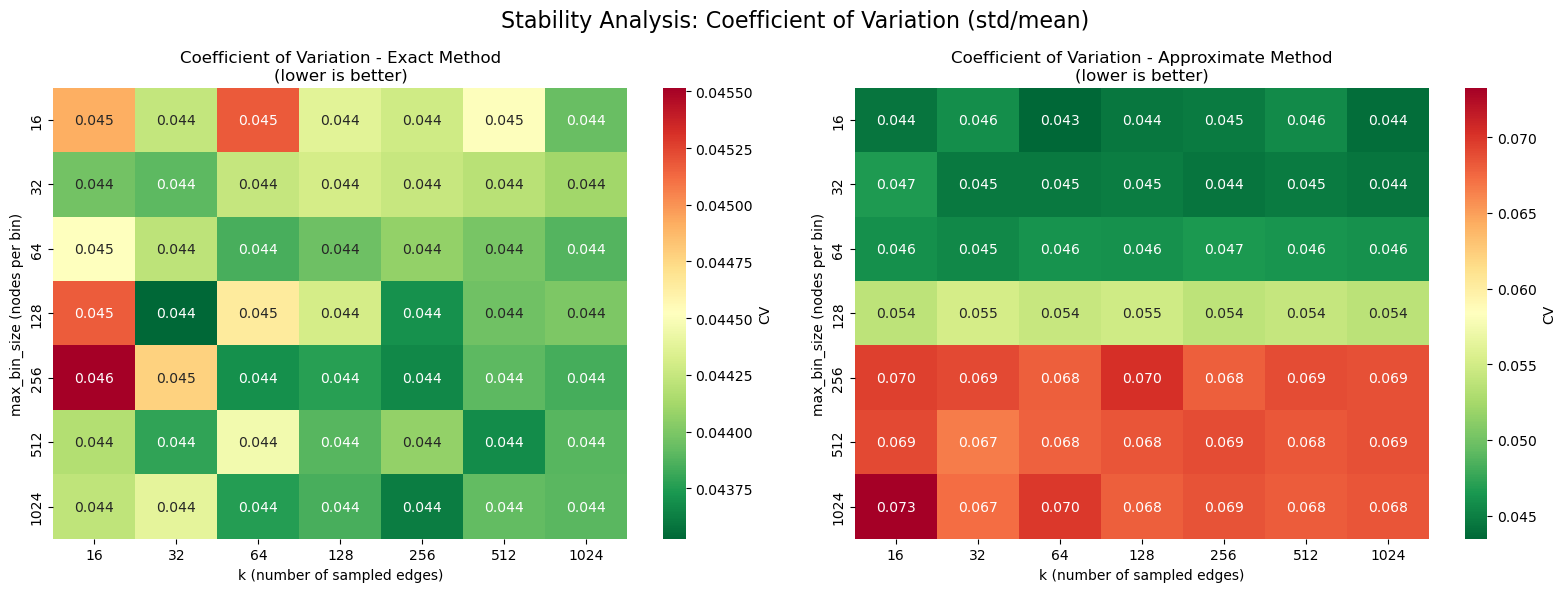

In [ ]:
cv_exact = metrics_df.groupby(['k', 'max_bin_size'])['rmse_exact'].agg(['mean', 'std'])
cv_exact['cv'] = cv_exact['mean']
cv_approx = metrics_df.groupby(['k', 'max_bin_size'])['rmse_approximate'].agg(['mean', 'std'])
cv_approx['cv'] = cv_approx['mean']

pivot_cv_exact = cv_exact['cv'].reset_index().pivot(index='max_bin_size', columns='k', values='cv')
pivot_cv_approx = cv_approx['cv'].reset_index().pivot(index='max_bin_size', columns='k', values='cv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pivot_cv_exact, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax1, cbar_kws={'label': 'CV'})
ax1.set_xlabel('k (number of sampled edges)')
ax1.set_ylabel('max_bin_size (nodes per bin)')
ax1.set_title('Coefficient of Variation - Exact Method\n(lower is better)')

sns.heatmap(pivot_cv_approx, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax2, cbar_kws={'label': 'CV'})
ax2.set_xlabel('k (number of sampled edges)')
ax2.set_ylabel('max_bin_size (nodes per bin)')
ax2.set_title('Coefficient of Variation - Approximate Method\n(lower is better)')

plt.suptitle('Stability Analysis: Coefficient of Variation (std/mean)', fontsize=16)
plt.tight_layout()
plt.show()

SUMMARY STATISTICS
        k  max_bin_size  sparsity  r2_exact_mean  r2_exact_std  r2_exact_min  \
0      16            16     0.001       0.916398      0.051138      0.836147   
1      16            16     0.010       0.926346      0.014197      0.905017   
2      16            16     0.100       0.921256      0.016143      0.900659   
3      16            32     0.001       0.930439      0.038069      0.869712   
4      16            32     0.010       0.921582      0.013112      0.908388   
..    ...           ...       ...            ...           ...           ...   
142  1024           512     0.010       0.927173      0.007301      0.917549   
143  1024           512     0.100       0.923928      0.012195      0.912423   
144  1024          1024     0.001       0.923849      0.035516      0.874844   
145  1024          1024     0.010       0.927186      0.007961      0.918255   
146  1024          1024     0.100       0.923754      0.011332      0.912762   

     r2_exact_max  r

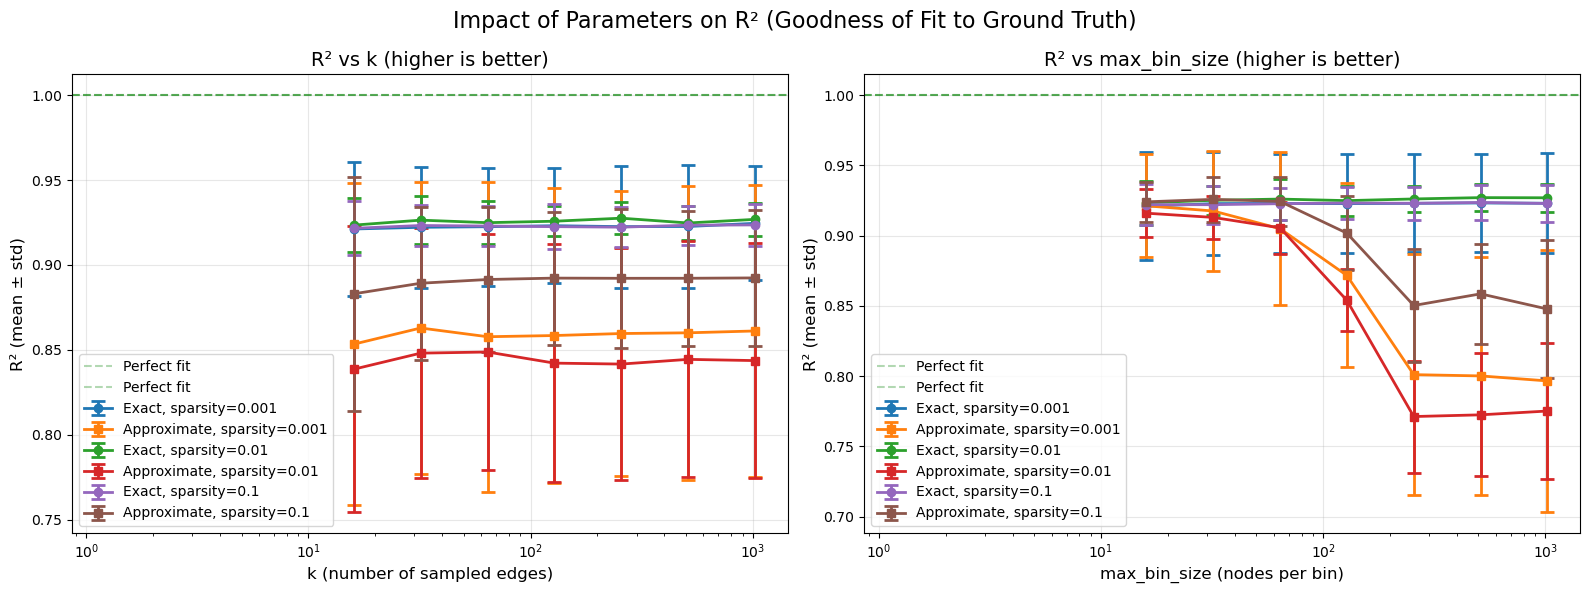

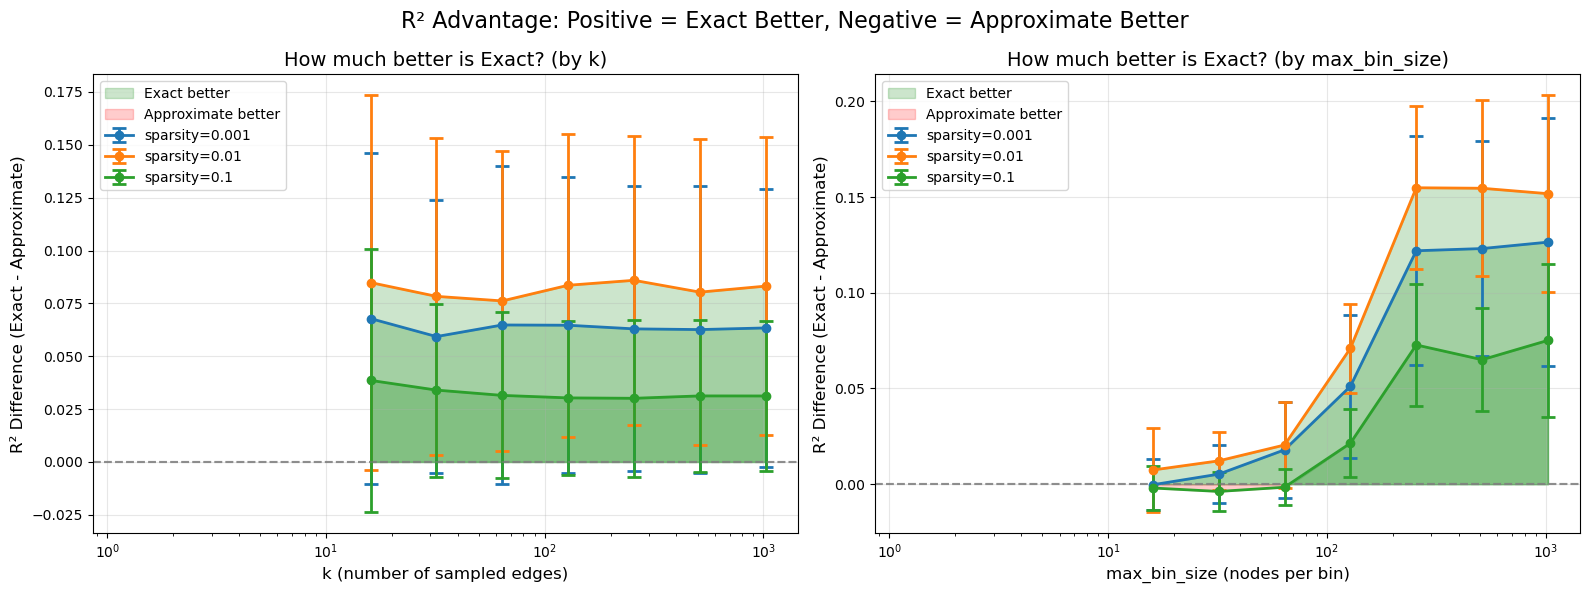

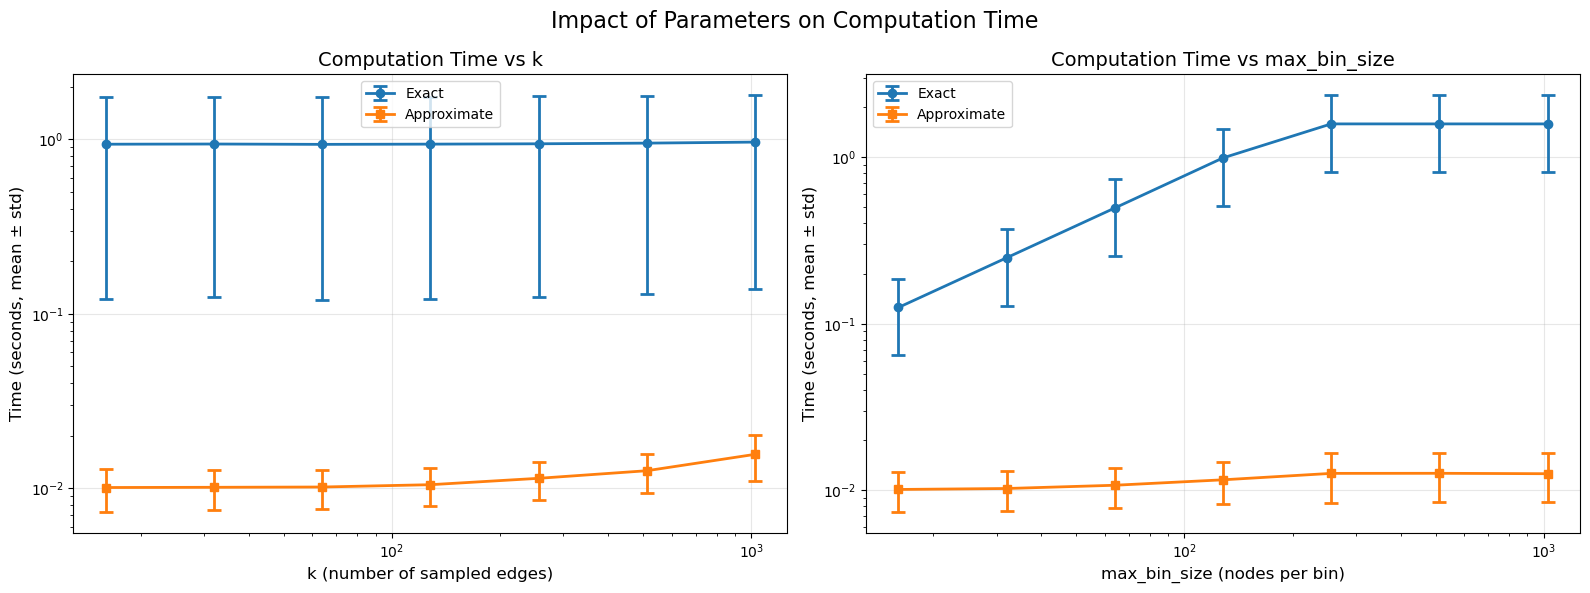

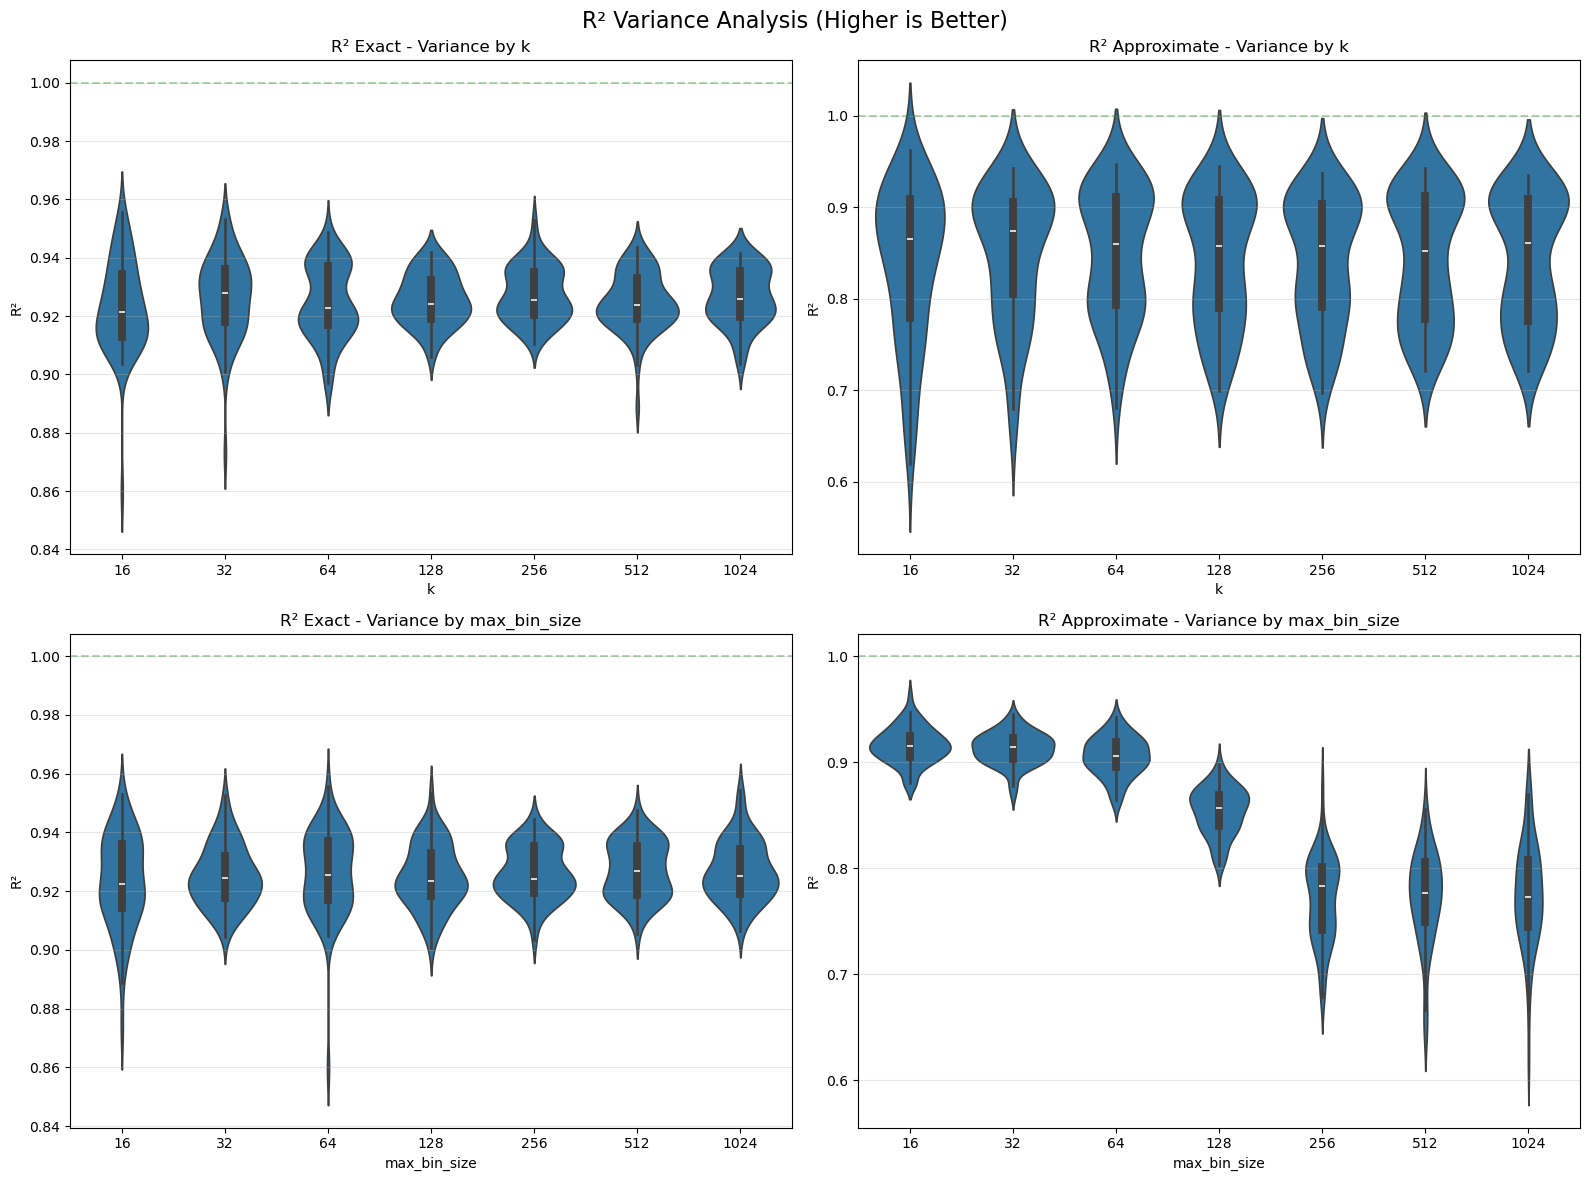

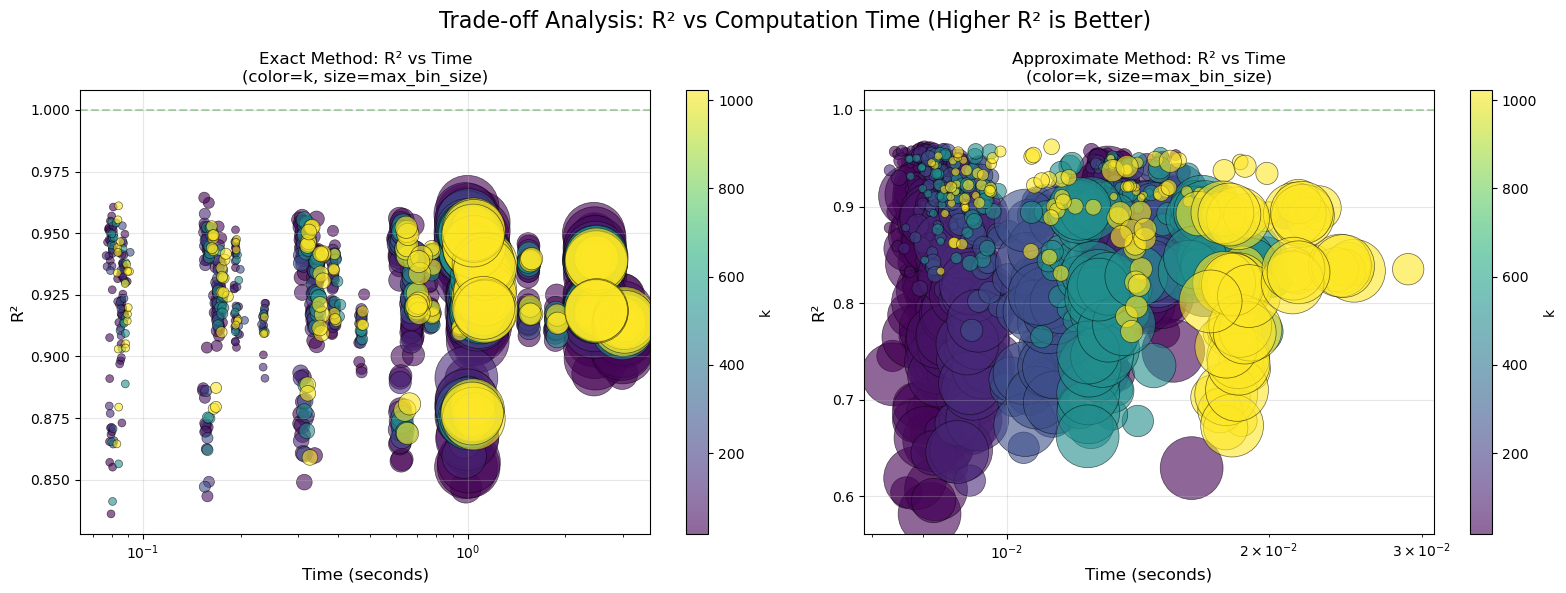

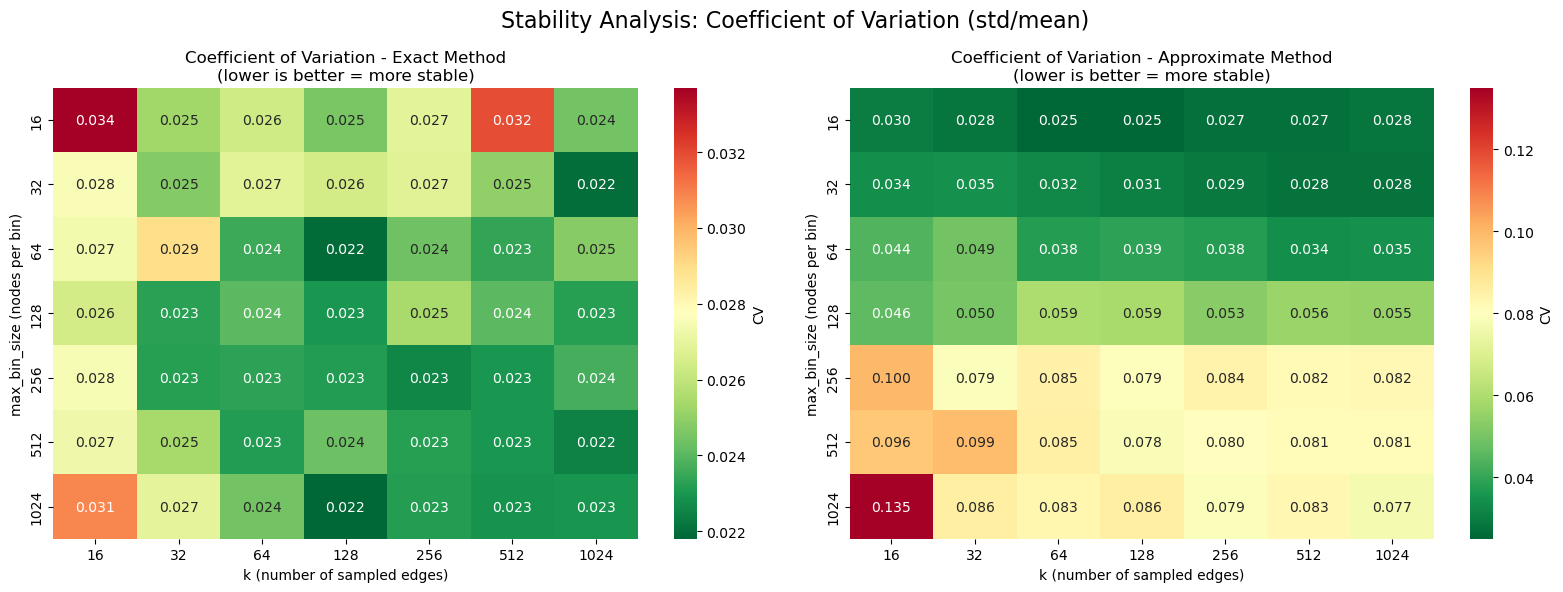

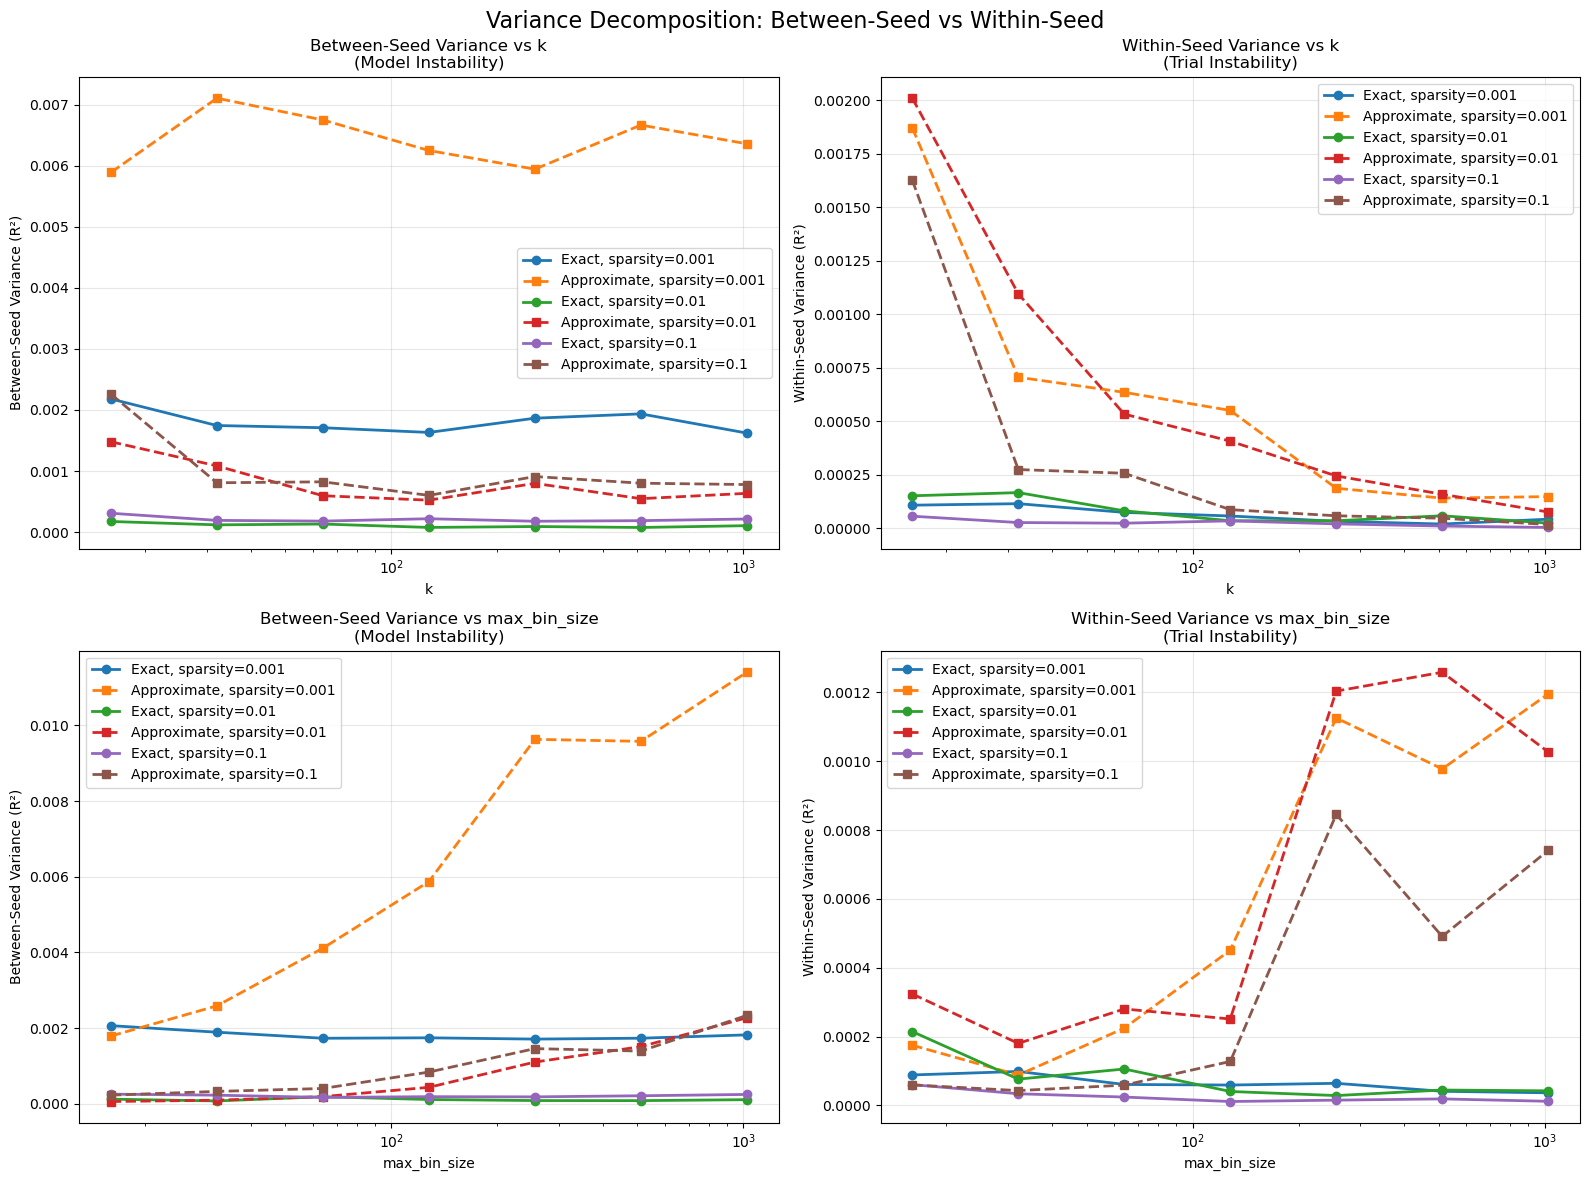


RECOMMENDATIONS

Best parameters for EXACT method (highest mean R²):
  k=64, max_bin_size=256
  Mean R²: 0.926179

Best parameters for APPROXIMATE method (highest mean R²):
  k=64, max_bin_size=16
  Mean R²: 0.924203

Most stable parameters for EXACT method (lowest CV):
  k=128, max_bin_size=1024
  CV: 0.021804

Most stable parameters for APPROXIMATE method (lowest CV):
  k=128, max_bin_size=16
  CV: 0.025043

HYPOTHESIS TESTING

Sparsity = 0.001:
  Exact:       R² correlation with max_bin_size = 0.9286 (p=0.0025)
  Approximate: R² correlation with max_bin_size = -1.0000 (p=0.0000)
  ✓ Hypothesis SUPPORTED: Approximate degrades more with increasing max_bin_size

Sparsity = 0.01:
  Exact:       R² correlation with max_bin_size = 0.8571 (p=0.0137)
  Approximate: R² correlation with max_bin_size = -0.8571 (p=0.0137)
  ✓ Hypothesis SUPPORTED: Approximate degrades more with increasing max_bin_size

Sparsity = 0.1:
  Exact:       R² correlation with max_bin_size = 0.7143 (p=0.0713)
  Approx

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# Get groundtruth for each index
groundtruth_df = df.groupby(['index']).agg({'feature': 'first', 'groundtruth': 'first'}).reset_index()
groundtruth_values = groundtruth_df['groundtruth'].values

# Calculate metrics for each (k, max_bin_size, seed) combination
metrics_data = []

for (k, max_bin_size, seed, sparsity, trial), group in df.groupby(['k', 'max_bin_size', 'seed', 'sparsity', 'trial']):
    # Sort by index to ensure alignment with groundtruth
    group_sorted = group.sort_values('index')

    # Calculate R² (higher is better, 1.0 = perfect fit)
    r2_exact = r2_score(groundtruth_values, group_sorted['explanation_exact'].values)
    r2_approximate = r2_score(groundtruth_values, group_sorted['explanation_approximate'].values)
    
    # Get average time
    time_exact = group_sorted['time_exact'].mean()
    time_approximate = group_sorted['time_approximate'].mean()
    
    # Get AUC (should be same for all rows in group)
    auc = group_sorted['AUC'].iloc[0]
    
    metrics_data.append({
        'k': k,
        'trial': trial,
        'max_bin_size': max_bin_size,
        'sparsity': sparsity,
        'seed': seed,
        'r2_exact': r2_exact,
        'r2_approximate': r2_approximate,
        'time_exact': time_exact,
        'time_approximate': time_approximate,
        'auc': auc
    })

metrics_df = pd.DataFrame(metrics_data)

# Calculate summary statistics grouped by k and max_bin_size
summary_stats = metrics_df.groupby(['k', 'max_bin_size', 'sparsity']).agg({
    'r2_exact': ['mean', 'std', 'min', 'max'],
    'r2_approximate': ['mean', 'std', 'min', 'max'],
    'time_exact': ['mean', 'std'],
    'time_approximate': ['mean', 'std'],
    'auc': 'mean'
}).reset_index()

summary_stats.columns = ['_'.join(col).strip('_') for col in summary_stats.columns.values]

print("="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(summary_stats)

# ============================================================================
# VISUALIZATION 1: R² vs Parameters (with variance shown as error bars)
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for sparsity, subdf in metrics_df.groupby('sparsity'):
    # Group by k, calculate mean and std across max_bin_size and seeds
    r2_by_k = subdf.groupby('k').agg({
        'r2_exact': ['mean', 'std'],
        'r2_approximate': ['mean', 'std']
    })

    k_values = r2_by_k.index.values

    # Plot R² vs k
    ax1.errorbar(k_values, r2_by_k['r2_exact']['mean'], 
                yerr=r2_by_k['r2_exact']['std'], 
                marker='o', capsize=5, capthick=2, label=f'Exact, sparsity={sparsity}', linewidth=2)
    ax1.errorbar(k_values, r2_by_k['r2_approximate']['mean'], 
                yerr=r2_by_k['r2_approximate']['std'], 
                marker='s', capsize=5, capthick=2, label=f'Approximate, sparsity={sparsity}', linewidth=2)
    ax1.set_xlabel('k (number of sampled edges)', fontsize=12)
    ax1.set_ylabel('R² (mean ± std)', fontsize=12)
    ax1.set_title('R² vs k (higher is better)', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xscale('log')
    ax1.axhline(y=1.0, color='green', linestyle='--', alpha=0.3, label='Perfect fit')

    # Group by max_bin_size
    r2_by_binsize = subdf.groupby('max_bin_size').agg({
        'r2_exact': ['mean', 'std'],
        'r2_approximate': ['mean', 'std']
    })

    binsize_values = r2_by_binsize.index.values

    # Plot R² vs max_bin_size
    ax2.errorbar(binsize_values, r2_by_binsize['r2_exact']['mean'], 
                yerr=r2_by_binsize['r2_exact']['std'], 
                marker='o', capsize=5, capthick=2, label=f'Exact, sparsity={sparsity}', linewidth=2)
    ax2.errorbar(binsize_values, r2_by_binsize['r2_approximate']['mean'], 
                yerr=r2_by_binsize['r2_approximate']['std'], 
                marker='s', capsize=5, capthick=2, label=f'Approximate, sparsity={sparsity}', linewidth=2)
    ax2.set_xlabel('max_bin_size (nodes per bin)', fontsize=12)
    ax2.set_ylabel('R² (mean ± std)', fontsize=12)
    ax2.set_title('R² vs max_bin_size (higher is better)', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xscale('log')
    ax2.axhline(y=1.0, color='green', linestyle='--', alpha=0.3, label='Perfect fit')

plt.suptitle('Impact of Parameters on R² (Goodness of Fit to Ground Truth)', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 2: R² Difference (Exact - Approximate)
# ============================================================================
metrics_df['r2_advantage_exact'] = metrics_df['r2_exact'] - metrics_df['r2_approximate']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for sparsity, subdf in metrics_df.groupby('sparsity'):
    # Group by k
    r2_diff_by_k = subdf.groupby('k')['r2_advantage_exact'].agg(['mean', 'std'])
    k_values = r2_diff_by_k.index.values
    
    ax1.errorbar(k_values, r2_diff_by_k['mean'], 
                yerr=r2_diff_by_k['std'], 
                marker='o', capsize=5, capthick=2, label=f'sparsity={sparsity}', linewidth=2)
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax1.fill_between(k_values, 0, r2_diff_by_k['mean'], 
                     where=(r2_diff_by_k['mean'] > 0), alpha=0.2, color='green', 
                     interpolate=True, label='Exact better' if sparsity == metrics_df['sparsity'].iloc[0] else '')
    ax1.fill_between(k_values, 0, r2_diff_by_k['mean'], 
                     where=(r2_diff_by_k['mean'] <= 0), alpha=0.2, color='red', 
                     interpolate=True, label='Approximate better' if sparsity == metrics_df['sparsity'].iloc[0] else '')
    ax1.set_xlabel('k (number of sampled edges)', fontsize=12)
    ax1.set_ylabel('R² Difference (Exact - Approximate)', fontsize=12)
    ax1.set_title('How much better is Exact? (by k)', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xscale('log')

    # Group by max_bin_size
    r2_diff_by_binsize = subdf.groupby('max_bin_size')['r2_advantage_exact'].agg(['mean', 'std'])
    binsize_values = r2_diff_by_binsize.index.values
    
    ax2.errorbar(binsize_values, r2_diff_by_binsize['mean'], 
                yerr=r2_diff_by_binsize['std'], 
                marker='o', capsize=5, capthick=2, label=f'sparsity={sparsity}', linewidth=2)
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.fill_between(binsize_values, 0, r2_diff_by_binsize['mean'], 
                     where=(r2_diff_by_binsize['mean'] > 0), alpha=0.2, color='green', 
                     interpolate=True, label='Exact better' if sparsity == metrics_df['sparsity'].iloc[0] else '')
    ax2.fill_between(binsize_values, 0, r2_diff_by_binsize['mean'], 
                     where=(r2_diff_by_binsize['mean'] <= 0), alpha=0.2, color='red', 
                     interpolate=True, label='Approximate better' if sparsity == metrics_df['sparsity'].iloc[0] else '')
    ax2.set_xlabel('max_bin_size (nodes per bin)', fontsize=12)
    ax2.set_ylabel('R² Difference (Exact - Approximate)', fontsize=12)
    ax2.set_title('How much better is Exact? (by max_bin_size)', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xscale('log')

plt.suptitle('R² Advantage: Positive = Exact Better, Negative = Approximate Better', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 3: Computation Time vs Parameters
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Group by k


# Plot time vs max_bin_size
time_by_k = metrics_df.groupby('k').agg({
    'time_exact': ['mean', 'std'],
    'time_approximate': ['mean', 'std']
})

# Plot time vs k
ax1.errorbar(time_by_k.index, time_by_k['time_exact']['mean'], 
             yerr=time_by_k['time_exact']['std'], 
             marker='o', capsize=5, capthick=2, label='Exact', linewidth=2)
ax1.errorbar(time_by_k.index, time_by_k['time_approximate']['mean'], 
             yerr=time_by_k['time_approximate']['std'], 
             marker='s', capsize=5, capthick=2, label='Approximate', linewidth=2)
ax1.set_xlabel('k (number of sampled edges)', fontsize=12)
ax1.set_ylabel('Time (seconds, mean ± std)', fontsize=12)
ax1.set_title('Computation Time vs k', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')

# Group by max_bin_size
time_by_binsize = metrics_df.groupby('max_bin_size').agg({
    'time_exact': ['mean', 'std'],
    'time_approximate': ['mean', 'std']
})

# Plot time vs max_bin_size
ax2.errorbar(time_by_binsize.index, time_by_binsize['time_exact']['mean'], 
             yerr=time_by_binsize['time_exact']['std'], 
             marker='o', capsize=5, capthick=2, label='Exact', linewidth=2)
ax2.errorbar(time_by_binsize.index, time_by_binsize['time_approximate']['mean'], 
             yerr=time_by_binsize['time_approximate']['std'], 
             marker='s', capsize=5, capthick=2, label='Approximate', linewidth=2)
ax2.set_xlabel('max_bin_size (nodes per bin)', fontsize=12)
ax2.set_ylabel('Time (seconds, mean ± std)', fontsize=12)
ax2.set_title('Computation Time vs max_bin_size', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')
ax2.set_yscale('log')

plt.suptitle('Impact of Parameters on Computation Time', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 4: Variance Analysis (Box plots)
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# R² variance by k
sns.violinplot(data=metrics_df[metrics_df['sparsity']==0.01], x='k', y='r2_exact', ax=axes[0, 0])
axes[0, 0].set_title('R² Exact - Variance by k', fontsize=12)
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('R²')
axes[0, 0].axhline(y=1.0, color='green', linestyle='--', alpha=0.3)
axes[0, 0].grid(True, alpha=0.3, axis='y')

sns.violinplot(data=metrics_df[metrics_df['sparsity']==0.01], x='k', y='r2_approximate', ax=axes[0, 1])
axes[0, 1].set_title('R² Approximate - Variance by k', fontsize=12)
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('R²')
axes[0, 1].axhline(y=1.0, color='green', linestyle='--', alpha=0.3)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# R² variance by max_bin_size
sns.violinplot(data=metrics_df[metrics_df['sparsity']==0.01], x='max_bin_size', y='r2_exact', ax=axes[1, 0])
axes[1, 0].set_title('R² Exact - Variance by max_bin_size', fontsize=12)
axes[1, 0].set_xlabel('max_bin_size')
axes[1, 0].set_ylabel('R²')
axes[1, 0].axhline(y=1.0, color='green', linestyle='--', alpha=0.3)
axes[1, 0].grid(True, alpha=0.3, axis='y')

sns.violinplot(data=metrics_df[metrics_df['sparsity']==0.01], x='max_bin_size', y='r2_approximate', ax=axes[1, 1])
axes[1, 1].set_title('R² Approximate - Variance by max_bin_size', fontsize=12)
axes[1, 1].set_xlabel('max_bin_size')
axes[1, 1].set_ylabel('R²')
axes[1, 1].axhline(y=1.0, color='green', linestyle='--', alpha=0.3)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('R² Variance Analysis (Higher is Better)', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 5: Scatter plots - R² vs Time (trade-off analysis)
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Exact method
scatter1 = ax1.scatter(metrics_df['time_exact'], metrics_df['r2_exact'], 
                       c=metrics_df['k'], s=metrics_df['max_bin_size']*2, 
                       alpha=0.6, cmap='viridis', edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Time (seconds)', fontsize=12)
ax1.set_ylabel('R²', fontsize=12)
ax1.set_title('Exact Method: R² vs Time\n(color=k, size=max_bin_size)', fontsize=12)
ax1.set_xscale('log')
ax1.axhline(y=1.0, color='green', linestyle='--', alpha=0.3)
ax1.grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('k', fontsize=10)

# Approximate method
scatter2 = ax2.scatter(metrics_df['time_approximate'], metrics_df['r2_approximate'], 
                       c=metrics_df['k'], s=metrics_df['max_bin_size']*2, 
                       alpha=0.6, cmap='viridis', edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('R²', fontsize=12)
ax2.set_title('Approximate Method: R² vs Time\n(color=k, size=max_bin_size)', fontsize=12)
ax2.set_xscale('log')
ax2.axhline(y=1.0, color='green', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('k', fontsize=10)

plt.suptitle('Trade-off Analysis: R² vs Computation Time (Higher R² is Better)', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 6: Heatmap of coefficient of variation (CV = std/mean)
# ============================================================================
cv_exact = metrics_df.groupby(['k', 'max_bin_size'])['r2_exact'].agg(['mean', 'std'])
cv_exact['cv'] = cv_exact['std'] / np.abs(cv_exact['mean'])  # abs to avoid division issues
cv_approx = metrics_df.groupby(['k', 'max_bin_size'])['r2_approximate'].agg(['mean', 'std'])
cv_approx['cv'] = cv_approx['std'] / np.abs(cv_approx['mean'])

pivot_cv_exact = cv_exact['cv'].reset_index().pivot(index='max_bin_size', columns='k', values='cv')
pivot_cv_approx = cv_approx['cv'].reset_index().pivot(index='max_bin_size', columns='k', values='cv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pivot_cv_exact, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax1, cbar_kws={'label': 'CV'})
ax1.set_xlabel('k (number of sampled edges)')
ax1.set_ylabel('max_bin_size (nodes per bin)')
ax1.set_title('Coefficient of Variation - Exact Method\n(lower is better = more stable)')

sns.heatmap(pivot_cv_approx, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax2, cbar_kws={'label': 'CV'})
ax2.set_xlabel('k (number of sampled edges)')
ax2.set_ylabel('max_bin_size (nodes per bin)')
ax2.set_title('Coefficient of Variation - Approximate Method\n(lower is better = more stable)')

plt.suptitle('Stability Analysis: Coefficient of Variation (std/mean)', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 7: Variance Decomposition (Between vs Within Seed)
# ============================================================================
variance_analysis = []

for (k, max_bin_size, sparsity), group in metrics_df.groupby(['k', 'max_bin_size', 'sparsity']):
    # Calculate between-seed variance (variance of means across seeds)
    seed_means_exact = group.groupby('seed')['r2_exact'].mean()
    seed_means_approx = group.groupby('seed')['r2_approximate'].mean()
    
    between_seed_var_exact = seed_means_exact.var()
    between_seed_var_approx = seed_means_approx.var()
    
    # Calculate within-seed variance (mean of variances within seeds)
    within_seed_var_exact = group.groupby('seed')['r2_exact'].var().mean()
    within_seed_var_approx = group.groupby('seed')['r2_approximate'].var().mean()
    
    variance_analysis.append({
        'k': k,
        'max_bin_size': max_bin_size,
        'sparsity': sparsity,
        'between_seed_var_exact': between_seed_var_exact,
        'between_seed_var_approx': between_seed_var_approx,
        'within_seed_var_exact': within_seed_var_exact,
        'within_seed_var_approx': within_seed_var_approx,
        'total_var_exact': between_seed_var_exact + within_seed_var_exact,
        'total_var_approx': between_seed_var_approx + within_seed_var_approx,})

var_df = pd.DataFrame(variance_analysis)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for sparsity_val in var_df['sparsity'].unique():
    subdf = var_df[var_df['sparsity'] == sparsity_val]
    
    # Between-seed variance vs k
    k_grouped = subdf.groupby('k')[['between_seed_var_exact', 'between_seed_var_approx']].mean()
    axes[0, 0].plot(k_grouped.index, k_grouped['between_seed_var_exact'], 
                    'o-', label=f'Exact, sparsity={sparsity_val}', linewidth=2)
    axes[0, 0].plot(k_grouped.index, k_grouped['between_seed_var_approx'], 
                    's--', label=f'Approximate, sparsity={sparsity_val}', linewidth=2)
    axes[0, 0].set_xlabel('k')
    axes[0, 0].set_ylabel('Between-Seed Variance (R²)')
    axes[0, 0].set_title('Between-Seed Variance vs k\n(Model Instability)')
    axes[0, 0].set_xscale('log')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Within-seed variance vs k
    axes[0, 1].plot(k_grouped.index, k_grouped.index.map(
        lambda x: subdf[subdf['k']==x]['within_seed_var_exact'].mean()), 
        'o-', label=f'Exact, sparsity={sparsity_val}', linewidth=2)
    axes[0, 1].plot(k_grouped.index, k_grouped.index.map(
        lambda x: subdf[subdf['k']==x]['within_seed_var_approx'].mean()), 
        's--', label=f'Approximate, sparsity={sparsity_val}', linewidth=2)
    axes[0, 1].set_xlabel('k')
    axes[0, 1].set_ylabel('Within-Seed Variance (R²)')
    axes[0, 1].set_title('Within-Seed Variance vs k\n(Trial Instability)')
    axes[0, 1].set_xscale('log')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Between-seed variance vs max_bin_size
    binsize_grouped = subdf.groupby('max_bin_size')[['between_seed_var_exact', 'between_seed_var_approx']].mean()
    axes[1, 0].plot(binsize_grouped.index, binsize_grouped['between_seed_var_exact'], 
                    'o-', label=f'Exact, sparsity={sparsity_val}', linewidth=2)
    axes[1, 0].plot(binsize_grouped.index, binsize_grouped['between_seed_var_approx'], 
                    's--', label=f'Approximate, sparsity={sparsity_val}', linewidth=2)
    axes[1, 0].set_xlabel('max_bin_size')
    axes[1, 0].set_ylabel('Between-Seed Variance (R²)')
    axes[1, 0].set_title('Between-Seed Variance vs max_bin_size\n(Model Instability)')
    axes[1, 0].set_xscale('log')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Within-seed variance vs max_bin_size
    axes[1, 1].plot(binsize_grouped.index, binsize_grouped.index.map(
        lambda x: subdf[subdf['max_bin_size']==x]['within_seed_var_exact'].mean()), 
        'o-', label=f'Exact, sparsity={sparsity_val}', linewidth=2)
    axes[1, 1].plot(binsize_grouped.index, binsize_grouped.index.map(
        lambda x: subdf[subdf['max_bin_size']==x]['within_seed_var_approx'].mean()), 
        's--', label=f'Approximate, sparsity={sparsity_val}', linewidth=2)
    axes[1, 1].set_xlabel('max_bin_size')
    axes[1, 1].set_ylabel('Within-Seed Variance (R²)')
    axes[1, 1].set_title('Within-Seed Variance vs max_bin_size\n(Trial Instability)')
    axes[1, 1].set_xscale('log')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Variance Decomposition: Between-Seed vs Within-Seed', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================================================
# Print recommendations
# ============================================================================
print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)

# Find best parameters for exact method (highest R²)
best_exact = metrics_df.groupby(['k', 'max_bin_size'])['r2_exact'].mean().idxmax()
print(f"\nBest parameters for EXACT method (highest mean R²):")
print(f"  k={best_exact[0]}, max_bin_size={best_exact[1]}")
print(f"  Mean R²: {metrics_df.groupby(['k', 'max_bin_size'])['r2_exact'].mean().max():.6f}")

# Find best parameters for approximate method (highest R²)
best_approx = metrics_df.groupby(['k', 'max_bin_size'])['r2_approximate'].mean().idxmax()
print(f"\nBest parameters for APPROXIMATE method (highest mean R²):")
print(f"  k={best_approx[0]}, max_bin_size={best_approx[1]}")
print(f"  Mean R²: {metrics_df.groupby(['k', 'max_bin_size'])['r2_approximate'].mean().max():.6f}")

# Find most stable parameters (lowest CV)
best_stable_exact = cv_exact['cv'].idxmin()
print(f"\nMost stable parameters for EXACT method (lowest CV):")
print(f"  k={best_stable_exact[0]}, max_bin_size={best_stable_exact[1]}")
print(f"  CV: {cv_exact.loc[best_stable_exact, 'cv']:.6f}")

best_stable_approx = cv_approx['cv'].idxmin()
print(f"\nMost stable parameters for APPROXIMATE method (lowest CV):")
print(f"  k={best_stable_approx[0]}, max_bin_size={best_stable_approx[1]}")
print(f"  CV: {cv_approx.loc[best_stable_approx, 'cv']:.6f}")

# Hypothesis testing
print("\n" + "="*80)
print("HYPOTHESIS TESTING")
print("="*80)

# Test if approximate diverges more with increasing max_bin_size
for sparsity_val in metrics_df['sparsity'].unique():
    subdf = metrics_df[metrics_df['sparsity'] == sparsity_val]
    r2_vs_binsize = subdf.groupby('max_bin_size')[['r2_exact', 'r2_approximate']].mean()
    
    # Calculate correlation between max_bin_size and R² (negative = worse with larger bins)
    from scipy.stats import spearmanr
    corr_exact, p_exact = spearmanr(r2_vs_binsize.index, r2_vs_binsize['r2_exact'])
    corr_approx, p_approx = spearmanr(r2_vs_binsize.index, r2_vs_binsize['r2_approximate'])
    
    print(f"\nSparsity = {sparsity_val}:")
    print(f"  Exact:       R² correlation with max_bin_size = {corr_exact:.4f} (p={p_exact:.4f})")
    print(f"  Approximate: R² correlation with max_bin_size = {corr_approx:.4f} (p={p_approx:.4f})")
    
    if corr_approx < corr_exact:
        print(f"  ✓ Hypothesis SUPPORTED: Approximate degrades more with increasing max_bin_size")
    else:
        print(f"  ✗ Hypothesis NOT supported: Exact degrades more with increasing max_bin_size")

In [ ]:
df = pd.read_csv(
    f"/home/pkaczyns/Code/ALE-and-GNNs/data/synthetic2/ALE_SAGEConv_n_layers2_hidden_size64_sparsity.csv",#SAGEConv
    names=[
        "index",
        "feature",
        "k",
        "max_bin_size",
        "explanation_approximate",
        "time_approximate",
        "explanation_exact",
        "time_exact",
        "groundtruth",
        "AUC",
        "sparsity",
        "seed",
        
    ],
    header=None,
    index_col=None,
)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

# Get groundtruth for each index
groundtruth_df = df.groupby(['index']).agg({'feature': 'first', 'groundtruth': 'first'}).reset_index()
groundtruth_values = groundtruth_df['groundtruth'].values

# Calculate RMSE for each (sparsity, seed) combination
rmse_data = []

for (k, m, sparsity, seed), group in df.groupby(['k', 'max_bin_size', 'sparsity', 'seed']):
    # Sort by index to ensure alignment with groundtruth
    group_sorted = group.sort_values('index')
    
    # Calculate RMSE
    rmse_exact = np.sqrt(mean_squared_error(groundtruth_values, group_sorted['explanation_exact'].values))
    rmse_approximate = np.sqrt(mean_squared_error(groundtruth_values, group_sorted['explanation_approximate'].values))
    
    # Get average time
    time_exact = group_sorted['time_exact'].mean()
    time_approximate = group_sorted['time_approximate'].mean()
    
    # Get other info
    k = group_sorted['k'].iloc[0]
    max_bin_size = group_sorted['max_bin_size'].iloc[0]
    auc = group_sorted['AUC'].iloc[0]
    
    rmse_data.append({
        'sparsity': sparsity,
        'seed': seed,
        'k': k,
        'max_bin_size': max_bin_size,
        'rmse_exact': rmse_exact,
        'rmse_approximate': rmse_approximate,
        'time_exact': time_exact,
        'time_approximate': time_approximate,
        'auc': auc
    })

rmse_df = pd.DataFrame(rmse_data)

# Calculate summary statistics
summary_stats = rmse_df.groupby('sparsity').agg({
    'rmse_exact': ['mean', 'std', 'min', 'max'],
    'rmse_approximate': ['mean', 'std', 'min', 'max'],
    'time_exact': ['mean', 'std'],
    'time_approximate': ['mean', 'std'],
    'auc': 'mean'
})

print("="*80)
print("SUMMARY STATISTICS BY SPARSITY")
print("="*80)
print(summary_stats)

# ============================================================================
# VISUALIZATION 1: RMSE vs Sparsity (Main Plot)
# ============================================================================
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

sparsity_values = sorted(rmse_df['sparsity'].unique())
rmse_by_sparsity = rmse_df.groupby('sparsity').agg({
    'rmse_exact': ['mean', 'std'],
    'rmse_approximate': ['mean', 'std']
})

# Plot with error bars
ax.errorbar(sparsity_values, 
            rmse_by_sparsity['rmse_exact']['mean'], 
            yerr=rmse_by_sparsity['rmse_exact']['std'], 
            marker='o', capsize=5, capthick=2, label='Exact', 
            linewidth=2.5, markersize=8)

ax.errorbar(sparsity_values, 
            rmse_by_sparsity['rmse_approximate']['mean'], 
            yerr=rmse_by_sparsity['rmse_approximate']['std'], 
            marker='s', capsize=5, capthick=2, label='Approximate', 
            linewidth=2.5, markersize=8)

ax.set_xlabel('Graph Sparsity (edge probability)', fontsize=14)
ax.set_ylabel('RMSE (mean ± std)', fontsize=14)
ax.set_title(f'Impact of Graph Sparsity on ALE Accuracy\n(k={rmse_df["k"].iloc[0]}, max_bin_size={rmse_df["max_bin_size"].iloc[0]})', 
             fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 2: Individual trials with sparsity
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot all individual points
for sparsity in sparsity_values:
    sparsity_data = rmse_df[rmse_df['sparsity'] == sparsity]
    ax1.scatter([sparsity] * len(sparsity_data), sparsity_data['rmse_exact'], 
                alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
    ax2.scatter([sparsity] * len(sparsity_data), sparsity_data['rmse_approximate'], 
                alpha=0.6, s=100, edgecolors='black', linewidth=0.5)

# Add mean lines
ax1.plot(sparsity_values, rmse_by_sparsity['rmse_exact']['mean'], 
         'r-', linewidth=3, label='Mean', zorder=10)
ax2.plot(sparsity_values, rmse_by_sparsity['rmse_approximate']['mean'], 
         'r-', linewidth=3, label='Mean', zorder=10)

ax1.set_xlabel('Sparsity', fontsize=12)
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_title('Exact Method - Individual Trials', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Sparsity', fontsize=12)
ax2.set_ylabel('RMSE', fontsize=12)
ax2.set_title('Approximate Method - Individual Trials', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('RMSE Distribution Across Sparsity Levels', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 3: Difference between methods vs sparsity
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Calculate absolute difference
rmse_df['rmse_diff'] = np.abs(rmse_df['rmse_exact'] - rmse_df['rmse_approximate'])
rmse_df['rmse_ratio'] = rmse_df['rmse_approximate'] / rmse_df['rmse_exact']

diff_by_sparsity = rmse_df.groupby('sparsity').agg({
    'rmse_diff': ['mean', 'std'],
    'rmse_ratio': ['mean', 'std']
})

# Plot absolute difference
ax1.errorbar(sparsity_values, 
             diff_by_sparsity['rmse_diff']['mean'], 
             yerr=diff_by_sparsity['rmse_diff']['std'], 
             marker='o', capsize=5, capthick=2, 
             linewidth=2.5, markersize=8, color='purple')
ax1.set_xlabel('Sparsity', fontsize=12)
ax1.set_ylabel('|RMSE_exact - RMSE_approx| (mean ± std)', fontsize=12)
ax1.set_title('Absolute Difference Between Methods', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# Plot ratio
ax2.errorbar(sparsity_values, 
             diff_by_sparsity['rmse_ratio']['mean'], 
             yerr=diff_by_sparsity['rmse_ratio']['std'], 
             marker='s', capsize=5, capthick=2, 
             linewidth=2.5, markersize=8, color='orange')
ax2.set_xlabel('Sparsity', fontsize=12)
ax2.set_ylabel('RMSE_approx / RMSE_exact (mean ± std)', fontsize=12)
ax2.set_title('Ratio Between Methods', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.axhline(1, color='black', linestyle='--', linewidth=1, label='Equal performance')
ax2.legend()

plt.suptitle('Difference Between Exact and Approximate Methods vs Sparsity', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 4: Box plots by sparsity
# ============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

sns.boxplot(data=rmse_df, x='sparsity', y='rmse_exact', ax=ax1, color='skyblue')
ax1.set_xlabel('Sparsity', fontsize=12)
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_title('RMSE Distribution - Exact Method', fontsize=14)
ax1.grid(True, alpha=0.3, axis='y')

sns.boxplot(data=rmse_df, x='sparsity', y='rmse_approximate', ax=ax2, color='lightcoral')
ax2.set_xlabel('Sparsity', fontsize=12)
ax2.set_ylabel('RMSE', fontsize=12)
ax2.set_title('RMSE Distribution - Approximate Method', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('RMSE Variance Across Sparsity Levels', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 5: Computation time vs sparsity
# ============================================================================
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

time_by_sparsity = rmse_df.groupby('sparsity').agg({
    'time_exact': ['mean', 'std'],
    'time_approximate': ['mean', 'std']
})

ax.errorbar(sparsity_values, 
            time_by_sparsity['time_exact']['mean'], 
            yerr=time_by_sparsity['time_exact']['std'], 
            marker='o', capsize=5, capthick=2, label='Exact', 
            linewidth=2.5, markersize=8)

ax.errorbar(sparsity_values, 
            time_by_sparsity['time_approximate']['mean'], 
            yerr=time_by_sparsity['time_approximate']['std'], 
            marker='s', capsize=5, capthick=2, label='Approximate', 
            linewidth=2.5, markersize=8)

ax.set_xlabel('Graph Sparsity', fontsize=14)
ax.set_ylabel('Computation Time (seconds, mean ± std)', fontsize=14)
ax.set_title('Impact of Sparsity on Computation Time', fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# Print statistical analysis
# ============================================================================
print("\n" + "="*80)
print("STATISTICAL ANALYSIS")
print("="*80)

# Find sparsity with biggest difference
max_diff_sparsity = diff_by_sparsity['rmse_diff']['mean'].idxmax()
print(f"\nSparsity with largest difference between methods: {max_diff_sparsity}")
print(f"  Mean difference: {diff_by_sparsity.loc[max_diff_sparsity, ('rmse_diff', 'mean')]:.6f}")

# Correlation between sparsity and difference
from scipy.stats import pearsonr, spearmanr
corr_pearson, p_pearson = pearsonr(rmse_df['sparsity'], rmse_df['rmse_diff'])
corr_spearman, p_spearman = spearmanr(rmse_df['sparsity'], rmse_df['rmse_diff'])

print(f"\nCorrelation between sparsity and method difference:")
print(f"  Pearson:  r={corr_pearson:.4f}, p={p_pearson:.4f}")
print(f"  Spearman: ρ={corr_spearman:.4f}, p={p_spearman:.4f}")

if p_pearson < 0.05:
    trend = "increases" if corr_pearson > 0 else "decreases"
    print(f"  → Significant correlation: difference {trend} with sparsity")
else:
    print(f"  → No significant correlation detected")

# Best and worst performing sparsity
print(f"\nBest sparsity for Exact method: {rmse_by_sparsity['rmse_exact']['mean'].idxmin()} "
      f"(RMSE={rmse_by_sparsity['rmse_exact']['mean'].min():.6f})")
print(f"Best sparsity for Approximate method: {rmse_by_sparsity['rmse_approximate']['mean'].idxmin()} "
      f"(RMSE={rmse_by_sparsity['rmse_approximate']['mean'].min():.6f})")

ValueError: Found input variables with inconsistent numbers of samples: [5, 15]

In [40]:
print("Exact", (df['explanation_exact']-df['groundtruth']).apply(np.abs).mean(), (df['explanation_approximate']-df['groundtruth']).apply(np.abs).mean())

Exact 0.12563091228749196 0.12538976937149748


In [34]:
print("Exact", (df['explanation_exact']-df['groundtruth']).apply(np.abs).mean(), (df['explanation_approximate']-df['groundtruth']).apply(np.abs).mean())

Exact 0.02360041799806546 0.02388561392030764


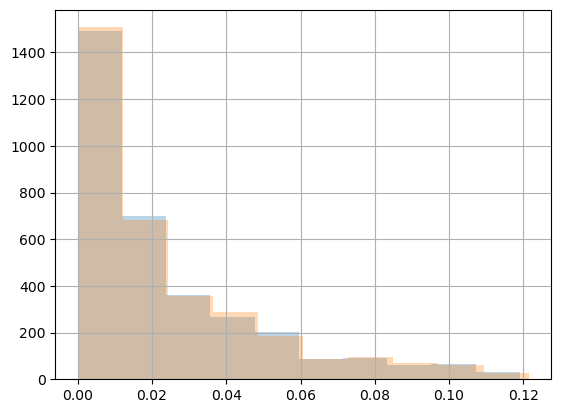

In [42]:
(df['explanation_exact']-df['groundtruth']).abs().hist(alpha=0.3)
(df['explanation_approximate']-df['groundtruth']).abs().hist(alpha=0.3)
plt.show()

/tmp/ipykernel_3816038/959901362.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


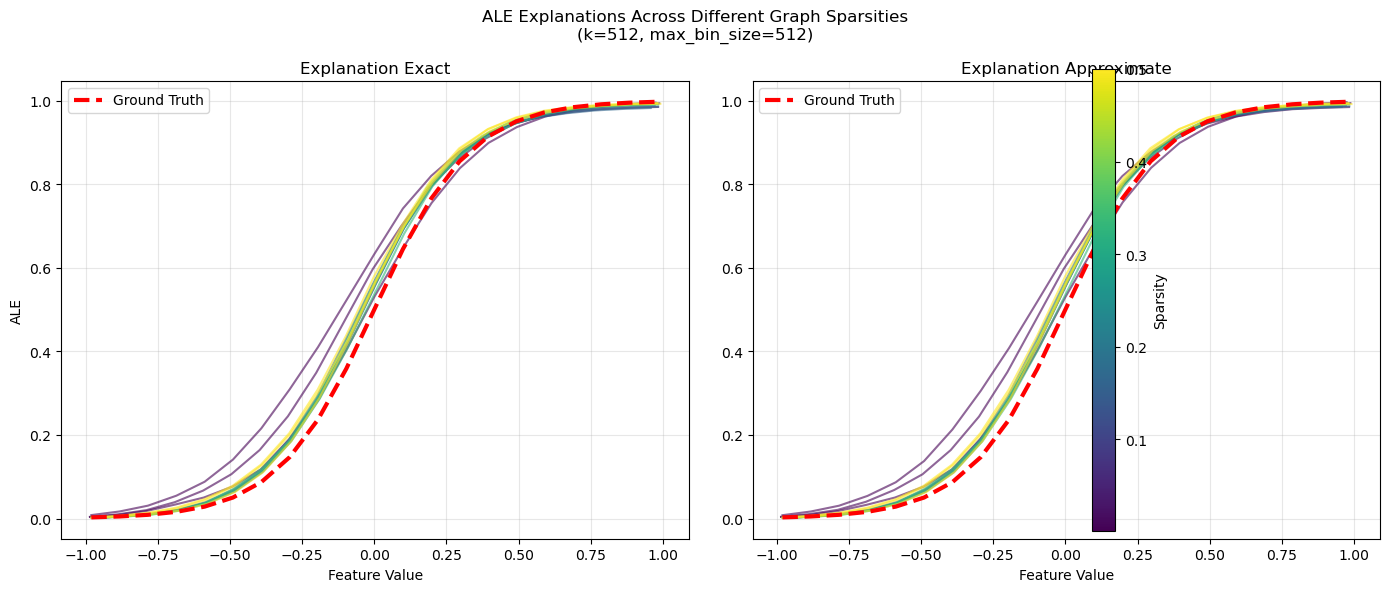


LINEARITY ANALYSIS BY SPARSITY

Percentage of EXACT explanations with R² > 0.95: 0.00%
Percentage of APPROXIMATE explanations with R² > 0.95: 0.00%

Mean R² for EXACT: 0.9328
Mean R² for APPROXIMATE: 0.9329

--------------------------------------------------------------------------------
Linear behavior by sparsity:
--------------------------------------------------------------------------------
          Mean R² Exact  Std R² Exact  % Linear Exact  Mean R² Approx  \
sparsity                                                                
0.001          0.941475      0.001690             0.0        0.941482   
0.010          0.929473      0.001101             0.0        0.929487   
0.100          0.931101      0.000443             0.0        0.931177   
0.500          0.929255      0.002410             0.0        0.929270   

          Std R² Approx  % Linear Approx  
sparsity                                  
0.001          0.001768              0.0  
0.010          0.001098         

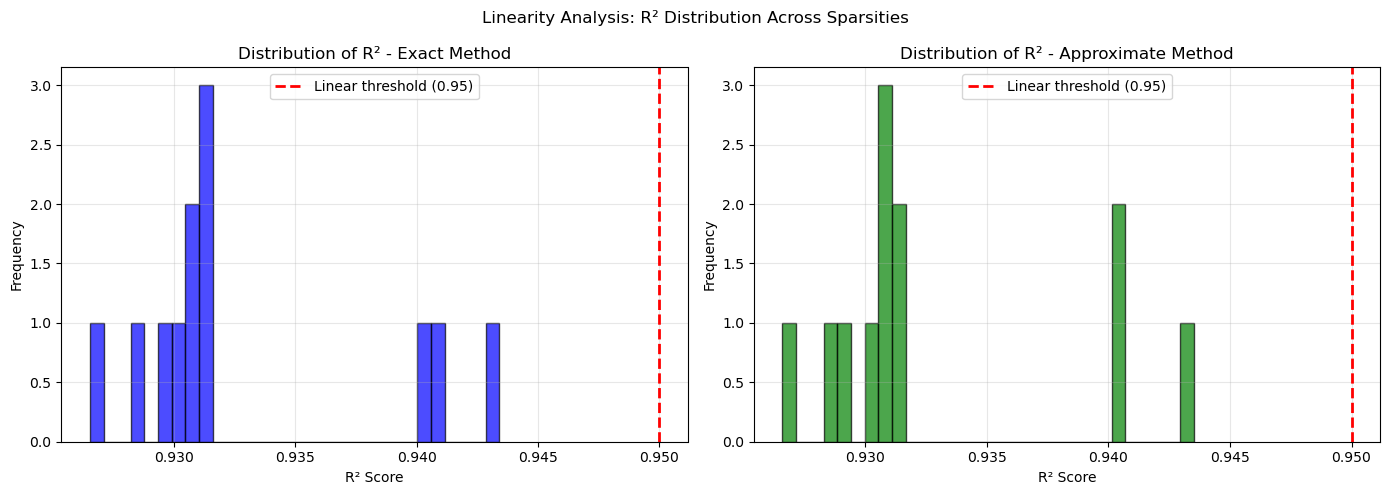

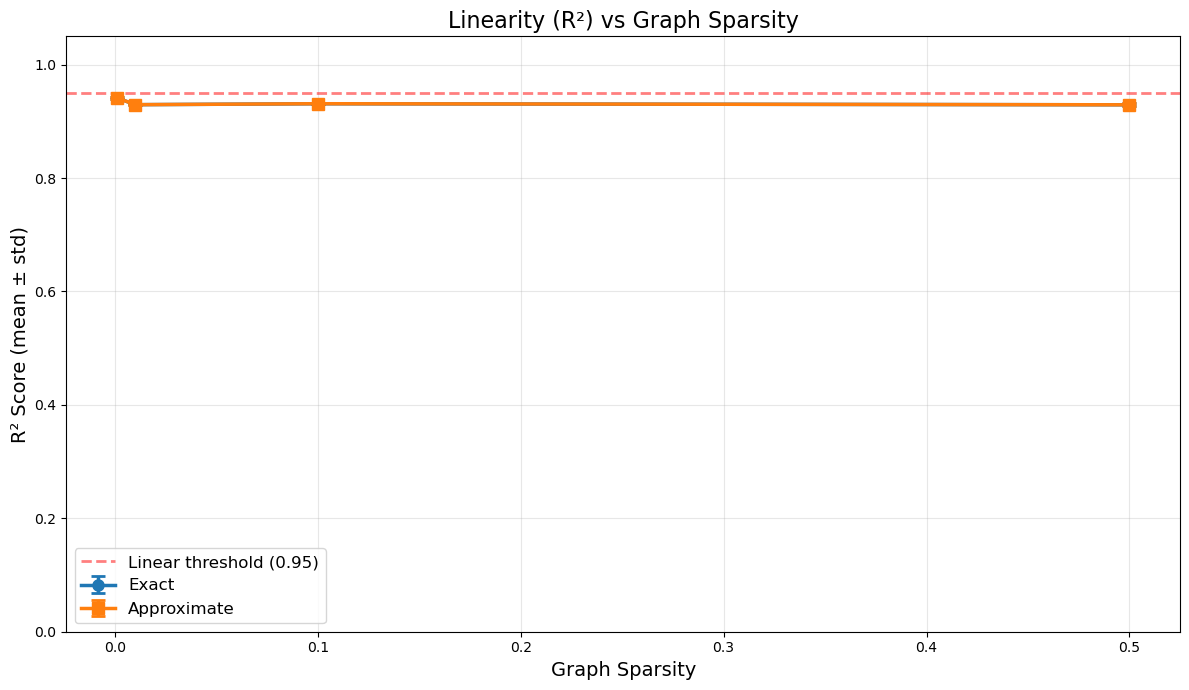

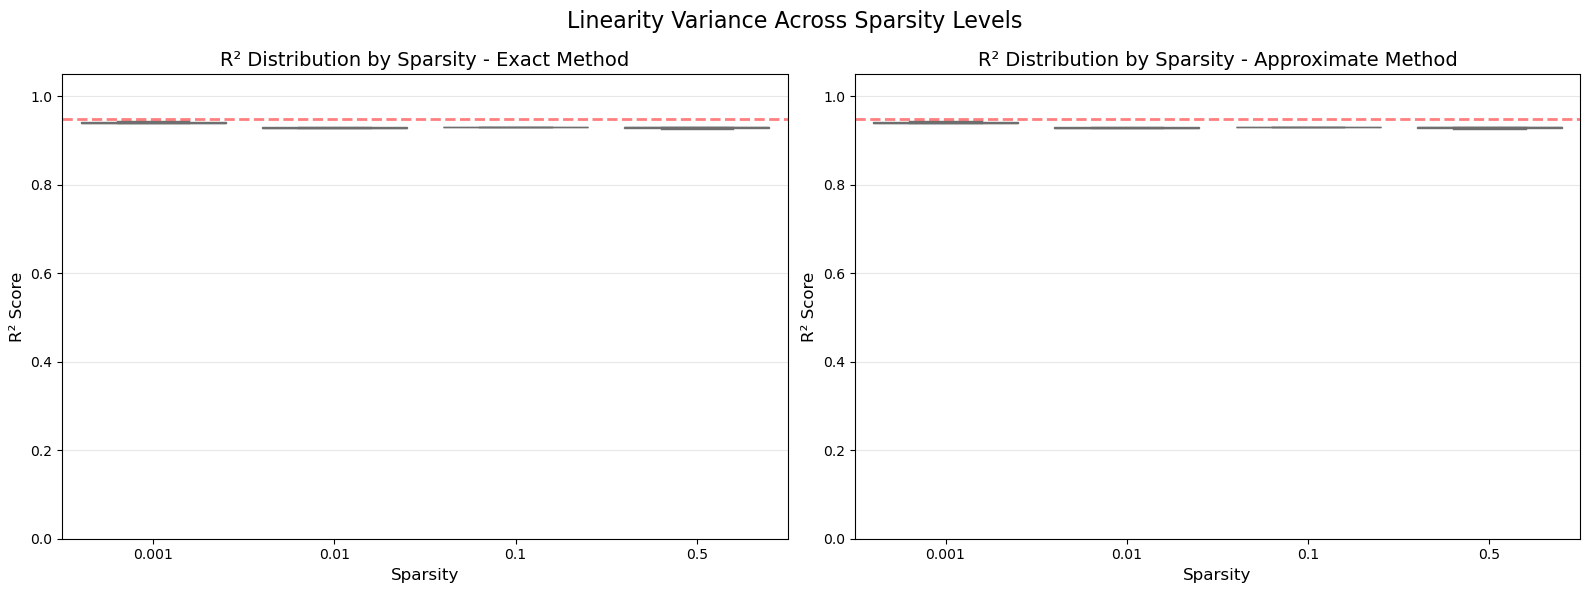

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
import pandas as pd

# First, let's ensure data is sorted by feature value within each group
df_sorted = df.sort_values(['sparsity', 'seed', 'feature'])

# Replot with sorted data
groundtruth_df = df_sorted.groupby(['index']).agg({'feature': 'first', 'groundtruth': 'first'}).reset_index()

# Calculate weighted averages with sorted data (no weighting needed if all have same k and max_bin_size)
gt_exact = df_sorted.groupby(['index'])['explanation_exact'].mean()
gt_approximate = df_sorted.groupby(['index'])['explanation_approximate'].mean()

# Create subplots with sorted data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Get unique sparsity values and create color map
sparsity_values = sorted(df_sorted['sparsity'].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(sparsity_values)))
sparsity_to_color = dict(zip(sparsity_values, colors))

for (sparsity, seed), group in df_sorted.groupby(["sparsity", "seed"]):
    # Sort by feature value within group
    group = group.sort_values('feature')
    
    color = sparsity_to_color[sparsity]
    
    ax1.plot(
        group['feature'],
        group['explanation_exact'],
        color=color,
        alpha=0.6,
        linewidth=1.5,
    )
    
    ax2.plot(
        group['feature'],
        group['explanation_approximate'],
        color=color,
        alpha=0.6,
        linewidth=1.5,
    )

ax2.sharey(ax1)

# Plot ground truth
ax1.plot(groundtruth_df['feature'], groundtruth_df['groundtruth'], 
         color='red', linewidth=3, label='Ground Truth', zorder=10, linestyle='--')
ax2.plot(groundtruth_df['feature'], groundtruth_df['groundtruth'], 
         color='red', linewidth=3, label='Ground Truth', zorder=10, linestyle='--')

# Add colorbar legend for sparsity
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, 
                           norm=plt.Normalize(vmin=min(sparsity_values), 
                                             vmax=max(sparsity_values)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=[ax1, ax2], label='Sparsity', pad=0.02)

ax1.set_title('Explanation Exact')
ax2.set_title('Explanation Approximate')
ax1.set_xlabel('Feature Value')
ax2.set_xlabel('Feature Value')
ax1.set_ylabel('ALE')
ax1.legend()
ax2.legend()
ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'ALE Explanations Across Different Graph Sparsities\n(k={df_sorted["k"].iloc[0]}, max_bin_size={df_sorted["max_bin_size"].iloc[0]})')
plt.tight_layout()
plt.show()

# Now analyze linearity
print("\n" + "="*80)
print("LINEARITY ANALYSIS BY SPARSITY")
print("="*80)

linearity_data = []

for (sparsity, seed), group in df_sorted.groupby(["sparsity", "seed"]):
    group = group.sort_values('feature')
    
    # Calculate correlation coefficient (R^2) with linear fit for exact
    x = group['feature'].values
    y_exact = group['explanation_exact'].values
    y_approx = group['explanation_approximate'].values
    
    # Fit linear model and calculate R^2
    from sklearn.linear_model import LinearRegression
    lr = LinearRegression()
    
    # Exact
    lr.fit(x.reshape(-1, 1), y_exact)
    r2_exact = lr.score(x.reshape(-1, 1), y_exact)
    
    # Approximate
    lr.fit(x.reshape(-1, 1), y_approx)
    r2_approx = lr.score(x.reshape(-1, 1), y_approx)
    
    linearity_data.append({
        'sparsity': sparsity,
        'seed': seed,
        'r2_exact': r2_exact,
        'r2_approx': r2_approx
    })

linearity_df = pd.DataFrame(linearity_data)

# Define threshold for "linear" behavior (R^2 > 0.95 is very linear)
linear_threshold = 0.95

# Calculate percentages
pct_linear_exact = (linearity_df['r2_exact'] > linear_threshold).sum() / len(linearity_df) * 100
pct_linear_approx = (linearity_df['r2_approx'] > linear_threshold).sum() / len(linearity_df) * 100

print(f"\nPercentage of EXACT explanations with R² > {linear_threshold}: {pct_linear_exact:.2f}%")
print(f"Percentage of APPROXIMATE explanations with R² > {linear_threshold}: {pct_linear_approx:.2f}%")

print(f"\nMean R² for EXACT: {linearity_df['r2_exact'].mean():.4f}")
print(f"Mean R² for APPROXIMATE: {linearity_df['r2_approx'].mean():.4f}")

# Show which sparsity values produce linear behavior
print("\n" + "-"*80)
print("Linear behavior by sparsity:")
print("-"*80)

linear_by_sparsity = linearity_df.groupby('sparsity').agg({
    'r2_exact': ['mean', 'std', lambda x: (x > linear_threshold).sum() / len(x) * 100],
    'r2_approx': ['mean', 'std', lambda x: (x > linear_threshold).sum() / len(x) * 100]
})
linear_by_sparsity.columns = ['Mean R² Exact', 'Std R² Exact', '% Linear Exact', 
                               'Mean R² Approx', 'Std R² Approx', '% Linear Approx']
print(linear_by_sparsity)

# Show most linear cases
print("\n" + "-"*80)
print("Most linear cases (Top 10 by R² Exact):")
print("-"*80)
print(linearity_df.nlargest(10, 'r2_exact')[['sparsity', 'seed', 'r2_exact', 'r2_approx']])

# Show least linear cases
print("\n" + "-"*80)
print("Least linear cases (Bottom 10 by R² Exact):")
print("-"*80)
print(linearity_df.nsmallest(10, 'r2_exact')[['sparsity', 'seed', 'r2_exact', 'r2_approx']])

# Plot histogram of R² values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(linearity_df['r2_exact'], bins=30, alpha=0.7, color='blue', edgecolor='black')
ax1.axvline(linear_threshold, color='red', linestyle='--', linewidth=2, label=f'Linear threshold ({linear_threshold})')
ax1.set_xlabel('R² Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of R² - Exact Method')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.hist(linearity_df['r2_approx'], bins=30, alpha=0.7, color='green', edgecolor='black')
ax2.axvline(linear_threshold, color='red', linestyle='--', linewidth=2, label=f'Linear threshold ({linear_threshold})')
ax2.set_xlabel('R² Score')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of R² - Approximate Method')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Linearity Analysis: R² Distribution Across Sparsities')
plt.tight_layout()
plt.show()

# Plot R² vs Sparsity
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

r2_by_sparsity = linearity_df.groupby('sparsity').agg({
    'r2_exact': ['mean', 'std'],
    'r2_approx': ['mean', 'std']
})

ax.errorbar(sparsity_values, 
            r2_by_sparsity['r2_exact']['mean'], 
            yerr=r2_by_sparsity['r2_exact']['std'], 
            marker='o', capsize=5, capthick=2, label='Exact', 
            linewidth=2.5, markersize=8)

ax.errorbar(sparsity_values, 
            r2_by_sparsity['r2_approx']['mean'], 
            yerr=r2_by_sparsity['r2_approx']['std'], 
            marker='s', capsize=5, capthick=2, label='Approximate', 
            linewidth=2.5, markersize=8)

ax.axhline(linear_threshold, color='red', linestyle='--', linewidth=2, 
           label=f'Linear threshold ({linear_threshold})', alpha=0.5)

ax.set_xlabel('Graph Sparsity', fontsize=14)
ax.set_ylabel('R² Score (mean ± std)', fontsize=14)
ax.set_title('Linearity (R²) vs Graph Sparsity', fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

# Box plot of R² by sparsity
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

import seaborn as sns
sns.boxplot(data=linearity_df, x='sparsity', y='r2_exact', ax=ax1, color='skyblue')
ax1.axhline(linear_threshold, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax1.set_xlabel('Sparsity', fontsize=12)
ax1.set_ylabel('R² Score', fontsize=12)
ax1.set_title('R² Distribution by Sparsity - Exact Method', fontsize=14)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim([0, 1.05])

sns.boxplot(data=linearity_df, x='sparsity', y='r2_approx', ax=ax2, color='lightcoral')
ax2.axhline(linear_threshold, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax2.set_xlabel('Sparsity', fontsize=12)
ax2.set_ylabel('R² Score', fontsize=12)
ax2.set_title('R² Distribution by Sparsity - Approximate Method', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim([0, 1.05])

plt.suptitle('Linearity Variance Across Sparsity Levels', fontsize=16)
plt.tight_layout()
plt.show()

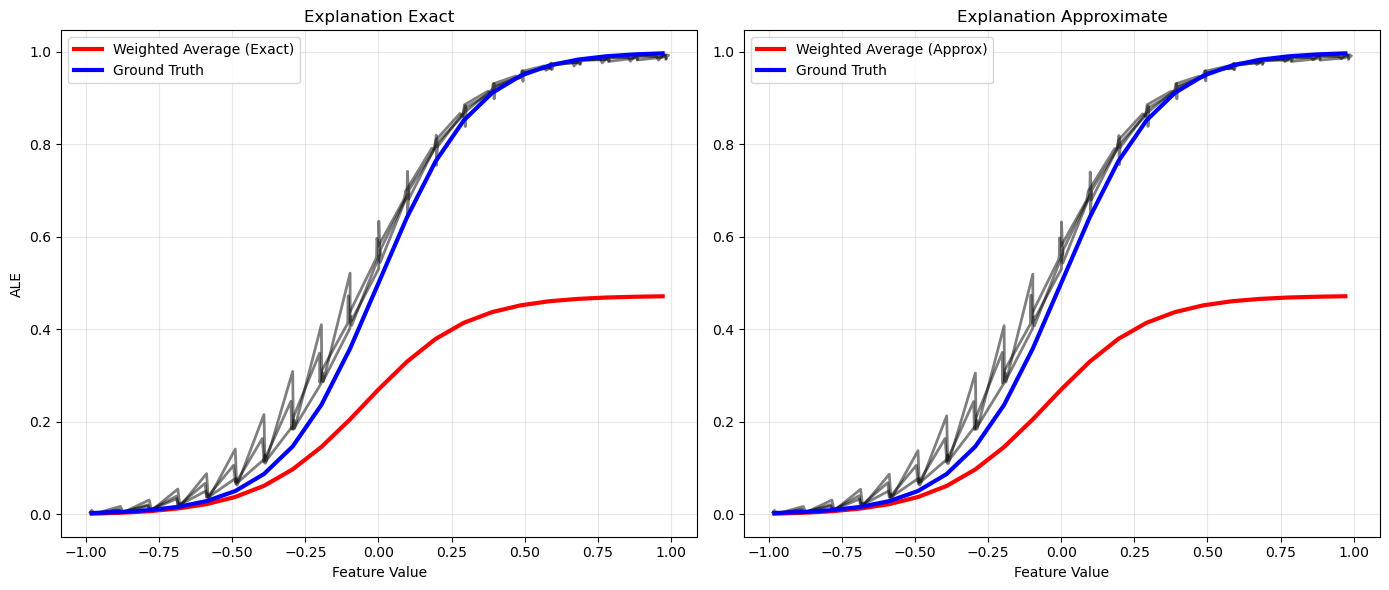


LINEARITY ANALYSIS

Percentage of EXACT explanations with R² > 0.95: 0.00%
Percentage of APPROXIMATE explanations with R² > 0.95: 0.00%

Mean R² for EXACT: 0.9317
Mean R² for APPROXIMATE: 0.9317

--------------------------------------------------------------------------------
Linear behavior by (k, max_bin_size):
--------------------------------------------------------------------------------
                  Mean R² Exact  % Linear Exact  Mean R² Approx  \
k   max_bin_size                                                  
512 512                 0.93168             0.0        0.931743   

                  % Linear Approx  
k   max_bin_size                   
512 512                       0.0  

--------------------------------------------------------------------------------
Most linear cases (Top 10 by R² Exact):
--------------------------------------------------------------------------------
     k  max_bin_size  seed  r2_exact  r2_approx
1  512           512     1  0.933243   0.9

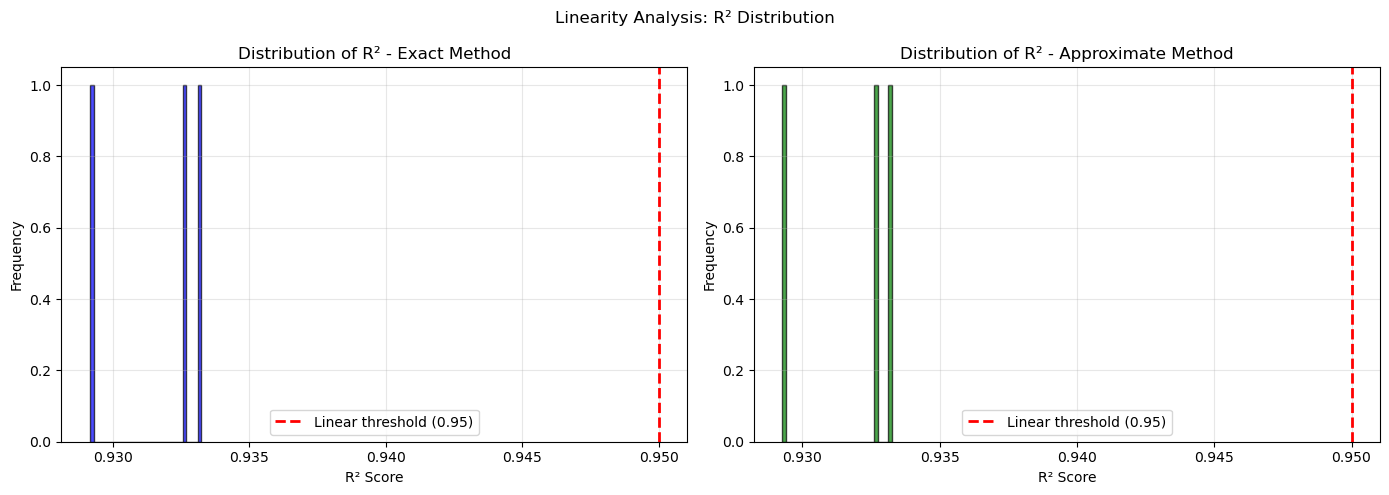

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# First, let's ensure data is sorted by feature value within each group
df_sorted = df.sort_values(['k', 'max_bin_size', 'seed', 'feature'])

# Replot with sorted data
groundtruth_df = df_sorted.groupby(['index']).agg({'feature': 'first', 'groundtruth': 'first'}).reset_index()

# Calculate weighted averages with sorted data
n = 10
mod = df_sorted.apply(lambda x: x['k'] * x['max_bin_size'], axis=1).sum() / n
df_sorted['mean_exact'] = df_sorted.apply(lambda x: x['explanation_exact'] * x['max_bin_size'] * x['k'] / mod, axis=1)
df_sorted['mean_approximate'] = df_sorted.apply(lambda x: x['explanation_approximate'] * x['max_bin_size'] * x['k'] / mod, axis=1)

gt_exact = df_sorted.groupby(['index'])['mean_exact'].sum()
gt_approximate = df_sorted.groupby(['index'])['mean_approximate'].sum()

# Create subplots with sorted data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for (k, max_bin_size, seed), group in df_sorted.groupby(["k", "max_bin_size", "seed"]):
    color_intensity = k + max_bin_size
    
    # Sort by feature value within group
    group = group.sort_values('feature')
    
    ax1.plot(
        group['feature'],
        group['explanation_exact'],
        color=(0, 0, 0, color_intensity / 2048),
        linewidth=2,
    )
    
    ax2.plot(
        group['feature'],
        group['explanation_approximate'],
        color=(0, 0, 0, color_intensity / 2048),
        linewidth=2,
    )

ax2.sharey(ax1)

ax1.plot(groundtruth_df['feature'], gt_exact.values, color='red', linewidth=3, label='Weighted Average (Exact)', zorder=10)
ax2.plot(groundtruth_df['feature'], gt_approximate.values, color='red', linewidth=3, label='Weighted Average (Approx)', zorder=10)

ax1.plot(groundtruth_df['feature'], groundtruth_df['groundtruth'], color='blue', linewidth=3, label='Ground Truth', zorder=10)
ax2.plot(groundtruth_df['feature'], groundtruth_df['groundtruth'], color='blue', linewidth=3, label='Ground Truth', zorder=10)

ax1.set_title('Explanation Exact')
ax2.set_title('Explanation Approximate')
ax1.set_xlabel('Feature Value')
ax2.set_xlabel('Feature Value')
ax1.set_ylabel('ALE')
ax1.legend()
ax2.legend()
ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)

#plt.suptitle(f'{dataset} dataset, {model} model - SORTED')
plt.tight_layout()
plt.show()

# Now analyze linearity
print("\n" + "="*80)
print("LINEARITY ANALYSIS")
print("="*80)

linearity_data = []

for (k, max_bin_size, seed), group in df_sorted.groupby(["k", "max_bin_size", "seed"]):
    group = group.sort_values('feature')
    
    # Calculate correlation coefficient (R^2) with linear fit for exact
    x = group['feature'].values
    y_exact = group['explanation_exact'].values
    y_approx = group['explanation_approximate'].values
    
    # Fit linear model and calculate R^2
    from sklearn.linear_model import LinearRegression
    lr = LinearRegression()
    
    # Exact
    lr.fit(x.reshape(-1, 1), y_exact)
    r2_exact = lr.score(x.reshape(-1, 1), y_exact)
    
    # Approximate
    lr.fit(x.reshape(-1, 1), y_approx)
    r2_approx = lr.score(x.reshape(-1, 1), y_approx)
    
    linearity_data.append({
        'k': k,
        'max_bin_size': max_bin_size,
        'seed': seed,
        'r2_exact': r2_exact,
        'r2_approx': r2_approx
    })

linearity_df = pd.DataFrame(linearity_data)

# Define threshold for "linear" behavior (R^2 > 0.95 is very linear)
linear_threshold = 0.95

# Calculate percentages
pct_linear_exact = (linearity_df['r2_exact'] > linear_threshold).sum() / len(linearity_df) * 100
pct_linear_approx = (linearity_df['r2_approx'] > linear_threshold).sum() / len(linearity_df) * 100

print(f"\nPercentage of EXACT explanations with R² > {linear_threshold}: {pct_linear_exact:.2f}%")
print(f"Percentage of APPROXIMATE explanations with R² > {linear_threshold}: {pct_linear_approx:.2f}%")

print(f"\nMean R² for EXACT: {linearity_df['r2_exact'].mean():.4f}")
print(f"Mean R² for APPROXIMATE: {linearity_df['r2_approx'].mean():.4f}")

# Show which (k, max_bin_size) combinations produce linear behavior
print("\n" + "-"*80)
print("Linear behavior by (k, max_bin_size):")
print("-"*80)

linear_by_params = linearity_df.groupby(['k', 'max_bin_size']).agg({
    'r2_exact': ['mean', lambda x: (x > linear_threshold).sum() / len(x) * 100],
    'r2_approx': ['mean', lambda x: (x > linear_threshold).sum() / len(x) * 100]
})
linear_by_params.columns = ['Mean R² Exact', '% Linear Exact', 'Mean R² Approx', '% Linear Approx']
print(linear_by_params)

# Show most linear cases
print("\n" + "-"*80)
print("Most linear cases (Top 10 by R² Exact):")
print("-"*80)
print(linearity_df.nlargest(10, 'r2_exact')[['k', 'max_bin_size', 'seed', 'r2_exact', 'r2_approx']])

# Show least linear cases
print("\n" + "-"*80)
print("Least linear cases (Bottom 10 by R² Exact):")
print("-"*80)
print(linearity_df.nsmallest(10, 'r2_exact')[['k', 'max_bin_size', 'seed', 'r2_exact', 'r2_approx']])

# Plot histogram of R² values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(linearity_df['r2_exact'], bins=30, alpha=0.7, color='blue', edgecolor='black')
ax1.axvline(linear_threshold, color='red', linestyle='--', linewidth=2, label=f'Linear threshold ({linear_threshold})')
ax1.set_xlabel('R² Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of R² - Exact Method')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.hist(linearity_df['r2_approx'], bins=30, alpha=0.7, color='green', edgecolor='black')
ax2.axvline(linear_threshold, color='red', linestyle='--', linewidth=2, label=f'Linear threshold ({linear_threshold})')
ax2.set_xlabel('R² Score')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of R² - Approximate Method')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Linearity Analysis: R² Distribution')
plt.tight_layout()
plt.show()

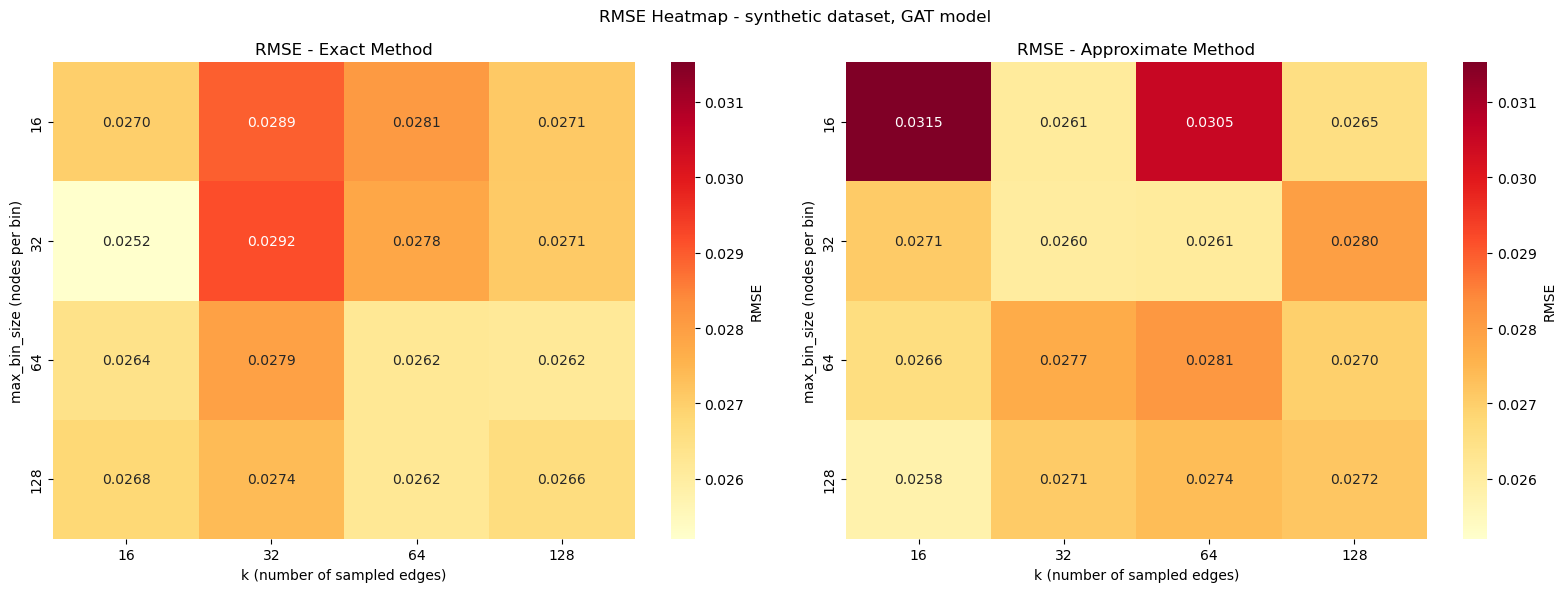


RMSE Summary - Exact Method:
k                  16        32        64        128
max_bin_size                                        
16            0.027004  0.028943  0.028082  0.027107
32            0.025205  0.029157  0.027813  0.027084
64            0.026419  0.027929  0.026210  0.026150
128           0.026790  0.027394  0.026196  0.026621

RMSE Summary - Approximate Method:
k                  16        32        64        128
max_bin_size                                        
16            0.031525  0.026088  0.030514  0.026547
32            0.027062  0.026040  0.026092  0.027990
64            0.026610  0.027709  0.028133  0.026979
128           0.025783  0.027062  0.027362  0.027173

Color scale range: [0.0252, 0.0315]


In [27]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_squared_error

# Get groundtruth for each index
groundtruth_df = df.groupby(['index']).agg({'feature': 'first', 'groundtruth': 'first'}).reset_index()
groundtruth_values = groundtruth_df['groundtruth'].values

# Calculate RMSE for each (k, max_bin_size, seed) combination
rmse_data = []

for (k, max_bin_size, seed), group in df.groupby(['k', 'max_bin_size', 'seed']):
    # Sort by index to ensure alignment with groundtruth
    group_sorted = group.sort_values('index')
    
    # Calculate RMSE for exact
    rmse_exact = np.sqrt(mean_squared_error(groundtruth_values, group_sorted['explanation_exact'].values))
    
    # Calculate RMSE for approximate
    rmse_approximate = np.sqrt(mean_squared_error(groundtruth_values, group_sorted['explanation_approximate'].values))
    
    rmse_data.append({
        'k': k,
        'max_bin_size': max_bin_size,
        'seed': seed,
        'rmse_exact': rmse_exact,
        'rmse_approximate': rmse_approximate
    })

rmse_df = pd.DataFrame(rmse_data)

# Average RMSE across seeds for each (k, max_bin_size) combination
rmse_summary = rmse_df.groupby(['k', 'max_bin_size']).agg({
    'rmse_exact': 'mean',
    'rmse_approximate': 'mean'
}).reset_index()

# Create pivot tables for heatmap
pivot_exact = rmse_summary.pivot(index='max_bin_size', columns='k', values='rmse_exact')
pivot_approximate = rmse_summary.pivot(index='max_bin_size', columns='k', values='rmse_approximate')

# Calculate global min and max for consistent color scale
vmin = min(pivot_exact.min().min(), pivot_approximate.min().min())
vmax = max(pivot_exact.max().max(), pivot_approximate.max().max())

# Create heatmaps using seaborn
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap for exact
sns.heatmap(pivot_exact, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax1, 
            cbar_kws={'label': 'RMSE'}, vmin=vmin, vmax=vmax)
ax1.set_xlabel('k (number of sampled edges)')
ax1.set_ylabel('max_bin_size (nodes per bin)')
ax1.set_title('RMSE - Exact Method')

# Heatmap for approximate
sns.heatmap(pivot_approximate, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax2, 
            cbar_kws={'label': 'RMSE'}, vmin=vmin, vmax=vmax)
ax2.set_xlabel('k (number of sampled edges)')
ax2.set_ylabel('max_bin_size (nodes per bin)')
ax2.set_title('RMSE - Approximate Method')

plt.suptitle(f'RMSE Heatmap - {dataset} dataset, {model} model')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nRMSE Summary - Exact Method:")
print(pivot_exact)
print("\nRMSE Summary - Approximate Method:")
print(pivot_approximate)
print(f"\nColor scale range: [{vmin:.4f}, {vmax:.4f}]")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate weighted averages
n = 10  # number of bins
mod = df.apply(lambda x: x['k'] * x['max_bin_size'], axis=1).sum() / n

df['mean_exact'] = df.apply(lambda x: x['explanation_exact'] * x['max_bin_size'] * x['k'] / mod, axis=1)
df['mean_approximate'] = df.apply(lambda x: x['explanation_approximate'] * x['max_bin_size'] * x['k'] / mod, axis=1)

# Aggregate by index
gt_exact = df.groupby(['index'])['mean_exact'].sum()
gt_approximate = df.groupby(['index'])['mean_approximate'].sum()

# Also get the groundtruth values (assuming they're the same across trials)
groundtruth_values = df.groupby(['index'])['groundtruth'].first()

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot individual trials with varying opacity based on k and max_bin_size
for (k, max_bin_size), group in df.groupby(["k", "max_bin_size"]):
    color_intensity = k + max_bin_size
    print(f"color_intensity={color_intensity}, k={k}, max_bin_size={max_bin_size}")
    
    # Plot exact
    ax1.plot(
        group['ifeat'],
        group['explanation_exact'],
        label=f"k={k}, max_bin_size={max_bin_size}",
        color=(0, 0, 0, color_intensity / 2048),
        linewidth=2,
    )
    
    # Plot approximate
    ax2.plot(
        group['ifeat'],
        group['explanation_approximate'],
        label=f"k={k}, max_bin_size={max_bin_size}",
        color=(0, 0, 0, color_intensity / 2048),
        linewidth=2,
    )

# Share y-axis
ax2.sharey(ax1)

# Plot weighted average (red line)
ax1.plot(
    gt_exact.index,
    gt_exact.values,
    color='red',
    linewidth=3,
    label='Weighted Average (Exact)',
    zorder=10
)
ax2.plot(
    gt_approximate.index,
    gt_approximate.values,
    color='red',
    linewidth=3,
    label='Weighted Average (Approx)',
    zorder=10
)

# Plot ground truth (blue line)
ax1.plot(
    groundtruth_values.index,
    groundtruth_values.values,
    color='blue',
    linewidth=3,
    label='Ground Truth',
    zorder=10
)
ax2.plot(
    groundtruth_values.index,
    groundtruth_values.values,
    color='blue',
    linewidth=3,
    label='Ground Truth',
    zorder=10
)

# Add labels and titles
ax1.set_title('Explanation Exact')
ax2.set_title('Explanation Approximate')
ax1.set_xlabel('Feature Value (ifeat)')
ax2.set_xlabel('Feature Value (ifeat)')
ax1.set_ylabel('ALE')
ax1.legend()
ax2.legend()
ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'ALE Analysis')
plt.tight_layout()
plt.show()

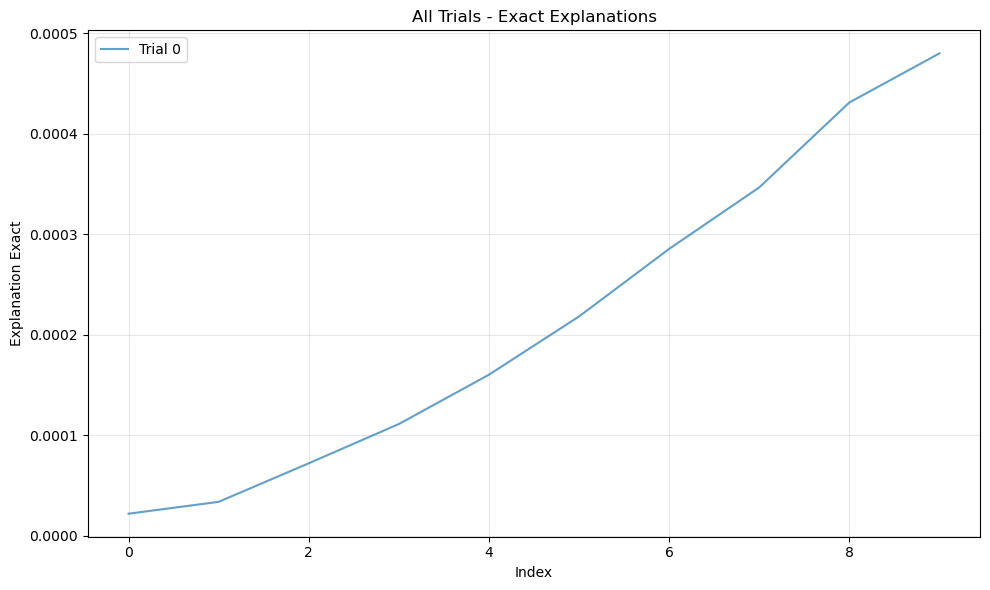

In [35]:

fig, ax = plt.subplots(figsize=(10, 6))

for trial, group in df.groupby('trial'):
    ax.plot(group['index'], group['explanation_exact'], label=f'Trial {trial}', alpha=0.7)

ax.set_xlabel('Index')
ax.set_ylabel('Explanation Exact')
ax.set_title('All Trials - Exact Explanations')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

trial
0    Axes(0.125,0.11;0.775x0.77)
dtype: object

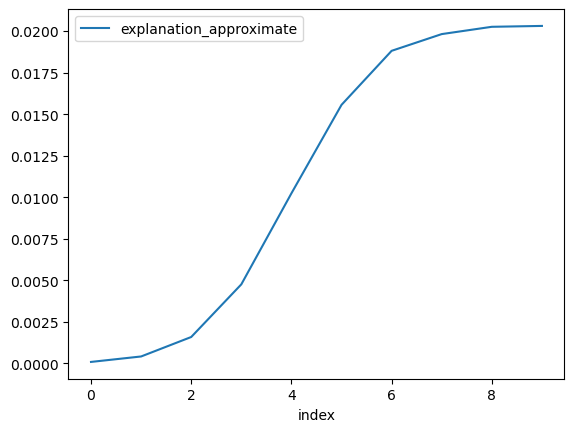

In [36]:
df.groupby(['trial']).plot(x='index', y='explanation_approximate')

2048 1024 1024


ValueError: x and y must have same first dimension, but have shapes (5,) and (10,)

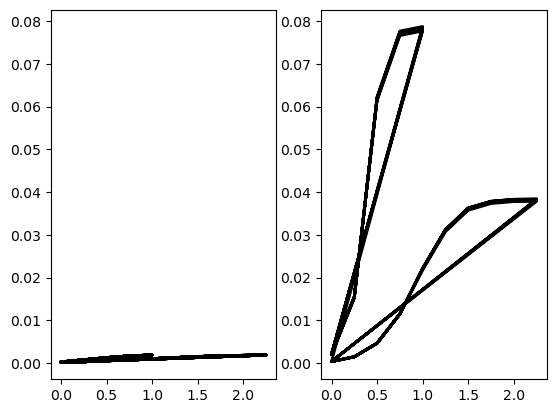

In [15]:
import matplotlib.pyplot as plt
n=10
mod = df.apply(lambda x: x['k']*x['max_bin_size'], axis=1).sum()/n
df['mean_exact'] = df.apply(lambda x: x['explanation_exact']*x['max_bin_size']*x['k']/mod,axis=1)
gt = df.groupby(['index'])['mean_exact'].sum()
#gt = df.groupby(['index']).mean()['explanation_exact']
df['mean_approximate'] = df.apply(lambda x: x['explanation_approximate']*x['max_bin_size']*x['k']/mod,axis=1)
ap = df.groupby(['index'])['mean_approximate'].sum()#['explanation_approximate']
#print(np.vstack(df['explanation_exact'].apply(lambda x: np.array(x))).mean(axis=0))
#gt = df.loc[:, 'explanation_exact'].mean()

# df1024['trial'] = df1024.reset_index()['level_0'].apply(lambda x: math.floor(float(x)/5))
fig, (ax1, ax2) = plt.subplots(1, 2)
for (k, max_bin_size), group in (
    df.groupby(["k", "max_bin_size"])
):
    color_intensity = k + max_bin_size
    print(color_intensity, k, max_bin_size)
    ax1.plot(
        group.reset_index()["index"].apply(lambda x: x / 4),
        group["explanation_exact"],
        label=f"k={k}, max_bin_size={max_bin_size}",
        color=(0, 0, 0, color_intensity / 2048),
        linewidth=2,
    )

    ax2.sharey(ax1)
    ax2.plot(
        group.reset_index()["index"].apply(lambda x: x / 4),
        group["explanation_approximate"],
        label=f"k={k}, max_bin_size={max_bin_size}",
        color=(0, 0, 0, color_intensity / 2048),
        linewidth=2,
    )

ax1.plot(
    [0, 0.25, 0.5, 0.75, 1],
    gt,
    color='red',
    linewidth=2,
)
ax2.plot(
    [0, 0.25, 0.5, 0.75, 1],
    gt,
    color='red',
    linewidth=2,
)
ax1.plot(
    [0, 0.25, 0.5, 0.75, 1],
    ap,
    color='blue',
    linewidth=2,
)
ax2.plot(
    [0, 0.25, 0.5, 0.75, 1],
    ap,
    color='blue',
    linewidth=2,
)

# Add labels and legend
ax1.set_title('Explanation Exact')
ax2.set_title('Explanation Approximate')
ax1.set_xlabel('Explained variable: z')
ax2.set_xlabel('Explained variable: z')
#TODO: Change to appropriate x-axis labelm dependent on the datset (in args)
ax1.set_ylabel('ALE')# TODO" change to method
#ax.set_yscale('log')
plt.suptitle(f'{dataset} dataset, {model} model')
# Show plot
plt.show()
#plt.savefig(f"C:/Users/ppaul/Documents/influence_on_ideas/figures/CD1-E_no2/ALE_{model}_n_layers2_hidden_size256.png")#, format='eps')

When I measure distance of exact computations from "gold standard", there is a clear dependence on max bin size for citations and almost none for k.




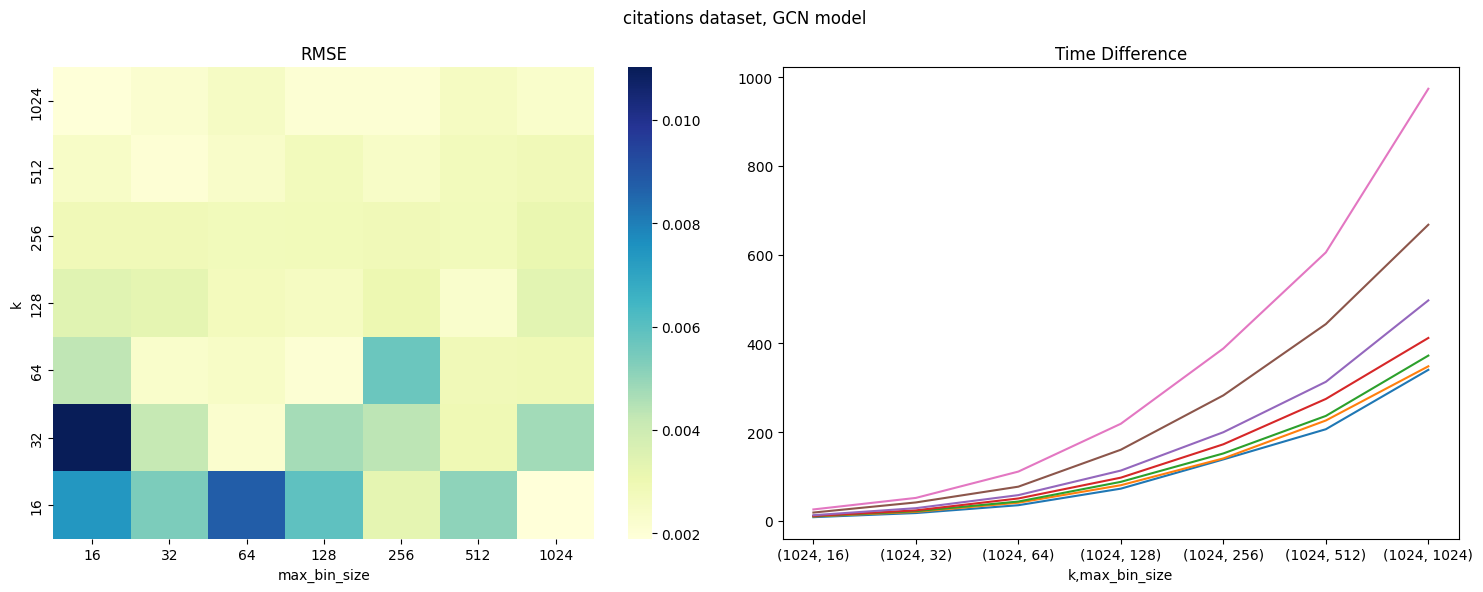

In [69]:
import numpy as np
def root_mean_squared_error(x,y):
    return np.sqrt(np.mean((np.array(x)-np.array(y))**2))
def R_squared(x,y):
    x = np.array(x)
    y = np.array(y)
    return 1 - np.sum((x-y)**2)/np.sum((x-np.mean(x))**2)
def plot_goldstandard(path, dataset, model):
    ALE = pd.read_csv(path, names=['i', 'k', 'max_bin_size',  'explanation_approximate', 'time_approximate', 'explanation_exact', 'time_exact'], header=None, index_col=0).iloc[:245]
    mod = df.apply(lambda x: x['k']*x['max_bin_size'], axis=1).sum()/5
    goldstandard = ALE.apply(lambda x: x['explanation_exact']*x['max_bin_size']*x['k']/mod,axis=1).reset_index().groupby('i').sum()
    aggregated = ALE.groupby(['k','max_bin_size']).agg({'explanation_exact':list, 'time_exact':lambda x: list(x)[0],'explanation_approximate':list, 'time_approximate':lambda x: list(x)[0]})
    
    aggregated['wasserstein_distance'] = aggregated.apply(lambda row: root_mean_squared_error(goldstandard, row['explanation_approximate']),axis=1)
    aggregated['time_diff'] = aggregated['time_exact']-aggregated['time_approximate']
    results = aggregated.groupby(['k','max_bin_size']).agg({'wasserstein_distance':'mean', 'time_diff':'mean'})

    # Assuming 'results' is already defined and contains the necessary data
    # First heatmap for Wasserstein distance
    wasserstein_data = results['wasserstein_distance'].reset_index().pivot_table(values='wasserstein_distance', index='k', columns='max_bin_size')

    # Second heatmap for Time difference
    #time_data = results['time_diff'].reset_index().pivot_table(values='time_diff', index='k', columns='max_bin_size')

    # Create a figure with two subplots side by side
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # First heatmap
    sns.heatmap(wasserstein_data, annot=False, cmap='YlGnBu', ax=axes[0])
    axes[0].set_title('RMSE')
    axes[0].invert_yaxis()
    # Second heatmap
    #sns.heatmap(time_data, annot=False, cmap='YlGnBu', ax=axes[1])
    for k, group in results['time_diff'].groupby('k'):
        group.plot(kind='line', x='max_bin_size', y='time_diff', ax=axes[1])
    axes[1].set_title('Time Difference')
    #axes[1].set_yscale('log')
    fig.suptitle(f'{dataset} dataset, {model} model')
    # Adjust layout to prevent overlap
    plt.tight_layout()


    # Show the plot
    plt.show()

dataset="citations"
model="GCN"
plot_goldstandard(paths[f"{dataset} dataset, ALE method, {model} model"], dataset, model)

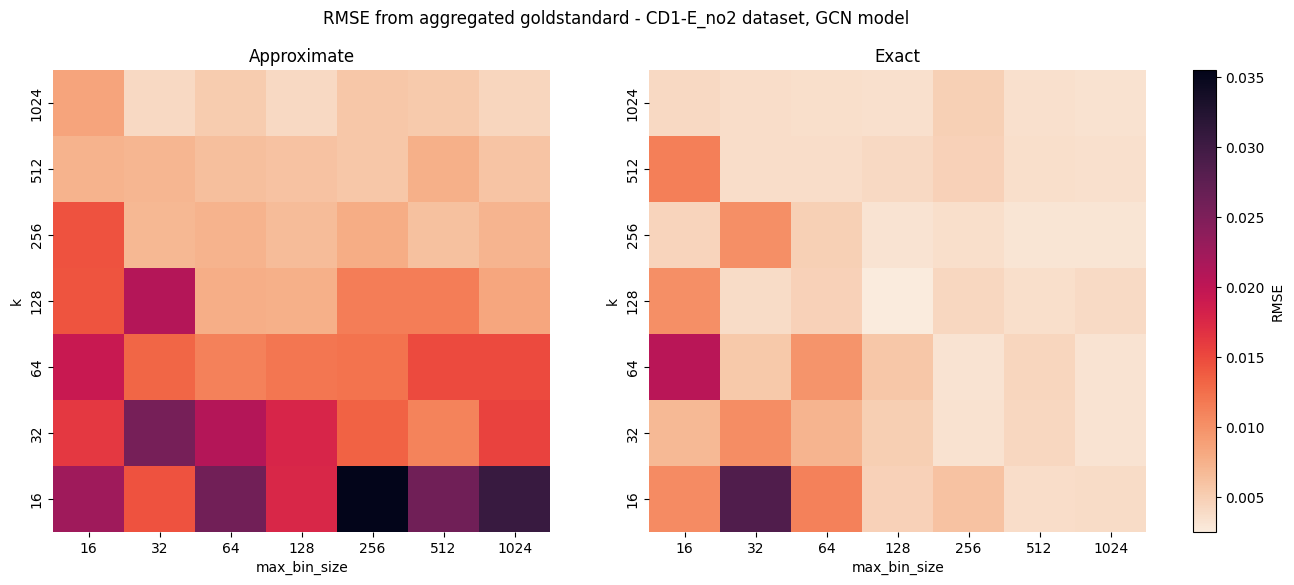

In [256]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def root_mean_squared_error(x, y):
    return np.sqrt(np.mean((np.array(x) - np.array(y))**2))

def R_squared(x, y):
    x = np.array(x)
    y = np.array(y)
    return 1 - np.sum((x - y)**2) / np.sum((x - np.mean(x))**2)

def plot_goldstandard(path, dataset, model):
    ALE = pd.read_csv(path, 
                      #names=['i', 'k', 'max_bin_size', 'explanation_approximate', 'time_approximate', 'explanation_exact', 'time_exact'], 
                      #header=None, 
                      index_col=None).rename({"index":"i"}, axis=1)
    ALE['trial'] = [np.floor(i/5) for i in ALE.index]
    mod = ALE.apply(lambda x: x['k'] * x['max_bin_size'], axis=1).sum() / 5
    goldstandard = ALE.set_index('i').apply(lambda x: x['explanation_exact'] * x['max_bin_size'] * x['k'] / mod, axis=1).reset_index().groupby('i').sum()
    aggregated = ALE.groupby(['trial', 'k', 'max_bin_size']).agg({
        'explanation_exact': list,
        'time_exact': lambda x: list(x)[0],
        'explanation_approximate': list,
        'time_approximate': lambda x: list(x)[0]
    })
  
    aggregated['distance_approximate'] = aggregated.apply(lambda row: root_mean_squared_error(goldstandard, row['explanation_approximate']), axis=1)
    aggregated['distance_exact'] = aggregated.apply(lambda row: root_mean_squared_error(goldstandard, row['explanation_exact']), axis=1)
  
    results = aggregated.groupby(['k', 'max_bin_size']).agg({'distance_approximate': 'mean', 'distance_exact': 'mean'})
    approximate_data = results['distance_approximate'].reset_index().pivot_table(values='distance_approximate', index='k', columns='max_bin_size')
    exact_data = results['distance_exact'].reset_index().pivot_table(values='distance_exact', index='k', columns='max_bin_size')
  
    # Heatmap with common colormap, colorbar, and logarithmic scale
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Find common vmin and vmax, avoiding zero or negative values for log scale
    vmin = min(approximate_data[approximate_data > 0].min().min(), exact_data[exact_data > 0].min().min())
    vmax = max(approximate_data.max().max(), exact_data.max().max())
    
    # Define the colormap
    cmap = 'rocket_r'
    
    # Apply logarithmic normalization
    #norm = Norm(vmin=vmin, vmax=vmax)
    vmin = min(approximate_data.min().min(), exact_data.min().min())
    vmax = max(approximate_data.max().max(), exact_data.max().max())
    # Plot heatmaps with common logarithmic color range
    sns.heatmap(approximate_data, annot=False, cmap=cmap, vmin=vmin, vmax=vmax, ax=axes[0], cbar=False)
    axes[0].set_title('Approximate')
    axes[0].invert_yaxis()

    sns.heatmap(exact_data, annot=False, cmap=cmap, vmin=vmin, vmax=vmax, ax=axes[1], cbar=False)
    axes[1].set_title('Exact')
    axes[1].invert_yaxis()
    
    # Create a single colorbar for both heatmaps
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
    cbar.set_label('RMSE')
    
    plt.suptitle(f'RMSE from aggregated goldstandard - {dataset} dataset, {model} model')
    plt.savefig(f"C:/Users/ppaul/Documents/influence_on_ideas/figures/{dataset}/ALE_{model}_heatmap.eps", format='eps')
    plt.show()
# Example usage
dataset = "CD1-E_no2"
model = "GCN"
# plot_goldstandard('path_to_your_data.csv', dataset, "GCN")


plot_goldstandard(paths[f"{dataset} dataset, ALE method, {model} model"], dataset, model)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def root_mean_squared_error(x, y):
    return np.sqrt(np.mean((np.array(x) - np.array(y))**2))

def R_squared(x, y):
    x = np.array(x)
    y = np.array(y)
    return 1 - np.sum((x - y)**2) / np.sum((x - np.mean(x))**2)

def plot_goldstandard(path, dataset, model):
    ALE = pd.read_csv(path, 
                      names=['i', 'k', 'max_bin_size', 'explanation_approximate', 'time_approximate', 'explanation_exact', 'time_exact'], 
                      header=None, index_col=None)
    ALE['trial'] = [np.floor(i/5) for i in ALE.index]
    mod = ALE.apply(lambda x: x['k'] * x['max_bin_size'], axis=1).sum() / 5
    goldstandard = ALE.set_index('i').apply(lambda x: x['explanation_exact'] * x['max_bin_size'] * x['k'] / mod, axis=1).reset_index().groupby('i').sum()
    aggregated = ALE.groupby(['trial', 'k', 'max_bin_size']).agg({
        'explanation_exact': list,
        'time_exact': lambda x: list(x)[0],
        'explanation_approximate': list,
        'time_approximate': lambda x: list(x)[0]
    })
  
    aggregated['distance_approximate'] = aggregated.apply(lambda row: root_mean_squared_error(goldstandard, row['explanation_approximate']), axis=1)
    aggregated['distance_exact'] = aggregated.apply(lambda row: root_mean_squared_error(goldstandard, row['explanation_exact']), axis=1)
  
    results = aggregated.groupby(['k', 'max_bin_size']).agg({'distance_approximate': 'mean', 'distance_exact': 'mean'})
    approximate_data = results['distance_approximate'].reset_index().pivot_table(values='distance_approximate', index='k', columns='max_bin_size')
    exact_data = results['distance_exact'].reset_index().pivot_table(values='distance_exact', index='k', columns='max_bin_size')
  
    # Heatmap with common colormap, colorbar, and logarithmic scale
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Find common vmin and vmax, avoiding zero or negative values for log scale
    vmin = min(approximate_data[approximate_data > 0].min().min(), exact_data[exact_data > 0].min().min())
    vmax = max(approximate_data.max().max(), exact_data.max().max())
    
    # Define the colormap
    cmap = 'rocket_r'
    
    # Apply logarithmic normalization
    norm = LogNorm(vmin=vmin, vmax=vmax)
    
    # Plot heatmaps with common logarithmic color range
    sns.heatmap(approximate_data, annot=False, cmap=cmap, norm=norm, ax=axes[0], cbar=False)
    axes[0].set_title('Approximate')
    axes[0].invert_yaxis()

    sns.heatmap(exact_data, annot=False, cmap=cmap, norm=norm, ax=axes[1], cbar=False)
    axes[1].set_title('Exact')
    axes[1].invert_yaxis()
    
    # Create a single colorbar for both heatmaps
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
    cbar.set_label('RMSE')
    
    plt.suptitle(f'RMSE from aggregated goldstandard - {dataset} dataset, {model} model')
    plt.savefig(f"C:/Users/ppaul/Documents/influence_on_ideas/figures/{dataset}/ALE_{model}_heatmap.eps", format='eps')
    plt.show()

# Example usage
dataset = "CD1-E_no2"
model = "GCN"
# plot_goldstandard('path_to_your_data.csv', dataset, "GCN")


plot_goldstandard(paths[f"{dataset} dataset, ALE method, {model} model"], dataset, model)

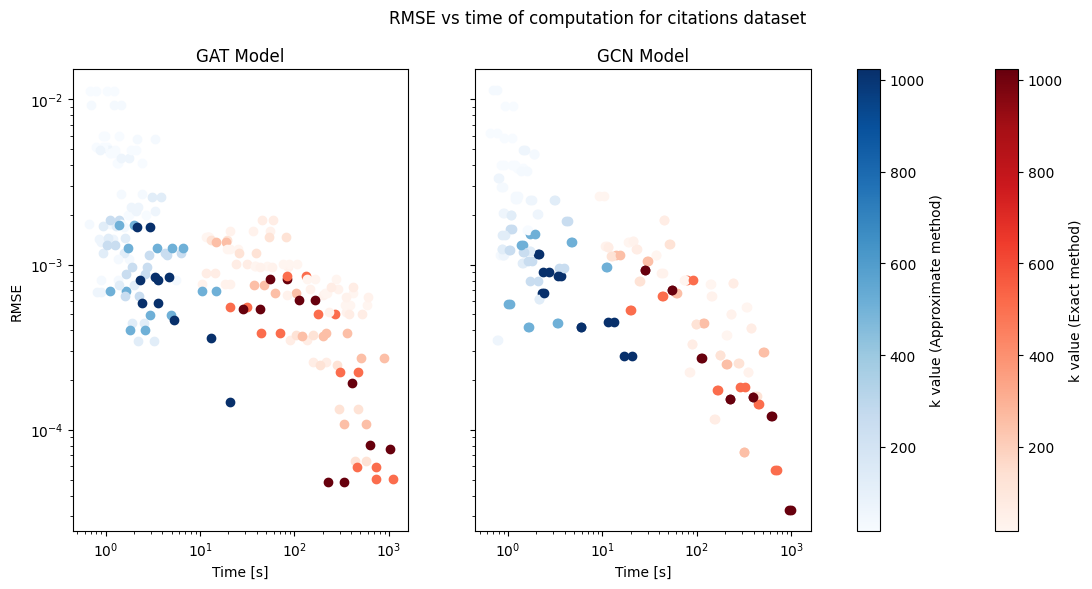

In [168]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import math

# Function to load data and compute necessary variables
def process_data(dataset, model, measure):
    df = pd.read_csv(paths[f"{dataset} dataset, ALE method, {model} model"],  
                     names=['i', 'k', 'max_bin_size',  'explanation_approximate', 'time_approximate', 
                            'explanation_exact', 'time_exact'], 
                     header=None, index_col=0)
    df['trial'] = [math.floor(x) for x in df.reset_index().index / 5]
    
    # Calculate mod and goldstandard
    mod = df.apply(lambda x: x['k'] * x['max_bin_size'], axis=1).sum() / 5
    goldstandard = df.apply(lambda x: x['explanation_exact'] * x['max_bin_size'] * x['k'] / mod, axis=1).reset_index().groupby('i').sum().values.T[0]
    
    # Aggregate the data
    aggregated = df.groupby(['trial']).agg({
        'k': lambda x: list(x)[0],
        'max_bin_size': lambda x: list(x)[0],
        'explanation_exact': list, 
        'time_exact': lambda x: list(x)[0],
        'explanation_approximate': list, 
        'time_approximate': lambda x: list(x)[0],
    })
    
    # Calculate distances
    aggregated['distance_exact'] = aggregated.apply(lambda row: measure(goldstandard, row['explanation_exact']), axis=1)
    aggregated['distance_approximate'] = aggregated.apply(lambda row: measure(goldstandard, row['explanation_approximate']), axis=1)
    
    return aggregated

# Set common parameters
dataset = "citations"
measure = root_mean_squared_error

# Load and process data for both models
aggregated_gat = process_data(dataset, "GAT", measure)
aggregated_gcn = process_data(dataset, "GCN", measure)

# Normalize the 'k' values for color mapping (common for both plots)
norm = Normalize(vmin=16, vmax=1024)

# Create colormaps for exact (red) and approximate (blue) dots
red_cmap = plt.cm.Reds
blue_cmap = plt.cm.Blues

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Plot for GAT
for _, row in aggregated_gat.iterrows():
    color = red_cmap(norm(row['k']))
    axs[0].scatter(x=row['time_exact'], y=row['distance_exact'], color=color)
for _, row in aggregated_gat.iterrows():
    color = blue_cmap(norm(row['k']))
    axs[0].scatter(x=row['time_approximate'], y=row['distance_approximate'], color=color)

axs[0].set_title("GAT Model")
axs[0].set_xlabel('Time [s]')
axs[0].set_ylabel('RMSE')

# Plot for GCN
for _, row in aggregated_gcn.iterrows():
    color = red_cmap(norm(row['k']))
    axs[1].scatter(x=row['time_exact'], y=row['distance_exact'], color=color)
for _, row in aggregated_gcn.iterrows():
    color = blue_cmap(norm(row['k']))
    axs[1].scatter(x=row['time_approximate'], y=row['distance_approximate'], color=color)

axs[1].set_title("GCN Model")
axs[1].set_xlabel('Time [s]')

# Set logarithmic scale for both axes
for ax in axs:
    ax.set_xscale('log')
    ax.set_yscale('log')

# Add a common colorbar
sm_red = ScalarMappable(cmap=red_cmap, norm=norm)
sm_red.set_array([])
cbar_red = fig.colorbar(sm_red, ax=axs, orientation='vertical', pad=0.00)
cbar_red.set_label('k value (Exact method)')

sm_blue = ScalarMappable(cmap=blue_cmap, norm=norm)
sm_blue.set_array([])
cbar_blue = fig.colorbar(sm_blue, ax=axs, orientation='vertical', pad=0.05)
cbar_blue.set_label('k value (Approximate method)')

# Show the plot
plt.suptitle(f"RMSE vs time of computation for {dataset} dataset")
plt.savefig(f"C:/Users/ppaul/Documents/influence_on_ideas/figures/citations/RMSE_vs_time.eps", format='eps')
plt.show()


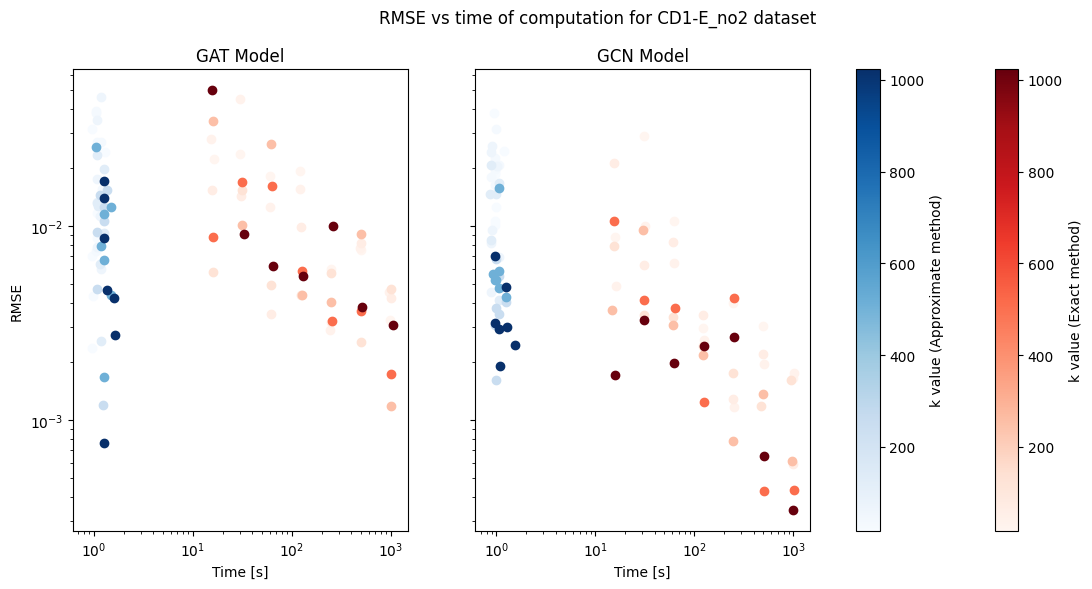

In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import math

# Function to load data and compute necessary variables
def process_data(dataset, model, measure):
    df = pd.read_csv(paths[f"{dataset} dataset, ALE method, {model} model"],  
                     #names=['i', 'k', 'max_bin_size', 'explanation_approximate', 'time_approximate', 'explanation_exact', 'time_exact'], 
                     #header=None, 
                     index_col=0)
    
    df = df.reset_index().rename({"index": 'i'}, axis=1).set_index('i')

    df['trial'] = [math.floor(x) for x in df.reset_index().index / 5]
    
    # Calculate mod and goldstandard
    mod = df.apply(lambda x: x['k'] * x['max_bin_size'], axis=1).sum() / 5
    goldstandard = df.apply(lambda x: x['explanation_exact'] * x['max_bin_size'] * x['k'] / mod, axis=1).reset_index().groupby('i').sum().values.T[0]
    
    # Aggregate the data
    aggregated = df.groupby(['trial']).agg({
        'k': lambda x: list(x)[0],
        'max_bin_size': lambda x: list(x)[0],
        'explanation_exact': list, 
        't_exact': lambda x: list(x)[0],
        'explanation_approximate': list, 
        't_approximate': lambda x: list(x)[0],
    })
    
    # Calculate distances
    aggregated['distance_exact'] = aggregated.apply(lambda row: measure(goldstandard, row['explanation_exact']), axis=1)
    aggregated['distance_approximate'] = aggregated.apply(lambda row: measure(goldstandard, row['explanation_approximate']), axis=1)
    
    return aggregated

# Set common parameters
dataset = "CD1-E_no2"
measure = root_mean_squared_error

# Load and process data for both models
aggregated_gat = process_data(dataset, "GAT", measure)
aggregated_gcn = process_data(dataset, "GCN", measure)

# Normalize the 'k' values for color mapping (common for both plots)
norm = Normalize(vmin=16, vmax=1024)

# Create colormaps for exact (red) and approximate (blue) dots
red_cmap = plt.cm.Reds
blue_cmap = plt.cm.Blues

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Plot for GAT
for _, row in aggregated_gat.iterrows():
    color = red_cmap(norm(row['k']))
    axs[0].scatter(x=row['t_exact'], y=row['distance_exact'], color=color)
for _, row in aggregated_gat.iterrows():
    color = blue_cmap(norm(row['k']))
    axs[0].scatter(x=row['t_approximate'], y=row['distance_approximate'], color=color)

axs[0].set_title("GAT Model")
axs[0].set_xlabel('Time [s]')
axs[0].set_ylabel('RMSE')

# Plot for GCN
for _, row in aggregated_gcn.iterrows():
    color = red_cmap(norm(row['k']))
    axs[1].scatter(x=row['t_exact'], y=row['distance_exact'], color=color)
for _, row in aggregated_gcn.iterrows():
    color = blue_cmap(norm(row['k']))
    axs[1].scatter(x=row['t_approximate'], y=row['distance_approximate'], color=color)

axs[1].set_title("GCN Model")
axs[1].set_xlabel('Time [s]')

# Set logarithmic scale for both axes
for ax in axs:
    ax.set_xscale('log')
    ax.set_yscale('log')

# Add a common colorbar
sm_red = ScalarMappable(cmap=red_cmap, norm=norm)
sm_red.set_array([])
cbar_red = fig.colorbar(sm_red, ax=axs, orientation='vertical', pad=0.00)
cbar_red.set_label('k value (Exact method)')

sm_blue = ScalarMappable(cmap=blue_cmap, norm=norm)
sm_blue.set_array([])
cbar_blue = fig.colorbar(sm_blue, ax=axs, orientation='vertical', pad=0.05)
cbar_blue.set_label('k value (Approximate method)')

# Show the plot
plt.suptitle(f"RMSE vs time of computation for {dataset} dataset")
plt.savefig(f"C:/Users/ppaul/Documents/influence_on_ideas/figures/CD1-E_no2/RMSE_vs_time.eps", format='eps')
plt.show()


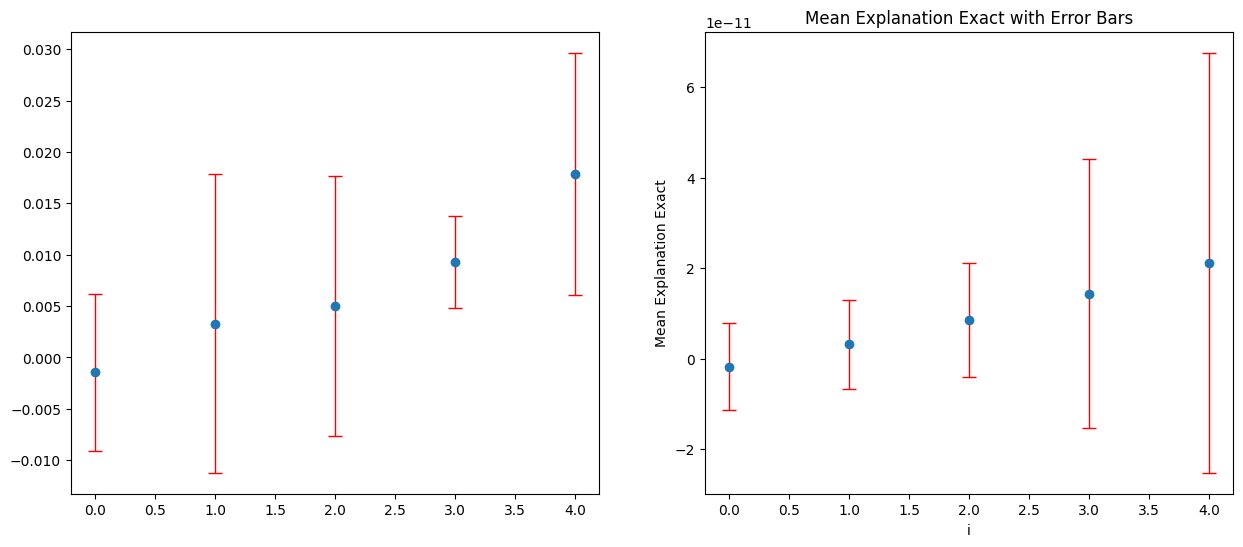

In [58]:
# gold standard with error bars?
grouped = ALE[(ALE.k==1024)&(ALE.max_bin_size==1024)].groupby('i')['explanation_exact'].agg(['mean', 'std']).reset_index()
grouped2 = ALE[(ALE.k==1024)&(ALE.max_bin_size==1024)].groupby('i')['explanation_approximate'].agg(['mean', 'std']).reset_index()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.errorbar(grouped['i'], grouped['mean'], yerr=grouped['std'], fmt='o', ecolor='r', capsize=5, capthick=1, elinewidth=1)
ax2.errorbar(grouped2['i'], grouped2['mean'], yerr=grouped2['std'], fmt='o', ecolor='r', capsize=5, capthick=1, elinewidth=1)
plt.xlabel('i')
plt.ylabel('Mean Explanation Exact')
plt.title('Mean Explanation Exact with Error Bars')
plt.show()

In [64]:


def plot_heatmaps(path, dataset, model):
    ALE = pd.read_csv(path, names=['i', 'trial', 'k', 'max_bin_size', 'explanation_exact', 'time_exact', 'explanation_approximate', 'time_approximate'], header=None, index_col=None)
    
    aggregated = ALE.groupby(['k','max_bin_size', 'trial']).agg({'explanation_exact':list, 'time_exact':lambda x: list(x)[0],'explanation_approximate':list, 'time_approximate':lambda x: list(x)[0]})
    
    aggregated['wasserstein_distance'] = aggregated.apply(lambda row: root_mean_squared_error(row['explanation_exact'], row['explanation_approximate']),axis=1)
    aggregated['time_diff'] = aggregated['time_exact']-aggregated['time_approximate']
    results = aggregated.groupby(['k','max_bin_size']).agg({'wasserstein_distance':'mean', 'time_diff':'mean'})

    # Assuming 'results' is already defined and contains the necessary data
    # First heatmap for Wasserstein distance
    wasserstein_data = results['wasserstein_distance'].reset_index().pivot_table(values='wasserstein_distance', index='k', columns='max_bin_size')

    # Second heatmap for Time difference
    #time_data = results['time_diff'].reset_index().pivot_table(values='time_diff', index='k', columns='max_bin_size')

    # Create a figure with two subplots side by side
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # First heatmap
    sns.heatmap(wasserstein_data, annot=False, cmap='YlGnBu', ax=axes[0])
    axes[0].set_title('Wasserstein Distance')
    axes[0].invert_yaxis()
    # Second heatmap
    #sns.heatmap(time_data, annot=False, cmap='YlGnBu', ax=axes[1])
    for k, group in results['time_diff'].groupby('k'):
        group.plot(kind='line', x='max_bin_size', y='time_diff', ax=axes[1])
    axes[1].set_title('Time Difference')
    axes[1].set_yscale('log')
    fig.suptitle(f'{dataset} dataset, {model} model')
    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the plot
    plt.show()

In [6]:
dataset="citations"
model="GCN"
plot_heatmaps(paths[f"{dataset} dataset, ALE, {model} model"], dataset, model)

NameError: name 'plot_heatmaps' is not defined

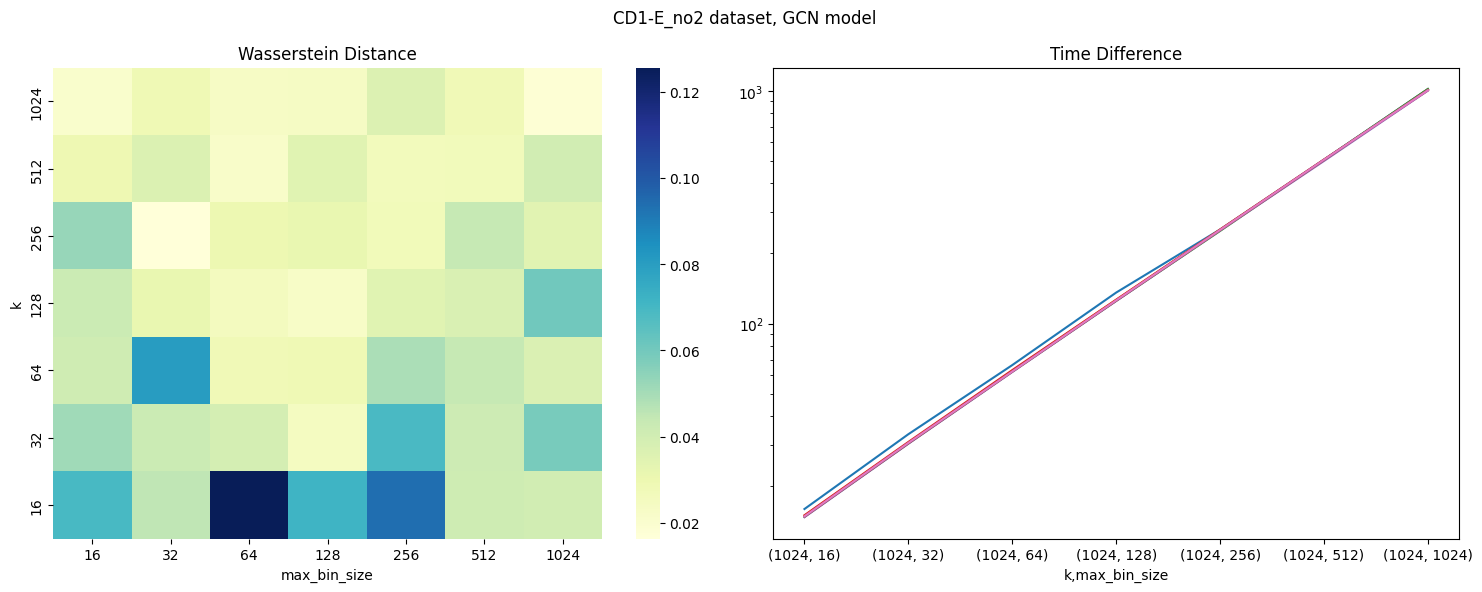

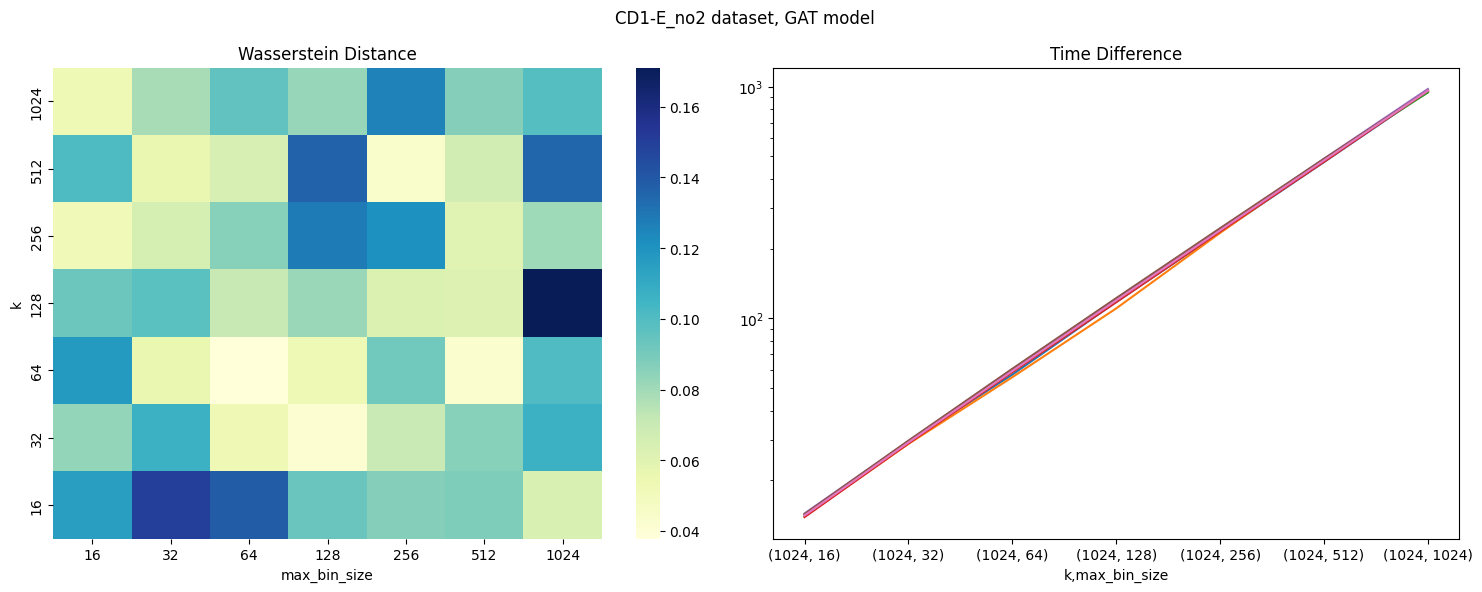

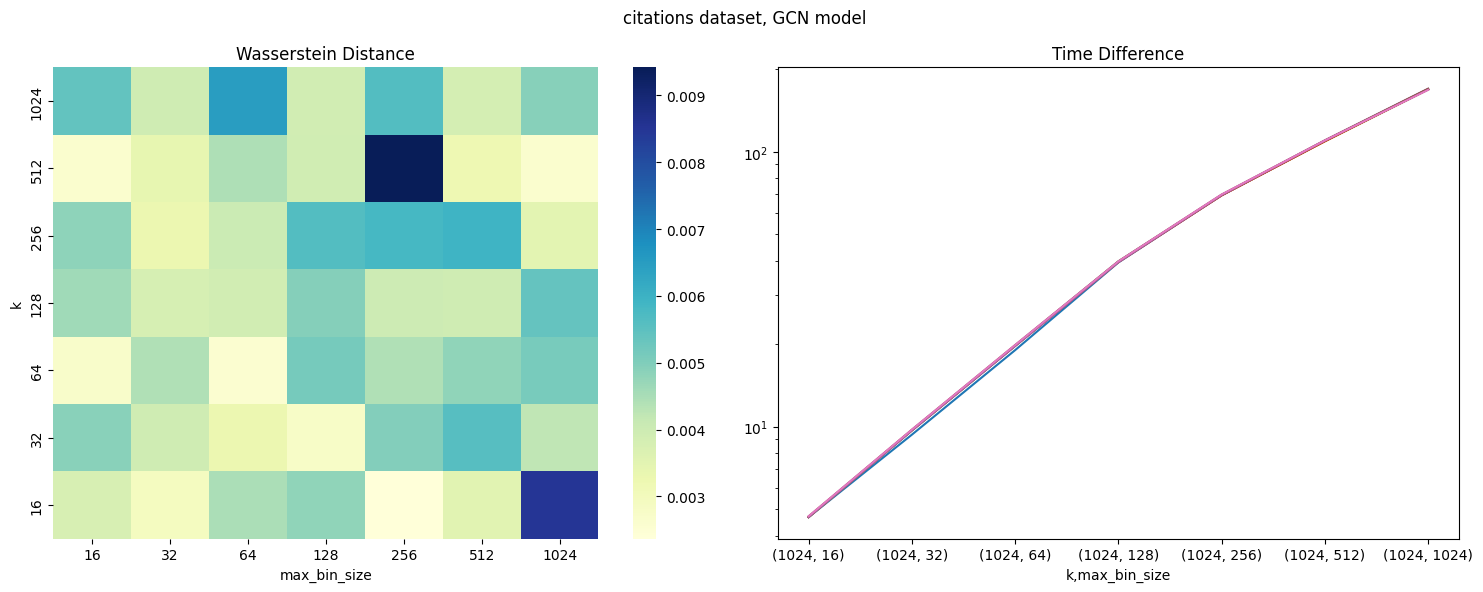

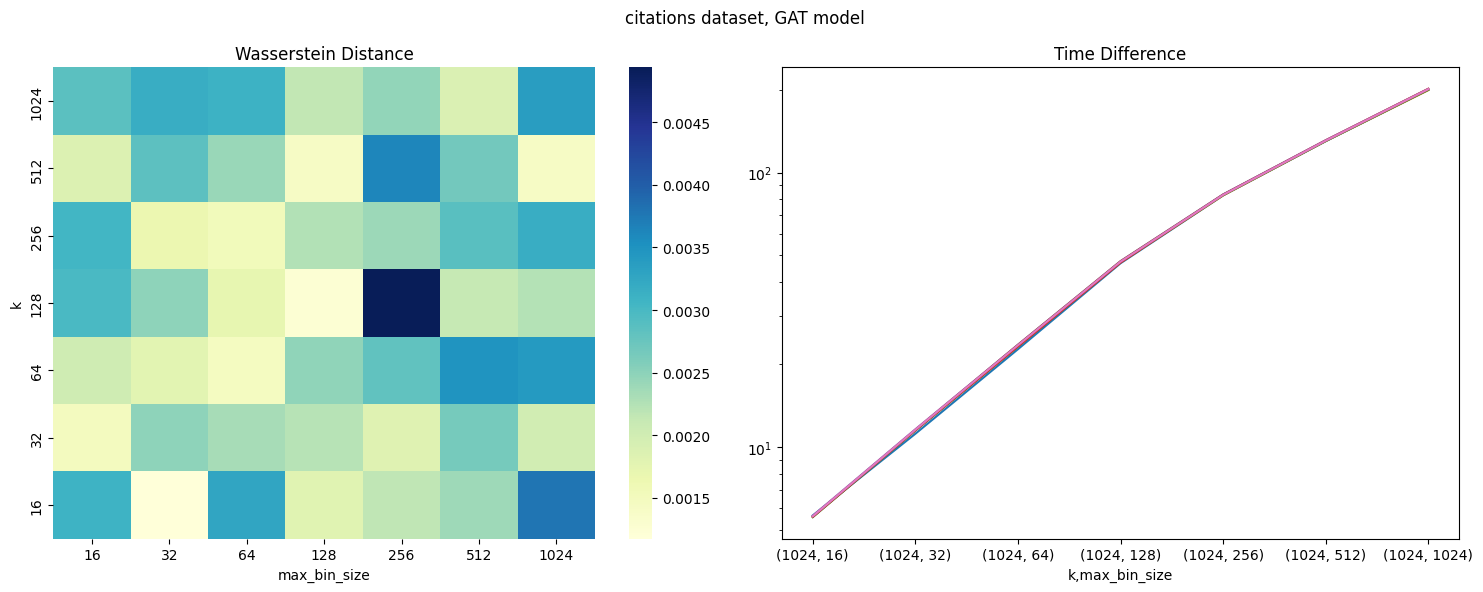

In [19]:

paths={}
for dataset in ["CD1-E_no2", "citations"]:
    for model in ["GCN", "GAT"]:
        if dataset == "citations":
            paths[f"{dataset} dataset, ALE, {model} model"] = f"C:/Users/ppaul/Documents/influence_on_ideas/data/{dataset}/ALE_{model}_n_layers4_hidden_size256.csv"
        else:
            paths[f"{dataset} dataset, ALE, {model} model"] = f"C:/Users/ppaul/Documents/influence_on_ideas/data/{dataset}/ALE_{model}_n_layers2_hidden_size256.csv"
        plot_heatmaps(paths[f"{dataset} dataset, ALE, {model} model"], dataset, model)



In [46]:
ALE.reset_index().groupby(['k', 'max_bin_size', 'index']).std()

trial  explanation_exact  time_exact  \
k      max_bin_size index                                            
16.0   16.0         0.0    1.581139           0.053541    0.525011   
                    1.0    1.581139           0.023577    0.525011   
                    2.0    1.581139           0.069449    0.525011   
                    3.0    1.581139           0.071880    0.525011   
                    4.0    1.581139           0.113702    0.525011   
...                             ...                ...         ...   
1024.0 1024.0       0.0    1.290994           0.007648    4.868716   
                    1.0    1.290994           0.014519    4.868716   
                    2.0    1.290994           0.012677    4.868716   
                    3.0    1.290994           0.004504    4.868716   
                    4.0    1.290994           0.011779    4.868716   

                           explanation_approximate  time_approximate  
k      max_bin_size index                                             
16.0   16.0         0.0               4.708978e-10          0.421091  
                    1.0               1.319051e-09          0.421091  
                    2.0               1.459523e-09          0.421091  
                    3.0               2.051782e-09          0.421091  
                    4.0               2.735326e-09          0.421091  
...                                            ...               ...  
1024.0 1024.0       0.0               9.594062e-12          0.010871  
                    1.0               9.829410e-12          0.010871  
                    2.0               1.255537e-11          0.010871  
                    3.0               2.976016e-11          0.010871  
                    4.0               4.639276e-11          0.010871  

[245 rows x 5 columns]

In [34]:
paths = {'CD1-E_no2 dataset, ALE, GCN model': 'C:/Users/ppaul/Documents/influence_on_ideas/data/CD1-E_no2/ALE_GCN_n_layers2_hidden_size256.csv',
 'CD1-E_no2 dataset, ALE, GAT model': 'C:/Users/ppaul/Documents/influence_on_ideas/data/CD1-E_no2/ALE_GAT_n_layers2_hidden_size256.csv',
 'citations dataset, ALE, GCN model': 'C:/Users/ppaul/Documents/influence_on_ideas/data/citations/ALE_04.08_GCN_n_layers2_hidden_size256.csv',
 'citations dataset, ALE, GAT model': 'C:/Users/ppaul/Documents/influence_on_ideas/data/citations/ALE_04.08_GAT_n_layers2_hidden_size256.csv'}

In [56]:
ALE

,i,k,max_bin_size,explanation_exact,time_exact,explanation_approximate,time_approximate
0,0.00,16,16,0.000573,0.650732,0.002581,9.113714
1,0.25,16,16,0.008293,0.650732,0.002750,9.113714
2,0.50,16,16,0.010687,0.650732,0.002782,9.113714
3,0.75,16,16,0.010687,0.650732,0.002782,9.113714
4,1.00,16,16,0.015713,0.650732,0.001162,9.113714
...,...,...,...,...,...,...,...
485,0.00,1024,1024,0.001680,20.502762,0.001449,946.269917
486,0.25,1024,1024,0.003221,20.502762,0.002722,946.269917
487,0.50,1024,1024,0.004817,20.502762,0.004535,946.269917
488,0.75,1024,1024,0.004817,20.502762,0.004535,946.269917


<Axes: title={'center': 'explanation_approximate'}, xlabel='[i]'>

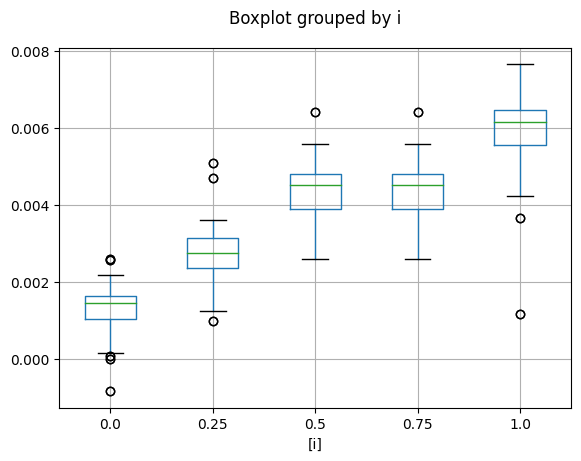

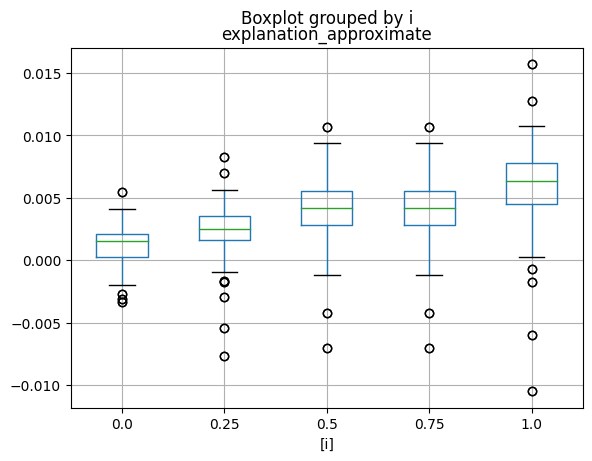

In [57]:
ALE = pd.read_csv(paths['citations dataset, ALE, GCN model'], names=['i', 'k', 'max_bin_size', 'explanation_approximate', 'time_approximate', 'explanation_exact', 'time_exact',], header=None, index_col=None)
ALE['i'] = ALE['i'].apply(lambda x: x/4)
ALE.boxplot(column=['explanation_exact'], by=['i'])
plt.title('')
ALE.boxplot(column=['explanation_approximate'], by=['i'])



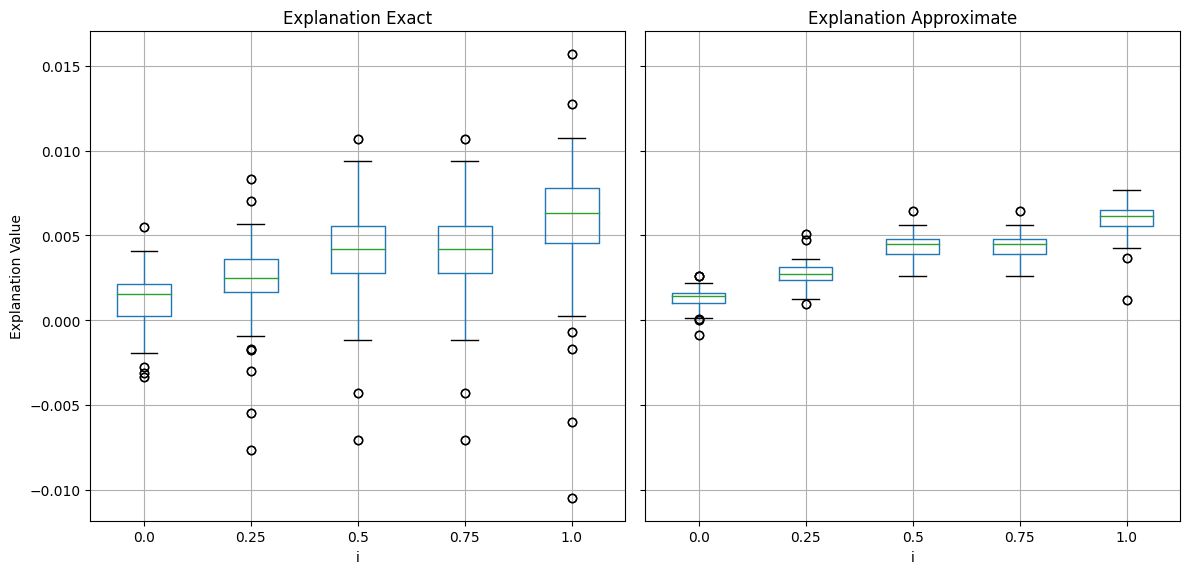

In [47]:
def plot_boxplots(df, group_by_column):
    # Create a figure with two subplots side by side
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), sharey=True)
    
    # Boxplot for 'explanation_exact'
    df.boxplot(column=['explanation_exact'], by=group_by_column, ax=axes[0])
    axes[0].set_title('Explanation Exact')
    axes[0].set_xlabel(group_by_column)
    axes[0].set_ylabel('Explanation Value')
    
    # Boxplot for 'explanation_approximate'
    df.boxplot(column=['explanation_approximate'], by=group_by_column, ax=axes[1])
    axes[1].set_title('Explanation Approximate')
    axes[1].set_xlabel(group_by_column)
    
    # Adjust the layout and remove the automatic title that pandas adds
    plt.suptitle('')
    plt.tight_layout()
    
    # Show the plot
    plt.show()


# Call the function
plot_boxplots(ALE, 'i')

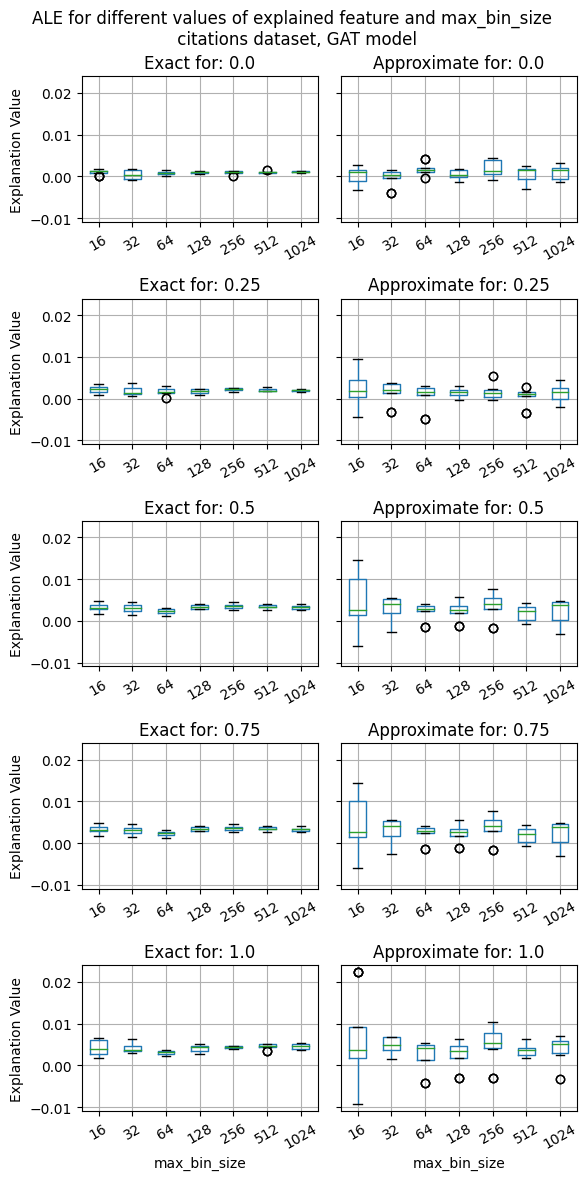

In [194]:
def plot_boxplots_k(df, col):
    # Create a figure with two subplots side by side
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(6, 12), sharey=True)
    
    for i in range(5):
        # Boxplot for 'explanation_exact'
        df[df['i']==i/4].boxplot(column=['explanation_exact'], by=col, ax=axes[i,0])
        axes[i,0].set_title('Exact for: '+str(i/4))
        if i==4:
            axes[i,0].set_xlabel(col)
        else:     
            axes[i,0].set(xlabel=None)        
        axes[i,0].tick_params(axis='x', rotation=30)
        axes[i, 0].set_ylabel('Explanation Value')

        
        # Boxplot for 'explanation_approximate'
        df[df['i']==i/4].boxplot(column=['explanation_approximate'], by=col, ax=axes[i,1])
        axes[i,1].set_title('Approximate for: '+str(i/4))
        if i==4:
            axes[i,1].set_xlabel(col) 
        else:     
            axes[i,1].set(xlabel=None)
        axes[i,1].tick_params(axis='x', rotation=30)
    
    # Adjust the layout and remove the automatic title that pandas adds
    #plt.suptitle('')
    plt.suptitle(f"ALE for different values of explained feature and {col} \n {dataset} dataset, {model} model")
    plt.tight_layout()
    plt.savefig(f"C:/Users/ppaul/Documents/influence_on_ideas/figures/{dataset}/boxplot_{col}_{dataset}_{model}.eps", format='eps')
    # Show the plot
    plt.show()


# Call the function
dataset="citations"#"CD1-E_no2"#
model = "GAT"
ALE = pd.read_csv(paths[f"{dataset} dataset, ALE method, {model} model"], names=['i', 'k', 'max_bin_size', 'explanation_approximate', 'time_approximate', 'explanation_exact', 'time_exact',], header=None, index_col=None)
ALE['i'] = ALE['i'].apply(lambda x: x/4)
plot_boxplots_k(ALE, 'max_bin_size')

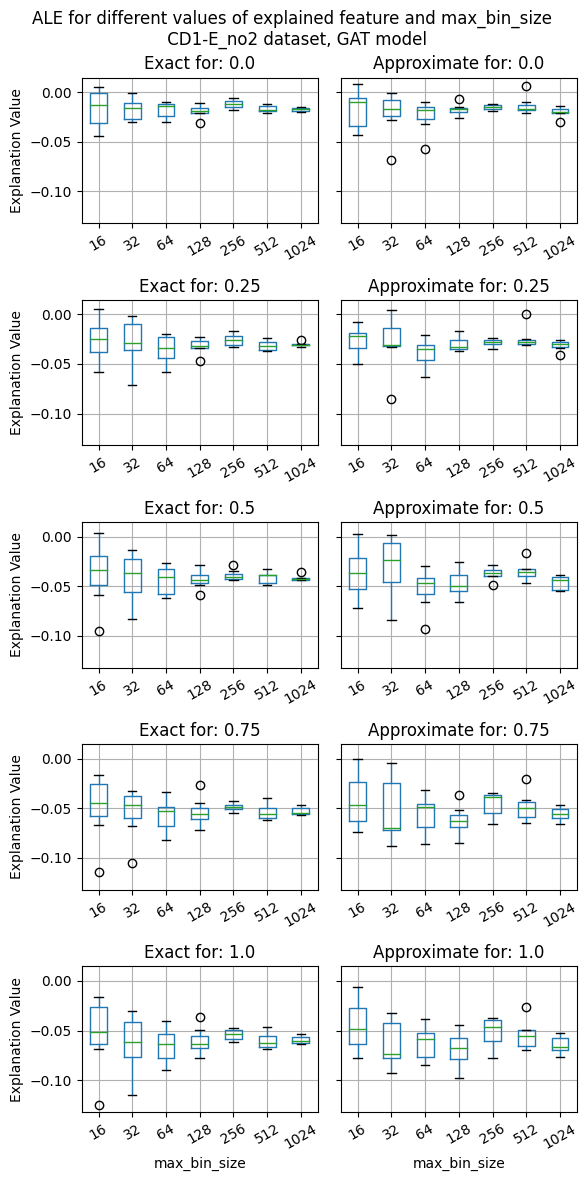

In [195]:
def plot_boxplots_k(df, col):
    # Create a figure with two subplots side by side
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(6, 12), sharey=True)
    
    for i in range(5):
        # Boxplot for 'explanation_exact'
        df[df['i']==i/4].boxplot(column=['explanation_exact'], by=col, ax=axes[i,0])
        axes[i,0].set_title('Exact for: '+str(i/4))
        if i==4:
            axes[i,0].set_xlabel(col)
        else:     
            axes[i,0].set(xlabel=None)        
        axes[i,0].tick_params(axis='x', rotation=30)
        axes[i, 0].set_ylabel('Explanation Value')

        
        # Boxplot for 'explanation_approximate'
        df[df['i']==i/4].boxplot(column=['explanation_approximate'], by=col, ax=axes[i,1])
        axes[i,1].set_title('Approximate for: '+str(i/4))
        if i==4:
            axes[i,1].set_xlabel(col) 
        else:     
            axes[i,1].set(xlabel=None)
        axes[i,1].tick_params(axis='x', rotation=30)
    
    # Adjust the layout and remove the automatic title that pandas adds
    #plt.suptitle('')
    plt.suptitle(f"ALE for different values of explained feature and {col} \n {dataset} dataset, {model} model")
    plt.tight_layout()
    plt.savefig(f"C:/Users/ppaul/Documents/influence_on_ideas/figures/{dataset}/boxplot_{col}_{dataset}_{model}.eps", format='eps')
    # Show the plot
    plt.show()


# Call the function
dataset="CD1-E_no2"#"citations"
model = "GAT"
ALE = pd.read_csv(paths[f"{dataset} dataset, ALE method, {model} model"], index_col=None).rename({"index":"i"},axis=1)
ALE['i'] = ALE['i'].apply(lambda x: x/4)
plot_boxplots_k(ALE, 'max_bin_size')

<Axes: title={'center': 'explanation_approximate'}, xlabel='[k]'>

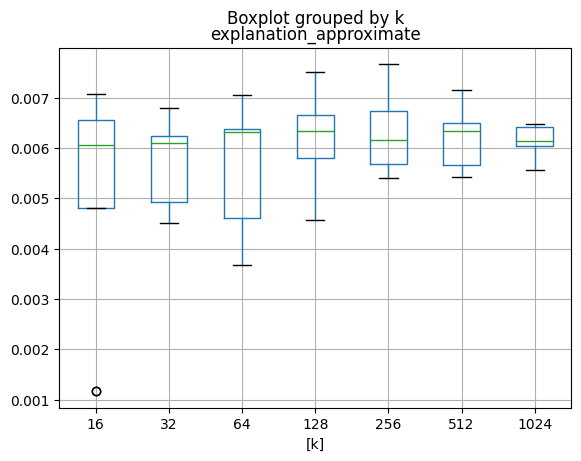

In [45]:
ALE[ALE['i']==1].boxplot(column=['explanation_approximate'], by=['k'])

<Axes: title={'center': 'explanation_approximate'}, xlabel='[max_bin_size]'>

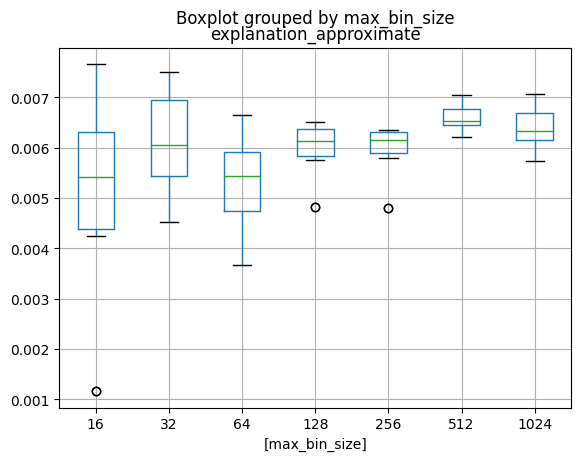

In [46]:
ALE[ALE['i']==1].boxplot(column=['explanation_approximate'], by=['max_bin_size'])

<Axes: title={'center': 'explanation_exact'}, xlabel='[k]'>

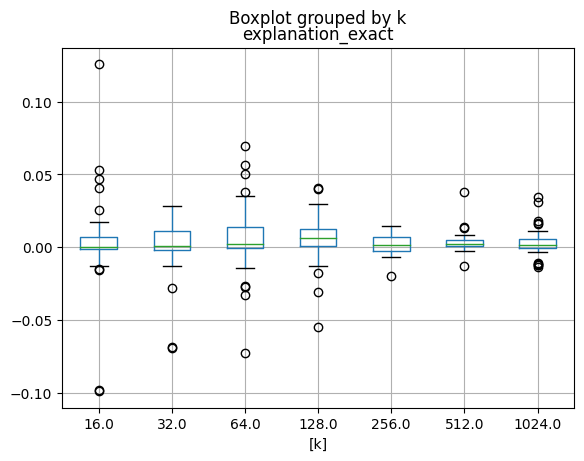

In [25]:
ALE[ALE['i']==0].boxplot(column=['explanation_exact'], by=['k'])

<Axes: title={'center': 'explanation_exact'}, xlabel='[max_bin_size]'>

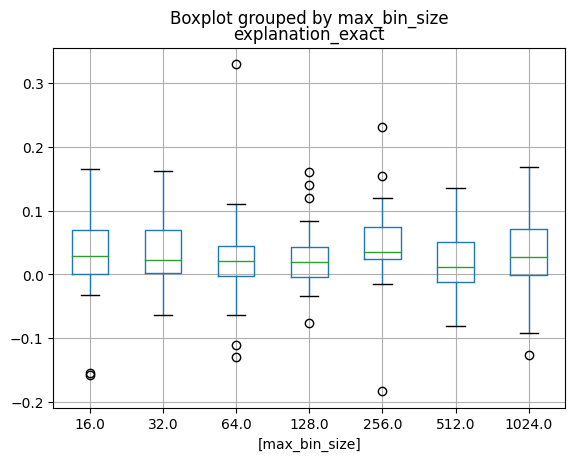

In [27]:
ALE[ALE['i']==4].boxplot(column=['explanation_exact'], by=['max_bin_size'])

In [ ]:
ALE.boxplot(column=['explanation_approximate'], by=['i'])

In [ ]:
#TODO: divergnce. boxblots for each explanation, model, dataset. 
def plot_boxplots(path, dataset, model):
    ALE = pd.read_csv(path, names=['trial', 'k', 'max_bin_size', 'explanation_exact', 'time_exact', 'explanation_approximate', 'time_approximate'], header=None, index_col=0)
    aggregated = ALE.groupby(['k','max_bin_size', 'trial']).agg({'explanation_exact':list, 'time_exact':lambda x: list(x)[0],'explanation_approximate':list, 'time_approximate':lambda x: list(x)[0]})
    aggregated['wasserstein_distance'] = aggregated.apply(lambda row: wasserstein_distance(row['explanation_exact'], row['explanation_approximate']),axis=1)
    aggregated['time_diff'] = aggregated['time_exact']-aggregated['time_approximate']
    results = aggregated.groupby(['k','max_bin_size']).agg({'wasserstein_distance':'mean', 'time_diff':'mean'})

    # Assuming 'results' is already defined and contains the necessary data
    # First heatmap for Wasserstein distance
    wasserstein_data = results['wasserstein_distance'].reset_index().pivot_table(values='wasserstein_distance', index='k', columns='max_bin_size')

    # Second heatmap for Time difference
    #time_data = results['time_diff'].reset_index().pivot_table(values='time_diff', index='k', columns='max_bin_size')

    # Create a figure with two subplots side by side
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # First heatmap
    sns.heatmap(wasserstein_data, annot=False, cmap='YlGnBu', ax=axes[0])
    axes[0].set_title('Wasserstein Distance')
    axes[0].invert_yaxis()
    # Second heatmap
    #sns.heatmap(time_data, annot=False, cmap='YlGnBu', ax=axes[1])
    results['time_diff'].groupby('k').plot(kind='line', x='max_bin_size', y='time_diff', ax=axes[1])
    axes[1].set_title('Time Difference')
    fig.suptitle(f'{dataset} dataset, {model} model')
    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the plot
    plt.show()
paths={}
for key, path in paths.items():
    plot_boxplots(paths[f"{dataset} dataset, ALE, {model} model"], dataset, model)



In [270]:
df

,index,trial,k,max_bin_size,explanation_exact,time_exact,explanation_approximate,time_approximate
0,0,16,16,0.000573,0.650732,0.002581,9.113714,NaN
1,1,16,16,0.008293,0.650732,0.002750,9.113714,NaN
2,2,16,16,0.010687,0.650732,0.002782,9.113714,NaN
3,3,16,16,0.010687,0.650732,0.002782,9.113714,NaN
4,4,16,16,0.015713,0.650732,0.001162,9.113714,NaN
...,...,...,...,...,...,...,...,...
485,0,1024,1024,0.001680,20.502762,0.001449,946.269917,NaN
486,1,1024,1024,0.003221,20.502762,0.002722,946.269917,NaN
487,2,1024,1024,0.004817,20.502762,0.004535,946.269917,NaN
488,3,1024,1024,0.004817,20.502762,0.004535,946.269917,NaN


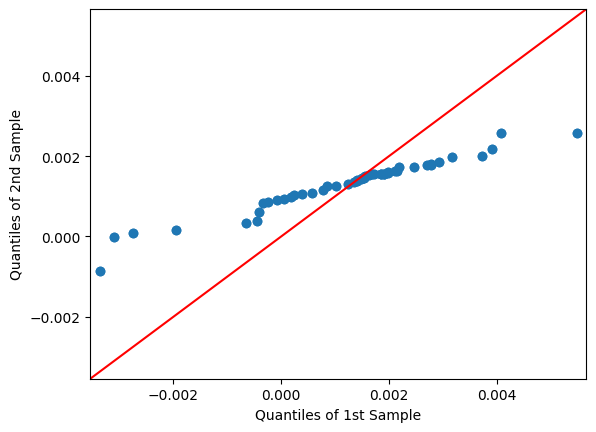

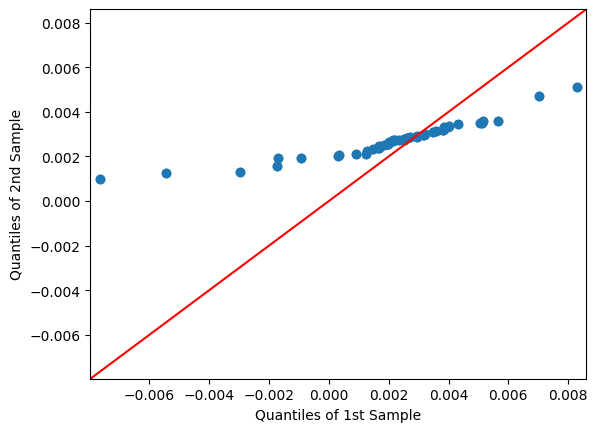

In [278]:
model = "GCN"
dataset = "citations"#"CD1-E_no2"#
df = pd.read_csv(
    paths[f"{dataset} dataset, ALE method, {model} model"],
    names=['index', 'k', 'max_bin_size', 'explanation_exact', 'time_exact', 'explanation_approximate', 'time_approximate'],
    header=None,
    index_col=None,
)

import numpy as np
import statsmodels as sm
import pylab

sm.graphics.gofplots.qqplot_2samples(df[df['index']==0]['explanation_exact'], df[df['index']==0]['explanation_approximate'], xlabel=None, ylabel=None, line="45", ax=None)
sm.graphics.gofplots.qqplot_2samples(df[df['index']==1]['explanation_exact'], df[df['index']==1]['explanation_approximate'], xlabel=None, ylabel=None, line="45", ax=None)
plt.show()


In [268]:
df[df['index']==0]['explanation_approximate']

0        9.113714
5       18.637107
10      36.499109
15      73.835008
20     139.783448
          ...    
465    111.431129
470    225.475490
475    390.384033
480    630.725065
485    946.269917
Name: explanation_approximate, Length: 98, dtype: float64